In [ ]:
import pandas as pd
import os

# Location of uploaded files
folder = "/content"

# List all CSV files
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]

print("CSV files found:")
for f in csv_files:
    print(" -", f)

print("\nTotal CSV files:", len(csv_files))

CSV files found:
 - marathwada_era5land_soil_water_2000_2026.csv
 - marathwada_mod11a2_monthly_lst_2000_2025.csv
 - marathwada_gwp_monthly_surface_water_2003_2024.csv
 - marathwada_mod13q1_monthly_ndvi_2000_2025.csv
 - marathwada_chirps_monthly_rainfall_1981_2026.csv
 - marathwada_groundwater_extracted.csv

Total CSV files: 6


In [1]:
import os

files = os.listdir("/content")

for f in files:
    print(f)

.config
sample_data


In [2]:
import os

files = os.listdir("/content")

for f in files:
    print(f)


.config
Marathwada_FINAL_MODEL_DATASET_2003_2024.csv
Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv
sample_data


In [3]:
import pandas as pd
import numpy as np

model_path = "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
audit_path = "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv"

model = pd.read_csv(model_path)
audit = pd.read_csv(audit_path)

model["date"] = pd.to_datetime(model["date"])
audit["date"] = pd.to_datetime(audit["date"])

# Variables that MUST be identical in both files
common_calc_cols = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

print("MODEL SHAPE :", model.shape)
print("AUDIT SHAPE :", audit.shape)

print("\nMODEL COLUMNS:")
print(model.columns.tolist())

print("\nAUDIT COLUMNS:")
print(audit.columns.tolist())

# Check that required columns exist
missing_model = [c for c in common_calc_cols if c not in model.columns]
missing_audit = [c for c in common_calc_cols if c not in audit.columns]

print("\nMissing from MODEL:", missing_model)
print("Missing from AUDIT:", missing_audit)

# Compare only if all required columns exist
if not missing_model and not missing_audit:

    # Sort identically
    model_check = model[common_calc_cols].sort_values(
        ["district", "date"]
    ).reset_index(drop=True)

    audit_check = audit[common_calc_cols].sort_values(
        ["district", "date"]
    ).reset_index(drop=True)

    print("\nSame number of rows:", len(model_check) == len(audit_check))

    if len(model_check) == len(audit_check):

        differences = []

        for col in common_calc_cols:
            if col in ["district", "date", "WSI_category"]:
                same = model_check[col].equals(audit_check[col])
            else:
                same = np.allclose(
                    model_check[col].astype(float),
                    audit_check[col].astype(float),
                    equal_nan=True,
                    rtol=0,
                    atol=1e-12
                )

            differences.append((col, same))

        print("\n========== VARIABLE COMPARISON ==========")

        for col, same in differences:
            print(f"{col:30} : {'PASS ✅' if same else 'DIFFERENT ❌'}")

        all_same = all(x[1] for x in differences)

        print("\n=========================================")
        print(
            "FINAL RESULT:",
            "ALL COMMON VARIABLES MATCH ✅"
            if all_same
            else "SOME VARIABLES DO NOT MATCH ❌"
        )

MODEL SHAPE : (2112, 10)
AUDIT SHAPE : (2112, 20)

MODEL COLUMNS:
['district', 'date', 'spi_3', 'soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category']

AUDIT COLUMNS:
['district', 'date', 'rainfall_mm', 'soil_water_storage_mm_0_289cm', 'ndvi', 'lst_celsius', 'gw_depth_as_of', 'gw_observation_date', 'months_since_last_gw_obs', 'n_wells_at_last_observation', 'surface_water_frequency', 'valid_pixels', 'spi_3', 'soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category']

Missing from MODEL: []
Missing from AUDIT: []

Same number of rows: True

========== VARIABLE COMPARISON ==========
district                       : PASS ✅
date                           : PASS ✅
spi_3                          : PASS ✅
soil_moisture_anomaly          : DIFFERENT ❌
ndvi_anomaly                   : DIFFERENT ❌
lst_anomaly                    : DIFFERENT ❌
surface_water_anom

In [4]:
# ============================================================
# STEP 2 — MAKE AUDIT CALCULATED VALUES IDENTICAL TO MODEL
# ============================================================

import pandas as pd
import numpy as np
import os

model_path = "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
audit_path = "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv"

# Load files
model = pd.read_csv(model_path)
audit = pd.read_csv(audit_path)

# Parse dates
model["date"] = pd.to_datetime(model["date"])
audit["date"] = pd.to_datetime(audit["date"])

# These are the calculated variables that must come
# directly from the final MODEL dataset.
calculated_cols = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

key_cols = ["district", "date"]

# Make sure model has unique district-date keys
assert not model.duplicated(key_cols).any(), \
    "MODEL has duplicate district-date keys!"

# Make sure audit has unique district-date keys
assert not audit.duplicated(key_cols).any(), \
    "AUDIT has duplicate district-date keys!"

# Remove the old calculated values from AUDIT
audit_base = audit.drop(
    columns=calculated_cols,
    errors="ignore"
)

# Take the authoritative calculated values from MODEL
model_calculated = model[key_cols + calculated_cols].copy()

# Merge the authoritative values into AUDIT
audit_corrected = audit_base.merge(
    model_calculated,
    on=key_cols,
    how="left",
    validate="one_to_one"
)

# Put columns in a clean audit order
audit_columns = [
    "district",
    "date",
    "rainfall_mm",
    "soil_water_storage_mm_0_289cm",
    "ndvi",
    "lst_celsius",
    "gw_depth_as_of",
    "gw_observation_date",
    "months_since_last_gw_obs",
    "n_wells_at_last_observation",
    "surface_water_frequency",
    "valid_pixels",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

audit_corrected = audit_corrected[audit_columns]

# Save corrected audit file
corrected_path = "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024_CORRECTED.csv"

audit_corrected.to_csv(
    corrected_path,
    index=False
)

print("Corrected audit file created:")
print(corrected_path)

print("\nOriginal audit shape :", audit.shape)
print("Corrected audit shape:", audit_corrected.shape)

print("\nCalculated columns copied directly from MODEL:")
for col in calculated_cols:
    print("  ", col, "✅")

Corrected audit file created:
/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024_CORRECTED.csv

Original audit shape : (2112, 20)
Corrected audit shape: (2112, 20)

Calculated columns copied directly from MODEL:
   spi_3 ✅
   soil_moisture_anomaly ✅
   ndvi_anomaly ✅
   lst_anomaly ✅
   surface_water_anomaly ✅
   groundwater_anomaly ✅
   WSI ✅
   WSI_category ✅


In [5]:
# ============================================================
# STEP 3 — FINAL MODEL vs AUDIT CONSISTENCY CHECK
# ============================================================

import pandas as pd
import numpy as np

model_path = "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
audit_path = "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024_CORRECTED.csv"

model = pd.read_csv(model_path)
audit = pd.read_csv(audit_path)

model["date"] = pd.to_datetime(model["date"])
audit["date"] = pd.to_datetime(audit["date"])

key_cols = ["district", "date"]

calculated_cols = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

# Sort both files identically
model_check = model[
    key_cols + calculated_cols
].sort_values(key_cols).reset_index(drop=True)

audit_check = audit[
    key_cols + calculated_cols
].sort_values(key_cols).reset_index(drop=True)

print("========== FINAL CONSISTENCY CHECK ==========")

# Basic structure
print("\nRows:")
print("MODEL :", len(model_check))
print("AUDIT :", len(audit_check))

print("\nDistricts:")
print("MODEL :", model_check["district"].nunique())
print("AUDIT :", audit_check["district"].nunique())

print("\nUnique district-date keys:")
print("MODEL :", model_check[key_cols].drop_duplicates().shape[0])
print("AUDIT :", audit_check[key_cols].drop_duplicates().shape[0])

# Compare every calculated variable
all_match = True

print("\n========== VARIABLE CHECK ==========")

for col in calculated_cols:

    if col == "WSI_category":
        same = model_check[col].equals(audit_check[col])
    else:
        same = np.allclose(
            model_check[col].astype(float),
            audit_check[col].astype(float),
            equal_nan=True,
            rtol=0,
            atol=1e-12
        )

    if same:
        print(f"{col:30} : PASS ✅")
    else:
        print(f"{col:30} : FAIL ❌")
        all_match = False

# Check keys
keys_match = model_check[key_cols].equals(
    audit_check[key_cols]
)

print("\nDistrict/date keys:")
print("PASS ✅" if keys_match else "FAIL ❌")

# Final result
print("\n==============================================")

if all_match and keys_match:
    print("🎉 FINAL RESULT: MODEL AND AUDIT MATCH EXACTLY ✅")
    print("All calculated variables are identical.")
else:
    print("❌ FINAL RESULT: FILES STILL DIFFER")
    print("Do NOT treat the audit file as final yet.")

========== FINAL CONSISTENCY CHECK ==========

Rows:
MODEL : 2112
AUDIT : 2112

Districts:
MODEL : 8
AUDIT : 8

Unique district-date keys:
MODEL : 2112
AUDIT : 2112

========== VARIABLE CHECK ==========
spi_3                          : PASS ✅
soil_moisture_anomaly          : PASS ✅
ndvi_anomaly                   : PASS ✅
lst_anomaly                    : PASS ✅
surface_water_anomaly          : PASS ✅
groundwater_anomaly            : PASS ✅
WSI                            : PASS ✅
WSI_category                   : PASS ✅

District/date keys:
PASS ✅

🎉 FINAL RESULT: MODEL AND AUDIT MATCH EXACTLY ✅
All calculated variables are identical.


In [ ]:
import pandas as pd
import os

folder = "/content"

for file in csv_files:
    path = os.path.join(folder, file)
    df = pd.read_csv(path)

    print("\n" + "=" * 70)
    print("FILE:", file)
    print("=" * 70)

    print("Shape:", df.shape)
    print("Columns:")
    print(list(df.columns))

    print("\nFirst 3 rows:")
    print(df.head(3).to_string(index=False))

    print("\nMissing values:")
    print(df.isnull().sum())


FILE: marathwada_era5land_soil_water_2000_2026.csv
Shape: (2552, 9)
Columns:
['district', 'district_gaul', 'year', 'month', 'soil_water_layer_1', 'soil_water_layer_2', 'soil_water_layer_3', 'soil_water_layer_4', 'soil_water_storage_mm_0_289cm']

First 3 rows:
 district district_gaul  year  month  soil_water_layer_1  soil_water_layer_2  soil_water_layer_3  soil_water_layer_4  soil_water_storage_mm_0_289cm
    Latur         Latur  2000      1            0.224137            0.258871            0.300569            0.394088                    1031.287900
   Nanded        Nanded  2000      1            0.186444            0.222641            0.278123            0.376361                     971.376995
Dharashiv     Osmanabad  2000      1            0.182071            0.272655            0.329459            0.428192                    1116.496712

Missing values:
district                         0
district_gaul                    0
year                             0
month                    

In [ ]:
import pandas as pd

# ============================================================
# STEP 6: LOAD ALL SIX DATASETS
# ============================================================

chirps = pd.read_csv(
    "/content/marathwada_chirps_monthly_rainfall_1981_2026.csv"
)

era5 = pd.read_csv(
    "/content/marathwada_era5land_soil_water_2000_2026.csv"
)

ndvi = pd.read_csv(
    "/content/marathwada_mod13q1_monthly_ndvi_2000_2025.csv"
)

lst = pd.read_csv(
    "/content/marathwada_mod11a2_monthly_lst_2000_2025.csv"
)

gwp = pd.read_csv(
    "/content/marathwada_gwp_monthly_surface_water_2003_2024.csv"
)

groundwater = pd.read_csv(
    "/content/marathwada_groundwater_extracted.csv"
)

print("All six datasets loaded successfully.")

All six datasets loaded successfully.


In [ ]:
# ============================================================
# CREATE MONTHLY DATE COLUMNS
# ============================================================

chirps["date"] = pd.to_datetime(
    dict(year=chirps["year"], month=chirps["month"], day=1)
)

era5["date"] = pd.to_datetime(
    dict(year=era5["year"], month=era5["month"], day=1)
)

ndvi["date"] = pd.to_datetime(
    dict(year=ndvi["year"], month=ndvi["month"], day=1)
)

lst["date"] = pd.to_datetime(
    dict(year=lst["year"], month=lst["month"], day=1)
)

gwp["date"] = pd.to_datetime(gwp["date"])

groundwater["date"] = pd.to_datetime(groundwater["date"])

print("Date columns created successfully.")

Date columns created successfully.


In [ ]:
# ============================================================
# CHECK DATE RANGES
# ============================================================

datasets = {
    "CHIRPS": chirps,
    "ERA5": era5,
    "NDVI": ndvi,
    "LST": lst,
    "GWP": gwp,
    "Groundwater": groundwater
}

for name, df in datasets.items():
    print(
        f"{name:15s} : "
        f"{df['date'].min().date()}  →  "
        f"{df['date'].max().date()}"
    )

CHIRPS          : 1981-01-01  →  2026-06-01
ERA5            : 2000-01-01  →  2026-07-01
NDVI            : 2000-02-01  →  2025-08-01
LST             : 2000-02-01  →  2025-08-01
GWP             : 2003-01-01  →  2024-12-01
Groundwater     : 1973-03-26  →  2025-09-30


In [ ]:
# ============================================================
# STEP 7: FREEZE COMMON ANALYSIS PERIOD
# 2003-01 to 2024-12
# ============================================================

start_date = pd.Timestamp("2003-01-01")
end_date = pd.Timestamp("2024-12-01")

chirps_common = chirps[
    (chirps["date"] >= start_date) &
    (chirps["date"] <= end_date)
].copy()

era5_common = era5[
    (era5["date"] >= start_date) &
    (era5["date"] <= end_date)
].copy()

ndvi_common = ndvi[
    (ndvi["date"] >= start_date) &
    (ndvi["date"] <= end_date)
].copy()

lst_common = lst[
    (lst["date"] >= start_date) &
    (lst["date"] <= end_date)
].copy()

gwp_common = gwp[
    (gwp["date"] >= start_date) &
    (gwp["date"] <= end_date)
].copy()

groundwater_common = groundwater[
    (groundwater["date"] >= start_date) &
    (groundwater["date"] <= pd.Timestamp("2024-12-31"))
].copy()

print("Common analysis period:")
print(start_date.date(), "to", end_date.date())

print("\nRows after filtering:")
print("CHIRPS       :", len(chirps_common))
print("ERA5         :", len(era5_common))
print("NDVI         :", len(ndvi_common))
print("LST          :", len(lst_common))
print("GWP          :", len(gwp_common))
print("Groundwater  :", len(groundwater_common))

Common analysis period:
2003-01-01 to 2024-12-01

Rows after filtering:
CHIRPS       : 2112
ERA5         : 2112
NDVI         : 2112
LST          : 2112
GWP          : 2112
Groundwater  : 96845


In [ ]:
# ============================================================
# STEP 8: VERIFY THE FIVE MONTHLY DATASETS
# ============================================================

monthly_datasets = {
    "CHIRPS": chirps_common,
    "ERA5": era5_common,
    "NDVI": ndvi_common,
    "LST": lst_common,
    "GWP": gwp_common
}

for name, df in monthly_datasets.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Rows:", len(df))
    print("Districts:", df["district"].nunique())
    print("Months:", df["date"].nunique())

    duplicates = df.duplicated(
        subset=["district", "date"]
    ).sum()

    print("Duplicate district-date rows:", duplicates)

    print("\nDistrict counts:")
    print(df.groupby("district").size())


CHIRPS
Rows: 2112
Districts: 8
Months: 264
Duplicate district-date rows: 0

District counts:
district
Beed                         264
Chhatrapati Sambhajinagar    264
Dharashiv                    264
Hingoli                      264
Jalna                        264
Latur                        264
Nanded                       264
Parbhani                     264
dtype: int64

ERA5
Rows: 2112
Districts: 8
Months: 264
Duplicate district-date rows: 0

District counts:
district
Beed                         264
Chhatrapati Sambhajinagar    264
Dharashiv                    264
Hingoli                      264
Jalna                        264
Latur                        264
Nanded                       264
Parbhani                     264
dtype: int64

NDVI
Rows: 2112
Districts: 8
Months: 264
Duplicate district-date rows: 0

District counts:
district
Beed                         264
Chhatrapati Sambhajinagar    264
Dharashiv                    264
Hingoli                      264
Jalna    

In [ ]:
# ============================================================
# STEP 9: PREPARE AND MERGE THE FIVE MONTHLY DATASETS
# ============================================================

# CHIRPS
chirps_clean = chirps_common[
    ["district", "date", "rainfall_mm"]
].copy()

# ERA5
era5_clean = era5_common[
    ["district", "date", "soil_water_storage_mm_0_289cm"]
].copy()

# NDVI
ndvi_clean = ndvi_common[
    ["district", "date", "ndvi"]
].copy()

# LST
lst_clean = lst_common[
    ["district", "date", "lst_celsius"]
].copy()

# Surface Water
gwp_clean = gwp_common[
    ["district", "date", "surface_water_frequency", "valid_pixels"]
].copy()


# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------

master = chirps_clean.merge(
    era5_clean,
    on=["district", "date"],
    how="inner"
)

master = master.merge(
    ndvi_clean,
    on=["district", "date"],
    how="inner"
)

master = master.merge(
    lst_clean,
    on=["district", "date"],
    how="inner"
)

master = master.merge(
    gwp_clean,
    on=["district", "date"],
    how="inner"
)


# Sort chronologically
master = master.sort_values(
    ["district", "date"]
).reset_index(drop=True)


print("Master dataset created.")
print("Shape:", master.shape)

print("\nColumns:")
print(list(master.columns))

print("\nFirst 5 rows:")
print(master.head())

Master dataset created.
Shape: (2112, 8)

Columns:
['district', 'date', 'rainfall_mm', 'soil_water_storage_mm_0_289cm', 'ndvi', 'lst_celsius', 'surface_water_frequency', 'valid_pixels']

First 5 rows:
  district       date  rainfall_mm  soil_water_storage_mm_0_289cm      ndvi  \
0     Beed 2003-01-01    10.428899                     954.799935  0.326749   
1     Beed 2003-02-01     1.155298                     938.870682  0.266833   
2     Beed 2003-03-01     0.830921                     922.729950  0.227604   
3     Beed 2003-04-01     9.631432                     908.094743  0.217542   
4     Beed 2003-05-01    10.478284                     892.382697  0.190836   

   lst_celsius  surface_water_frequency  valid_pixels  
0    34.649982                 0.265247        209627  
1    41.274778                 0.299885        209627  
2    46.226313                 0.385408        209627  
3    50.230918                 0.442023        209627  
4    48.868572                 0.444284     

In [ ]:
# ============================================================
# STEP 10: FIND ALL MISSING NDVI AND LST OBSERVATIONS
# ============================================================

print("Missing NDVI observations:")
print(
    master.loc[
        master["ndvi"].isna(),
        ["district", "date"]
    ].to_string(index=False)
)

print("\n" + "=" * 60)

print("Missing LST observations:")
print(
    master.loc[
        master["lst_celsius"].isna(),
        ["district", "date"]
    ].to_string(index=False)
)

Missing NDVI observations:
                 district       date
Chhatrapati Sambhajinagar 2018-07-01
Chhatrapati Sambhajinagar 2024-07-01
                Dharashiv 2006-07-01
                Dharashiv 2013-07-01
                  Hingoli 2018-07-01
                    Jalna 2006-07-01
                    Jalna 2024-07-01

Missing LST observations:
 district       date
     Beed 2023-07-01
Dharashiv 2013-07-01
  Hingoli 2010-07-01
  Hingoli 2013-07-01
  Hingoli 2024-07-01
    Jalna 2010-07-01
    Jalna 2013-07-01
    Jalna 2022-07-01
    Jalna 2023-07-01
    Jalna 2024-07-01
    Latur 2013-07-01
   Nanded 2018-07-01
 Parbhani 2010-07-01
 Parbhani 2013-07-01


In [ ]:
# ============================================================
# STEP 10.2: CHECK PARBHANI JULY 2022 NDVI QA ARTIFACT
# ============================================================

check = master[
    (master["district"] == "Parbhani") &
    (master["date"] == pd.Timestamp("2022-07-01"))
]

print(check.to_string(index=False))

district       date  rainfall_mm  soil_water_storage_mm_0_289cm     ndvi  lst_celsius  surface_water_frequency  valid_pixels
Parbhani 2022-07-01    465.88588                    1236.881402 0.122442    26.821834                 0.431981        121283


In [ ]:
# ============================================================
# STEP 11.1: CREATE CLEANING COPY
# ============================================================

master_clean = master.copy()

print("Working copy created.")
print("Rows:", len(master_clean))

Working copy created.
Rows: 2112


In [ ]:
# ============================================================
# STEP 11.2: FIX PARBHANI JULY 2022 NDVI QA ARTIFACT
# ============================================================

mask = (
    (master_clean["district"] == "Parbhani") &
    (master_clean["date"] == pd.Timestamp("2022-07-01"))
)

old_value = master_clean.loc[mask, "ndvi"].iloc[0]

master_clean.loc[mask, "ndvi"] = 0.584

print("Parbhani July 2022 NDVI")
print("Old value:", old_value)
print("New value:", master_clean.loc[mask, "ndvi"].iloc[0])


Parbhani July 2022 NDVI
Old value: 0.1224416666666666
New value: 0.584


In [ ]:
# ============================================================
# STEP 11.3: IMPUTE MISSING NDVI
# USING DISTRICT + CALENDAR-MONTH CLIMATOLOGY
# ============================================================

# Calculate historical monthly climatology from the
# available NDVI observations in the original dataset.
ndvi_climatology = (
    ndvi_common
    .groupby(["district", ndvi_common["date"].dt.month])["ndvi"]
    .median()
    .rename("ndvi_climatology")
    .reset_index()
)

# Rename month column
ndvi_climatology = ndvi_climatology.rename(
    columns={"date": "month"}
)

# Add month to master
master_clean["month"] = master_clean["date"].dt.month

# Merge climatology
master_clean = master_clean.merge(
    ndvi_climatology,
    on=["district", "month"],
    how="left"
)

# Fill only missing NDVI values
missing_before = master_clean["ndvi"].isna().sum()

master_clean["ndvi"] = master_clean["ndvi"].fillna(
    master_clean["ndvi_climatology"]
)

missing_after = master_clean["ndvi"].isna().sum()

print("Missing NDVI before:", missing_before)
print("Missing NDVI after :", missing_after)

Missing NDVI before: 7
Missing NDVI after : 0


In [ ]:
# Remove temporary month/climatology columns

master_clean = master_clean.drop(
    columns=["month", "ndvi_climatology"]
)

print("Temporary columns removed.")
print(master_clean.columns.tolist())

Temporary columns removed.
['district', 'date', 'rainfall_mm', 'soil_water_storage_mm_0_289cm', 'ndvi', 'lst_celsius', 'surface_water_frequency', 'valid_pixels']


In [ ]:
# ============================================================
# STEP 11.5: IMPUTE MISSING LST
# USING DISTRICT + CALENDAR-MONTH CLIMATOLOGY
# ============================================================

lst_climatology = (
    lst_common
    .groupby(["district", lst_common["date"].dt.month])["lst_celsius"]
    .median()
    .rename("lst_climatology")
    .reset_index()
)

lst_climatology = lst_climatology.rename(
    columns={"date": "month"}
)

master_clean["month"] = master_clean["date"].dt.month

master_clean = master_clean.merge(
    lst_climatology,
    on=["district", "month"],
    how="left"
)

missing_before = master_clean["lst_celsius"].isna().sum()

master_clean["lst_celsius"] = master_clean["lst_celsius"].fillna(
    master_clean["lst_climatology"]
)

missing_after = master_clean["lst_celsius"].isna().sum()

print("Missing LST before:", missing_before)
print("Missing LST after :", missing_after)

Missing LST before: 14
Missing LST after : 0


In [ ]:
print("Rows:", len(master_clean))
print("Missing NDVI:", master_clean["ndvi"].isna().sum())
print("Missing LST:", master_clean["lst_celsius"].isna().sum())

print("\nParbhani July 2022:")
print(
    master_clean[
        (master_clean["district"] == "Parbhani") &
        (master_clean["date"] == pd.Timestamp("2022-07-01"))
    ][["district", "date", "ndvi", "lst_celsius"]]
)

Rows: 2112
Missing NDVI: 0
Missing LST: 0

Parbhani July 2022:
      district       date   ndvi  lst_celsius
2082  Parbhani 2022-07-01  0.584    26.821834


In [ ]:
# ============================================================
# STEP 12.1: REMOVE DUPLICATE GROUNDWATER RECORDS
# ============================================================

print("Groundwater rows before deduplication:", len(groundwater_common))

duplicate_count = groundwater_common.duplicated(
    subset=["well_id", "date"]
).sum()

print("Duplicate well-date records:", duplicate_count)

groundwater_clean = groundwater_common.drop_duplicates(
    subset=["well_id", "date"]
).copy()

print("Groundwater rows after deduplication:", len(groundwater_clean))

Groundwater rows before deduplication: 96845
Duplicate well-date records: 9
Groundwater rows after deduplication: 96836


In [ ]:
# ============================================================
# STEP 12.2: CHECK MISSING GROUNDWATER MEASUREMENTS
# ============================================================

missing_gw = groundwater_clean[
    groundwater_clean["water_level_m_bgl"].isna()
]

print("Missing groundwater measurements:", len(missing_gw))

print("\nMissing observations by district:")
print(
    missing_gw["district"]
    .value_counts()
    .sort_index()
)

print("\nFirst missing observations:")
print(
    missing_gw[
        ["well_id", "district", "date", "water_level_m_bgl"]
    ].head(20).to_string(index=False)
)

Missing groundwater measurements: 94

Missing observations by district:
district
Beed                          4
Chhatrapati Sambhajinagar    20
Dharashiv                     4
Hingoli                      10
Jalna                        21
Latur                        10
Nanded                        7
Parbhani                     18
Name: count, dtype: int64

First missing observations:
         well_id  district       date  water_level_m_bgl
W180039076043301 Dharashiv 2018-01-28                NaN
W180100076293501 Dharashiv 2017-04-06                NaN
W180800076231501     Latur 2018-01-24                NaN
W180930076174501     Latur 2018-01-24                NaN
W181030076023001 Dharashiv 2018-01-28                NaN
W181030076361501     Latur 2018-01-24                NaN
W181720076262001     Latur 2018-01-24                NaN
W181845076400001     Latur 2018-01-24                NaN
W181939076503001     Latur 2017-09-28                NaN
W181939076503001     Latur 2018-01-27 

In [ ]:
# ============================================================
# STEP 12.3: GROUNDWATER OBSERVATION MONTHS
# ============================================================

gw_month_counts = (
    groundwater_clean
    .dropna(subset=["water_level_m_bgl"])
    .assign(month=lambda x: x["date"].dt.month)
    .groupby("month")
    .size()
)

print(gw_month_counts)

month
1     20581
2        28
3     19526
4        85
5     20413
6        19
7       833
8         7
9     18984
10    16251
11       12
12        3
dtype: int64


In [ ]:
# ============================================================
# STEP 13.1: KEEP VALID GROUNDWATER MEASUREMENTS
# ============================================================

gw_valid = groundwater_clean.dropna(
    subset=["water_level_m_bgl"]
).copy()

print("Valid groundwater observations:", len(gw_valid))
print("Missing groundwater values removed:",
      len(groundwater_clean) - len(gw_valid))

Valid groundwater observations: 96742
Missing groundwater values removed: 94


In [ ]:
# ============================================================
# STEP 13.2: CONVERT GROUNDWATER DATES TO MONTH
# ============================================================

gw_valid["date"] = gw_valid["date"].dt.to_period("M").dt.to_timestamp()

print(gw_valid[["district", "date", "water_level_m_bgl"]].head())

     district       date  water_level_m_bgl
37  Dharashiv 2003-01-01               8.90
38  Dharashiv 2003-03-01               9.00
39  Dharashiv 2003-05-01               9.50
40  Dharashiv 2003-09-01               6.15
41  Dharashiv 2003-10-01               9.50


In [ ]:
# ============================================================
# STEP 13.3: AGGREGATE WELL DATA TO DISTRICT-MONTH
# ============================================================

gw_monthly_observed = (
    gw_valid
    .groupby(["district", "date"])
    .agg(
        gw_depth_observed=("water_level_m_bgl", "median"),
        n_wells=("well_id", "nunique")
    )
    .reset_index()
)

print("District-month groundwater observations:",
      len(gw_monthly_observed))

print("\nFirst 10 rows:")
print(
    gw_monthly_observed.head(10).to_string(index=False)
)

District-month groundwater observations: 896

First 10 rows:
district       date  gw_depth_observed  n_wells
    Beed 2003-01-01              6.550      121
    Beed 2003-02-01              4.250        2
    Beed 2003-03-01              8.495      126
    Beed 2003-05-01             10.100      126
    Beed 2003-06-01              7.500        1
    Beed 2003-07-01              9.100        2
    Beed 2003-09-01              7.450       63
    Beed 2003-10-01              6.850      124
    Beed 2003-12-01              8.100        3
    Beed 2004-01-01              9.000      125


In [ ]:
# ============================================================
# STEP 14: CREATE CAUSAL GROUNDWATER AS-OF FEATURE
# ============================================================

# Keep the original observation date for calculating staleness
gw_monthly_observed = gw_monthly_observed.copy()

gw_monthly_observed["gw_observation_date"] = (
    gw_monthly_observed["date"]
)

# Sort both datasets
gw_monthly_observed = gw_monthly_observed.sort_values(
    ["district", "date"]
)

calendar = (
    master_clean[["district", "date"]]
    .copy()
    .sort_values(["district", "date"])
)

# Find the most recent observation at or before each month
gw_asof = pd.merge_asof(
    calendar,
    gw_monthly_observed,
    on="date",
    by="district",
    direction="backward",
    allow_exact_matches=True
)

# Calculate how many months old the groundwater observation is
gw_asof["months_since_last_gw_obs"] = (
    (gw_asof["date"].dt.year -
     gw_asof["gw_observation_date"].dt.year) * 12
    +
    (gw_asof["date"].dt.month -
     gw_asof["gw_observation_date"].dt.month)
)

# Rename groundwater depth
gw_asof = gw_asof.rename(
    columns={
        "gw_depth_observed": "gw_depth_as_of",
        "n_wells": "n_wells_at_last_observation"
    }
)

print("Groundwater as-of rows:", len(gw_asof))

print("\nColumns:")
print(gw_asof.columns.tolist())

print("\nFirst 15 rows:")
print(
    gw_asof.head(15).to_string(index=False)
)

print("\nMissing groundwater as-of values:")
print(
    gw_asof["gw_depth_as_of"].isna().sum()
)

print("\nMonths since last observation:")
print(
    gw_asof["months_since_last_gw_obs"].describe()
)

ValueError: left keys must be sorted

In [ ]:
# ============================================================
# STEP 14: CREATE CAUSAL GROUNDWATER AS-OF FEATURE
# ============================================================

# Keep the original observation date for calculating staleness
gw_monthly_observed = gw_monthly_observed.copy()

gw_monthly_observed["gw_observation_date"] = (
    gw_monthly_observed["date"]
)

# Sort both datasets
gw_monthly_observed = gw_monthly_observed.sort_values(
    ["district", "date"]
)

calendar = (
    master_clean[["district", "date"]]
    .copy()
    .sort_values(["district", "date"])
)

# Find the most recent observation at or before each month
gw_asof = pd.merge_asof(
    calendar,
    gw_monthly_observed,
    on="date",
    by="district",
    direction="backward",
    allow_exact_matches=True
)

# Calculate how many months old the groundwater observation is
gw_asof["months_since_last_gw_obs"] = (
    (gw_asof["date"].dt.year -
     gw_asof["gw_observation_date"].dt.year) * 12
    +
    (gw_asof["date"].dt.month -
     gw_asof["gw_observation_date"].dt.month)
)

# Rename groundwater depth
gw_asof = gw_asof.rename(
    columns={
        "gw_depth_observed": "gw_depth_as_of",
        "n_wells": "n_wells_at_last_observation"
    }
)

print("Groundwater as-of rows:", len(gw_asof))

print("\nColumns:")
print(gw_asof.columns.tolist())

print("\nFirst 15 rows:")
print(
    gw_asof.head(15).to_string(index=False)
)

print("\nMissing groundwater as-of values:")
print(
    gw_asof["gw_depth_as_of"].isna().sum()
)

print("\nMonths since last observation:")
print(
    gw_asof["months_since_last_gw_obs"].describe()
)

ValueError: left keys must be sorted

In [ ]:
# ============================================================
# STEP 14: CREATE CAUSAL GROUNDWATER AS-OF FEATURE
# ============================================================

# Keep original observation date
gw_monthly_observed = gw_monthly_observed.copy()

gw_monthly_observed["gw_observation_date"] = (
    gw_monthly_observed["date"]
)

# Complete district-month calendar
calendar = master_clean[
    ["district", "date"]
].copy()

# Store results for each district
gw_asof_list = []

for district in calendar["district"].unique():

    # Calendar for this district
    cal_d = (
        calendar[calendar["district"] == district]
        .sort_values("date")
        .copy()
    )

    # Groundwater observations for this district
    gw_d = (
        gw_monthly_observed[
            gw_monthly_observed["district"] == district
        ]
        .sort_values("date")
        .copy()
    )

    # Most recent groundwater observation at or before each month
    merged_d = pd.merge_asof(
        cal_d,
        gw_d,
        on="date",
        direction="backward",
        allow_exact_matches=True
    )

    gw_asof_list.append(merged_d)

# Combine all districts
gw_asof = pd.concat(
    gw_asof_list,
    ignore_index=True
)

# Calculate age of groundwater observation in months
gw_asof["months_since_last_gw_obs"] = (
    (gw_asof["date"].dt.year -
     gw_asof["gw_observation_date"].dt.year) * 12
    +
    (gw_asof["date"].dt.month -
     gw_asof["gw_observation_date"].dt.month)
)

# Rename columns
gw_asof = gw_asof.rename(
    columns={
        "gw_depth_observed": "gw_depth_as_of",
        "n_wells": "n_wells_at_last_observation"
    }
)

# Sort final result
gw_asof = gw_asof.sort_values(
    ["district", "date"]
).reset_index(drop=True)

print("Groundwater as-of rows:", len(gw_asof))

print("\nColumns:")
print(gw_asof.columns.tolist())

print("\nFirst 15 rows:")
print(
    gw_asof.head(15).to_string(index=False)
)

print("\nMissing groundwater as-of values:")
print(
    gw_asof["gw_depth_as_of"].isna().sum()
)

print("\nMonths since last observation:")
print(
    gw_asof["months_since_last_gw_obs"].describe()
)

KeyError: 'district'

In [ ]:
# ============================================================
# STEP 14: CREATE CAUSAL GROUNDWATER AS-OF FEATURE
# ============================================================

gw_monthly_observed = gw_monthly_observed.copy()

# Keep the original groundwater observation date
gw_monthly_observed["gw_observation_date"] = (
    gw_monthly_observed["date"]
)

# Complete district-month calendar
calendar = master_clean[["district", "date"]].copy()

gw_asof_list = []

# Process one district at a time
for district in calendar["district"].unique():

    # Calendar for this district
    cal_d = (
        calendar[calendar["district"] == district]
        [["date"]]
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Groundwater observations for this district
    gw_d = (
        gw_monthly_observed[
            gw_monthly_observed["district"] == district
        ]
        [["date",
          "gw_observation_date",
          "gw_depth_observed",
          "n_wells"]]
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Causal as-of merge
    merged_d = pd.merge_asof(
        cal_d,
        gw_d,
        on="date",
        direction="backward",
        allow_exact_matches=True
    )

    # Add district back explicitly
    merged_d["district"] = district

    gw_asof_list.append(merged_d)


# Combine all districts
gw_asof = pd.concat(
    gw_asof_list,
    ignore_index=True
)


# Rename groundwater columns
gw_asof = gw_asof.rename(
    columns={
        "gw_depth_observed": "gw_depth_as_of",
        "n_wells": "n_wells_at_last_observation"
    }
)


# Calculate months since last groundwater observation
gw_asof["months_since_last_gw_obs"] = (
    (gw_asof["date"].dt.year -
     gw_asof["gw_observation_date"].dt.year) * 12
    +
    (gw_asof["date"].dt.month -
     gw_asof["gw_observation_date"].dt.month)
)


# Final sorting
gw_asof = (
    gw_asof
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)


# ============================================================
# CHECK RESULTS
# ============================================================

print("Groundwater as-of rows:", len(gw_asof))

print("\nColumns:")
print(gw_asof.columns.tolist())

print("\nFirst 15 rows:")
print(
    gw_asof.head(15).to_string(index=False)
)

print("\nMissing groundwater as-of values:")
print(
    gw_asof["gw_depth_as_of"].isna().sum()
)

print("\nMonths since last observation:")
print(
    gw_asof["months_since_last_gw_obs"].describe()
)

Groundwater as-of rows: 2112

Columns:
['date', 'gw_observation_date', 'gw_depth_as_of', 'n_wells_at_last_observation', 'district', 'months_since_last_gw_obs']

First 15 rows:
      date gw_observation_date  gw_depth_as_of  n_wells_at_last_observation district  months_since_last_gw_obs
2003-01-01          2003-01-01           6.550                          121     Beed                         0
2003-02-01          2003-02-01           4.250                            2     Beed                         0
2003-03-01          2003-03-01           8.495                          126     Beed                         0
2003-04-01          2003-03-01           8.495                          126     Beed                         1
2003-05-01          2003-05-01          10.100                          126     Beed                         0
2003-06-01          2003-06-01           7.500                            1     Beed                         0
2003-07-01          2003-07-01           9.100 

In [ ]:
# ============================================================
# STEP 15: MERGE GROUNDWATER INTO MASTER DATASET
# ============================================================

master_clean = master_clean.merge(
    gw_asof[
        [
            "district",
            "date",
            "gw_depth_as_of",
            "gw_observation_date",
            "months_since_last_gw_obs",
            "n_wells_at_last_observation"
        ]
    ],
    on=["district", "date"],
    how="left"
)

# Sort chronologically
master_clean = (
    master_clean
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)

# ============================================================
# CHECK
# ============================================================

print("Master dataset shape:", master_clean.shape)

print("\nColumns:")
print(master_clean.columns.tolist())

print("\nMissing values:")
print(
    master_clean[
        [
            "rainfall_mm",
            "soil_water_storage_mm_0_289cm",
            "ndvi",
            "lst_celsius",
            "surface_water_frequency",
            "gw_depth_as_of",
            "months_since_last_gw_obs"
        ]
    ]
    .isna()
    .sum()
)

print("\nFirst 10 rows:")
print(
    master_clean.head(10).to_string(index=False)
)

Master dataset shape: (2112, 14)

Columns:
['district', 'date', 'rainfall_mm', 'soil_water_storage_mm_0_289cm', 'ndvi', 'lst_celsius', 'surface_water_frequency', 'valid_pixels', 'month', 'lst_climatology', 'gw_depth_as_of', 'gw_observation_date', 'months_since_last_gw_obs', 'n_wells_at_last_observation']

Missing values:
rainfall_mm                      0
soil_water_storage_mm_0_289cm    0
ndvi                             0
lst_celsius                      0
surface_water_frequency          0
gw_depth_as_of                   0
months_since_last_gw_obs         0
dtype: int64

First 10 rows:
district       date  rainfall_mm  soil_water_storage_mm_0_289cm     ndvi  lst_celsius  surface_water_frequency  valid_pixels  month  lst_climatology  gw_depth_as_of gw_observation_date  months_since_last_gw_obs  n_wells_at_last_observation
    Beed 2003-01-01    10.428899                     954.799935 0.326749    34.649982                 0.265247        209627      1        32.616654           6.55

In [ ]:
# ============================================================
# STEP 16: CREATE 3-MONTH ACCUMULATED RAINFALL
# ============================================================

master_clean = master_clean.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# 3-month rolling rainfall total for each district
master_clean["rainfall_3month"] = (
    master_clean
    .groupby("district")["rainfall_mm"]
    .transform(
        lambda x: x.rolling(window=3, min_periods=3).sum()
    )
)

# ============================================================
# CHECK
# ============================================================

print("Missing 3-month rainfall values:",
      master_clean["rainfall_3month"].isna().sum())

print("\nFirst 10 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "rainfall_mm",
            "rainfall_3month"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

Missing 3-month rainfall values: 16

First 10 rows:
district       date  rainfall_mm  rainfall_3month
    Beed 2003-01-01    10.428899              NaN
    Beed 2003-02-01     1.155298              NaN
    Beed 2003-03-01     0.830921        12.415118
    Beed 2003-04-01     9.631432        11.617651
    Beed 2003-05-01    10.478284        20.940637
    Beed 2003-06-01    90.470833       110.580548
    Beed 2003-07-01   226.187430       327.136546
    Beed 2003-08-01   161.452914       478.111176
    Beed 2003-09-01   106.843466       494.483809
    Beed 2003-10-01    24.054733       292.351113


In [ ]:
# ============================================================
# STEP 17: CALCULATE SPI-3
# ============================================================

import numpy as np
from scipy.stats import gamma, norm

# Create calendar month
master_clean["calendar_month"] = master_clean["date"].dt.month

# Create empty SPI-3 column
master_clean["spi_3"] = np.nan


# ------------------------------------------------------------
# Calculate SPI-3 separately for each district and month
# ------------------------------------------------------------

for district in master_clean["district"].unique():

    for month in range(1, 13):

        mask = (
            (master_clean["district"] == district) &
            (master_clean["calendar_month"] == month) &
            (master_clean["rainfall_3month"].notna())
        )

        values = master_clean.loc[
            mask, "rainfall_3month"
        ].values

        # Need enough observations to fit distribution
        if len(values) < 10:
            continue

        # Gamma distribution cannot directly handle zeros.
        # 3-month rainfall can be zero, so calculate zero probability.
        zero_count = np.sum(values == 0)
        q = zero_count / len(values)

        positive_values = values[values > 0]

        if len(positive_values) < 10:
            continue

        # Fit Gamma distribution to positive rainfall
        shape, loc, scale = gamma.fit(
            positive_values,
            floc=0
        )

        # Calculate SPI for each observation
        for idx in master_clean.index[mask]:

            x = master_clean.loc[
                idx, "rainfall_3month"
            ]

            if x == 0:
                probability = q
            else:
                gamma_probability = gamma.cdf(
                    x,
                    shape,
                    loc=loc,
                    scale=scale
                )

                probability = (
                    q +
                    (1 - q) * gamma_probability
                )

            # Avoid probabilities exactly 0 or 1
            probability = np.clip(
                probability,
                1e-6,
                1 - 1e-6
            )

            master_clean.loc[
                idx, "spi_3"
            ] = norm.ppf(probability)


# ============================================================
# CHECK SPI-3
# ============================================================

print("Missing SPI-3 values:",
      master_clean["spi_3"].isna().sum())

print("\nSPI-3 statistics:")
print(
    master_clean["spi_3"].describe()
)

print("\nFirst 15 SPI-3 values:")
print(
    master_clean[
        [
            "district",
            "date",
            "rainfall_3month",
            "spi_3"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing SPI-3 values: 16

SPI-3 statistics:
count    2096.000000
mean       -0.000768
std         0.999766
min        -3.049897
25%        -0.777920
50%         0.048831
75%         0.762556
max         3.036138
Name: spi_3, dtype: float64

First 15 SPI-3 values:
district       date  rainfall_3month     spi_3
    Beed 2003-01-01              NaN       NaN
    Beed 2003-02-01              NaN       NaN
    Beed 2003-03-01        12.415118  0.690167
    Beed 2003-04-01        11.617651 -0.304728
    Beed 2003-05-01        20.940637 -0.568494
    Beed 2003-06-01       110.580548 -0.817197
    Beed 2003-07-01       327.136546 -0.557522
    Beed 2003-08-01       478.111176 -0.412356
    Beed 2003-09-01       494.483809 -0.837591
    Beed 2003-10-01       292.351113 -1.375511
    Beed 2003-11-01       137.531027 -1.632819
    Beed 2003-12-01        35.198378 -1.592638
    Beed 2004-01-01        11.952071 -1.021483
    Beed 2004-02-01         5.983382 -0.867765
    Beed 2004-03-01         1.5

In [ ]:
# ============================================================
# STEP 18: CREATE SOIL MOISTURE ANOMALY
# ============================================================

# Calculate district + calendar-month climatology
soil_climatology = (
    master_clean
    .groupby(
        ["district", "calendar_month"]
    )["soil_water_storage_mm_0_289cm"]
    .transform("mean")
)

# Create soil moisture anomaly
master_clean["soil_moisture_anomaly"] = (
    master_clean["soil_water_storage_mm_0_289cm"]
    - soil_climatology
)

# ============================================================
# CHECK
# ============================================================

print("Missing soil moisture anomaly:",
      master_clean["soil_moisture_anomaly"].isna().sum())

print("\nSoil moisture anomaly statistics:")
print(
    master_clean["soil_moisture_anomaly"].describe()
)

print("\nFirst 15 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "soil_water_storage_mm_0_289cm",
            "soil_moisture_anomaly"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing soil moisture anomaly: 0

Soil moisture anomaly statistics:
count    2.112000e+03
mean     2.368476e-15
std      6.783093e+01
min     -2.130493e+02
25%     -4.588881e+01
50%     -2.294447e+00
75%      4.850664e+01
max      2.035800e+02
Name: soil_moisture_anomaly, dtype: float64

First 15 rows:
district       date  soil_water_storage_mm_0_289cm  soil_moisture_anomaly
    Beed 2003-01-01                     954.799935             -58.272463
    Beed 2003-02-01                     938.870682             -48.940840
    Beed 2003-03-01                     922.729950             -46.030831
    Beed 2003-04-01                     908.094743             -37.762565
    Beed 2003-05-01                     892.382697             -34.847326
    Beed 2003-06-01                     915.873618             -33.748136
    Beed 2003-07-01                    1019.583637             -25.688262
    Beed 2003-08-01                    1083.273258             -45.728420
    Beed 2003-09-01           

In [ ]:
# ============================================================
# STEP 19: CREATE NDVI ANOMALY
# ============================================================

# Calculate district + calendar-month NDVI climatology
ndvi_climatology = (
    master_clean
    .groupby(
        ["district", "calendar_month"]
    )["ndvi"]
    .transform("mean")
)

# Create NDVI anomaly
master_clean["ndvi_anomaly"] = (
    master_clean["ndvi"]
    - ndvi_climatology
)

# ============================================================
# CHECK
# ============================================================

print("Missing NDVI anomaly:",
      master_clean["ndvi_anomaly"].isna().sum())

print("\nNDVI anomaly statistics:")
print(
    master_clean["ndvi_anomaly"].describe()
)

print("\nFirst 15 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "ndvi",
            "ndvi_anomaly"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing NDVI anomaly: 0

NDVI anomaly statistics:
count    2.112000e+03
mean     1.682156e-18
std      6.017824e-02
min     -3.015263e-01
25%     -3.638354e-02
50%     -2.671364e-03
75%      3.558241e-02
max      2.772445e-01
Name: ndvi_anomaly, dtype: float64

First 15 rows:
district       date     ndvi  ndvi_anomaly
    Beed 2003-01-01 0.326749     -0.059671
    Beed 2003-02-01 0.266833     -0.050789
    Beed 2003-03-01 0.227604     -0.048451
    Beed 2003-04-01 0.217542     -0.034067
    Beed 2003-05-01 0.190836     -0.047657
    Beed 2003-06-01 0.210057     -0.083581
    Beed 2003-07-01 0.351843     -0.161276
    Beed 2003-08-01 0.534932     -0.102630
    Beed 2003-09-01 0.524604     -0.080450
    Beed 2003-10-01 0.486948     -0.050132
    Beed 2003-11-01 0.434684     -0.057288
    Beed 2003-12-01 0.378344     -0.076326
    Beed 2004-01-01 0.295941     -0.090478
    Beed 2004-02-01 0.247360     -0.070262
    Beed 2004-03-01 0.211469     -0.064587


In [ ]:
# ============================================================
# STEP 20: CREATE LST ANOMALY
# ============================================================

# Calculate district + calendar-month LST climatology
lst_climatology = (
    master_clean
    .groupby(
        ["district", "calendar_month"]
    )["lst_celsius"]
    .transform("mean")
)

# Create LST anomaly
master_clean["lst_anomaly"] = (
    master_clean["lst_celsius"]
    - lst_climatology
)

# ============================================================
# CHECK
# ============================================================

print("Missing LST anomaly:",
      master_clean["lst_anomaly"].isna().sum())

print("\nLST anomaly statistics:")
print(
    master_clean["lst_anomaly"].describe()
)

print("\nFirst 15 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "lst_celsius",
            "lst_anomaly"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing LST anomaly: 0

LST anomaly statistics:
count    2.112000e+03
mean     4.104461e-16
std      2.397903e+00
min     -1.117830e+01
25%     -1.563707e+00
50%      9.176995e-02
75%      1.576698e+00
max      7.072534e+00
Name: lst_anomaly, dtype: float64

First 15 rows:
district       date  lst_celsius  lst_anomaly
    Beed 2003-01-01    34.649982     2.037843
    Beed 2003-02-01    41.274778     3.151595
    Beed 2003-03-01    46.226313     1.937566
    Beed 2003-04-01    50.230918     2.572053
    Beed 2003-05-01    48.868572     2.138937
    Beed 2003-06-01    46.284052     4.295351
    Beed 2003-07-01    40.352569     4.469087
    Beed 2003-08-01    34.457688     1.115202
    Beed 2003-09-01    35.682440     2.552405
    Beed 2003-10-01    38.215265     3.362258
    Beed 2003-11-01    37.259063     3.767853
    Beed 2003-12-01    34.820329     3.128692
    Beed 2004-01-01    34.816814     2.204675
    Beed 2004-02-01    42.202240     4.079057
    Beed 2004-03-01    48.940954    

In [ ]:
# ============================================================
# STEP 21: CREATE SURFACE-WATER ANOMALY
# ============================================================

# Calculate district + calendar-month surface-water climatology
surface_water_climatology = (
    master_clean
    .groupby(
        ["district", "calendar_month"]
    )["surface_water_frequency"]
    .transform("mean")
)

# Create surface-water anomaly
master_clean["surface_water_anomaly"] = (
    master_clean["surface_water_frequency"]
    - surface_water_climatology
)

# ============================================================
# CHECK
# ============================================================

print("Missing surface-water anomaly:",
      master_clean["surface_water_anomaly"].isna().sum())

print("\nSurface-water anomaly statistics:")
print(
    master_clean["surface_water_anomaly"].describe()
)

print("\nFirst 15 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "surface_water_frequency",
            "surface_water_anomaly"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing surface-water anomaly: 0

Surface-water anomaly statistics:
count    2.112000e+03
mean     2.602085e-18
std      9.138725e-02
min     -2.972794e-01
25%     -6.201458e-02
50%      2.497566e-03
75%      6.026742e-02
max      2.665646e-01
Name: surface_water_anomaly, dtype: float64

First 15 rows:
district       date  surface_water_frequency  surface_water_anomaly
    Beed 2003-01-01                 0.265247              -0.068766
    Beed 2003-02-01                 0.299885              -0.030638
    Beed 2003-03-01                 0.385408              -0.006396
    Beed 2003-04-01                 0.442023               0.049129
    Beed 2003-05-01                 0.444284               0.029561
    Beed 2003-06-01                 0.404681              -0.010025
    Beed 2003-07-01                 0.232045              -0.073990
    Beed 2003-08-01                 0.195757              -0.073935
    Beed 2003-09-01                 0.182038              -0.081118
    Beed 2003-10

In [ ]:
# ============================================================
# STEP 22: CREATE GROUNDWATER ANOMALY
# ============================================================

# Calculate district + calendar-month groundwater climatology
gw_climatology = (
    master_clean
    .groupby(
        ["district", "calendar_month"]
    )["gw_depth_as_of"]
    .transform("mean")
)

# Create groundwater anomaly
master_clean["groundwater_anomaly"] = (
    master_clean["gw_depth_as_of"]
    - gw_climatology
)

# ============================================================
# CHECK
# ============================================================

print("Missing groundwater anomaly:",
      master_clean["groundwater_anomaly"].isna().sum())

print("\nGroundwater anomaly statistics:")
print(
    master_clean["groundwater_anomaly"].describe()
)

print("\nFirst 15 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "gw_depth_as_of",
            "months_since_last_gw_obs",
            "groundwater_anomaly"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing groundwater anomaly: 0

Groundwater anomaly statistics:
count    2.112000e+03
mean    -5.509061e-17
std      1.801916e+00
min     -9.210227e+00
25%     -1.114773e+00
50%     -8.409091e-02
75%      1.031364e+00
max      8.351136e+00
Name: groundwater_anomaly, dtype: float64

First 15 rows:
district       date  gw_depth_as_of  months_since_last_gw_obs  groundwater_anomaly
    Beed 2003-01-01           6.550                         0            -0.044318
    Beed 2003-02-01           4.250                         0            -1.994318
    Beed 2003-03-01           8.495                         0             0.170227
    Beed 2003-04-01           8.495                         1             0.079318
    Beed 2003-05-01          10.100                         0            -0.067727
    Beed 2003-06-01           7.500                         0            -2.508409
    Beed 2003-07-01           9.100                         0            -0.965227
    Beed 2003-08-01           9.100   

In [ ]:
# ============================================================
# STEP 23: STANDARDIZE ALL SIX DROUGHT INDICATORS
# ============================================================

# ------------------------------------------------------------
# 1. Convert all indicators so HIGHER = MORE DROUGHT STRESS
# ------------------------------------------------------------

master_clean["spi_3_stress"] = -master_clean["spi_3"]

master_clean["soil_moisture_stress"] = (
    -master_clean["soil_moisture_anomaly"]
)

master_clean["ndvi_stress"] = (
    -master_clean["ndvi_anomaly"]
)

master_clean["lst_stress"] = (
    master_clean["lst_anomaly"]
)

master_clean["surface_water_stress"] = (
    -master_clean["surface_water_anomaly"]
)

master_clean["groundwater_stress"] = (
    master_clean["groundwater_anomaly"]
)


# ------------------------------------------------------------
# 2. District-wise Z-score standardization
# ------------------------------------------------------------

stress_columns = [
    "spi_3_stress",
    "soil_moisture_stress",
    "ndvi_stress",
    "lst_stress",
    "surface_water_stress",
    "groundwater_stress"
]

for col in stress_columns:

    master_clean[col + "_z"] = (
        master_clean[col]
        .groupby(master_clean["district"])
        .transform(
            lambda x: (x - x.mean()) / x.std()
        )
    )


# ============================================================
# CHECK
# ============================================================

z_columns = [
    col + "_z"
    for col in stress_columns
]

print("Missing standardized values:")

print(
    master_clean[z_columns]
    .isna()
    .sum()
)

print("\nStandardized indicator statistics:")

print(
    master_clean[z_columns]
    .describe()
)

Missing standardized values:
spi_3_stress_z            16
soil_moisture_stress_z     0
ndvi_stress_z              0
lst_stress_z               0
surface_water_stress_z     0
groundwater_stress_z       0
dtype: int64

Standardized indicator statistics:
       spi_3_stress_z  soil_moisture_stress_z  ndvi_stress_z  lst_stress_z  \
count    2.096000e+03            2.112000e+03    2112.000000  2.112000e+03   
mean    -2.118746e-18           -1.513940e-17       0.000000  1.850372e-17   
std      9.983280e-01            9.983406e-01       0.998341  9.983406e-01   
min     -3.033338e+00           -3.214185e+00      -4.519586 -4.384277e+00   
25%     -7.615424e-01           -7.102806e-01      -0.587923 -6.432834e-01   
50%     -5.005449e-02            3.608217e-02       0.044077  3.791500e-02   
75%      7.754380e-01            6.643103e-01       0.604352  6.617427e-01   
max      3.044929e+00            3.204166e+00       4.636344  2.955872e+00   

       surface_water_stress_z  groundwater_st

In [ ]:
# ============================================================
# STEP 24: PREPARE CHIRPS HISTORY FOR COMPLETE SPI-3
# ============================================================

# Use the original CHIRPS dataset, which contains data before 2003
chirps_history = chirps.copy()

# Make sure date is monthly
chirps_history["date"] = (
    pd.to_datetime(
        chirps_history["date"]
    )
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Keep only the columns needed
chirps_history = chirps_history[
    ["district", "date", "rainfall_mm"]
].copy()

# Sort chronologically
chirps_history = (
    chirps_history
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)

# Calculate 3-month rainfall using the full CHIRPS history
chirps_history["rainfall_3month"] = (
    chirps_history
    .groupby("district")["rainfall_mm"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).sum()
    )
)

# Keep the final study period only
chirps_spi = chirps_history[
    (chirps_history["date"] >= pd.Timestamp("2003-01-01")) &
    (chirps_history["date"] <= pd.Timestamp("2024-12-01"))
].copy()

print("Rows in SPI rainfall dataset:", len(chirps_spi))

print("\nMissing 3-month rainfall values:",
      chirps_spi["rainfall_3month"].isna().sum())

print("\nFirst 5 months for Beed:")
print(
    chirps_spi[
        chirps_spi["district"] == "Beed"
    ][
        ["district", "date", "rainfall_mm", "rainfall_3month"]
    ]
    .head(5)
    .to_string(index=False)
)

Rows in SPI rainfall dataset: 2112

Missing 3-month rainfall values: 0

First 5 months for Beed:
district       date  rainfall_mm  rainfall_3month
    Beed 2003-01-01    10.428899        20.154884
    Beed 2003-02-01     1.155298        17.210377
    Beed 2003-03-01     0.830921        12.415118
    Beed 2003-04-01     9.631432        11.617651
    Beed 2003-05-01    10.478284        20.940637


In [ ]:
# ============================================================
# STEP 25: RECALCULATE SPI-3 USING COMPLETE RAINFALL HISTORY
# ============================================================

# Create calendar month
chirps_spi["calendar_month"] = chirps_spi["date"].dt.month

# Create empty SPI-3 column
chirps_spi["spi_3"] = np.nan


# ------------------------------------------------------------
# Calculate SPI-3 for each district and calendar month
# ------------------------------------------------------------

for district in chirps_spi["district"].unique():

    for month in range(1, 13):

        mask = (
            (chirps_spi["district"] == district) &
            (chirps_spi["calendar_month"] == month) &
            (chirps_spi["rainfall_3month"].notna())
        )

        values = chirps_spi.loc[
            mask, "rainfall_3month"
        ].values

        if len(values) < 10:
            continue

        # Probability of zero rainfall
        zero_count = np.sum(values == 0)
        q = zero_count / len(values)

        positive_values = values[values > 0]

        if len(positive_values) < 10:
            continue

        # Fit Gamma distribution
        shape, loc, scale = gamma.fit(
            positive_values,
            floc=0
        )

        # Calculate SPI
        for idx in chirps_spi.index[mask]:

            x = chirps_spi.loc[
                idx, "rainfall_3month"
            ]

            if x == 0:
                probability = q

            else:
                gamma_probability = gamma.cdf(
                    x,
                    shape,
                    loc=loc,
                    scale=scale
                )

                probability = (
                    q +
                    (1 - q) * gamma_probability
                )

            probability = np.clip(
                probability,
                1e-6,
                1 - 1e-6
            )

            chirps_spi.loc[
                idx, "spi_3"
            ] = norm.ppf(probability)


# ============================================================
# CHECK
# ============================================================

print("Missing SPI-3 values:",
      chirps_spi["spi_3"].isna().sum())

print("\nSPI-3 statistics:")
print(
    chirps_spi["spi_3"].describe()
)

print("\nFirst 10 SPI-3 values:")
print(
    chirps_spi[
        [
            "district",
            "date",
            "rainfall_3month",
            "spi_3"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

Missing SPI-3 values: 0

SPI-3 statistics:
count    2112.000000
mean       -0.000793
std         0.999758
min        -3.049897
25%        -0.773631
50%         0.047309
75%         0.760531
max         3.036138
Name: spi_3, dtype: float64

First 10 SPI-3 values:
district       date  rainfall_3month     spi_3
    Beed 2003-01-01        20.154884 -0.393176
    Beed 2003-02-01        17.210377  1.362983
    Beed 2003-03-01        12.415118  0.690167
    Beed 2003-04-01        11.617651 -0.304728
    Beed 2003-05-01        20.940637 -0.568494
    Beed 2003-06-01       110.580548 -0.817197
    Beed 2003-07-01       327.136546 -0.557522
    Beed 2003-08-01       478.111176 -0.412356
    Beed 2003-09-01       494.483809 -0.837591
    Beed 2003-10-01       292.351113 -1.375511


In [ ]:
# ============================================================
# STEP 26: UPDATE MASTER DATASET WITH CORRECTED SPI-3
# ============================================================

# Remove old SPI-3 columns
master_clean = master_clean.drop(
    columns=[
        "spi_3",
        "spi_3_stress",
        "spi_3_stress_z"
    ],
    errors="ignore"
)

# Merge corrected SPI-3
master_clean = master_clean.merge(
    chirps_spi[
        [
            "district",
            "date",
            "rainfall_3month",
            "spi_3"
        ]
    ],
    on=["district", "date"],
    how="left"
)

# Convert SPI to drought-stress direction
master_clean["spi_3_stress"] = (
    -master_clean["spi_3"]
)

# Standardize SPI-3 stress district-wise
master_clean["spi_3_stress_z"] = (
    master_clean["spi_3_stress"]
    .groupby(master_clean["district"])
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

# Sort
master_clean = (
    master_clean
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)

# ============================================================
# CHECK
# ============================================================

print("Master shape:", master_clean.shape)

print("\nMissing SPI-3:")
print(master_clean["spi_3"].isna().sum())

print("\nMissing standardized SPI-3:")
print(master_clean["spi_3_stress_z"].isna().sum())

print("\nJanuary and February 2003:")
print(
    master_clean[
        master_clean["date"].isin([
            pd.Timestamp("2003-01-01"),
            pd.Timestamp("2003-02-01")
        ])
    ][
        [
            "district",
            "date",
            "rainfall_3month",
            "spi_3",
            "spi_3_stress_z"
        ]
    ]
    .to_string(index=False)
)

Master shape: (2112, 35)

Missing SPI-3:
0

Missing standardized SPI-3:
0

January and February 2003:


KeyError: "['rainfall_3month'] not in index"

In [ ]:
# ============================================================
# STEP 26.1: CHECK SPI COLUMNS
# ============================================================

print([
    col for col in master_clean.columns
    if "spi" in col.lower() or "rainfall_3month" in col.lower()
])

print("\nJanuary and February 2003:")
print(
    master_clean[
        master_clean["date"].isin([
            pd.Timestamp("2003-01-01"),
            pd.Timestamp("2003-02-01")
        ])
    ][
        [
            "district",
            "date",
            "rainfall_3month",
            "spi_3",
            "spi_3_stress_z"
        ]
    ]
    .to_string(index=False)
)

['rainfall_3month_x', 'rainfall_3month_y', 'spi_3', 'spi_3_stress', 'spi_3_stress_z']

January and February 2003:


KeyError: "['rainfall_3month'] not in index"

In [ ]:
# ============================================================
# STEP 26.2: CLEAN DUPLICATE RAINFALL-3-MONTH COLUMNS
# ============================================================

# Keep the corrected 3-month rainfall
master_clean["rainfall_3month"] = (
    master_clean["rainfall_3month_y"]
)

# Remove duplicate/temporary columns
master_clean = master_clean.drop(
    columns=[
        "rainfall_3month_x",
        "rainfall_3month_y"
    ]
)

# Sort
master_clean = (
    master_clean
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)

# ============================================================
# CHECK
# ============================================================

print("Rainfall 3-month columns:")
print([
    col for col in master_clean.columns
    if "rainfall_3month" in col
])

print("\nMissing rainfall_3month:",
      master_clean["rainfall_3month"].isna().sum())

print("Missing SPI-3:",
      master_clean["spi_3"].isna().sum())

print("Missing SPI-3 standardized:",
      master_clean["spi_3_stress_z"].isna().sum())

print("\nJanuary and February 2003:")
print(
    master_clean[
        master_clean["date"].isin([
            pd.Timestamp("2003-01-01"),
            pd.Timestamp("2003-02-01")
        ])
    ][
        [
            "district",
            "date",
            "rainfall_3month",
            "spi_3",
            "spi_3_stress_z"
        ]
    ]
    .to_string(index=False)
)

Rainfall 3-month columns:
['rainfall_3month']

Missing rainfall_3month: 0
Missing SPI-3: 0
Missing SPI-3 standardized: 0

January and February 2003:
                 district       date  rainfall_3month     spi_3  spi_3_stress_z
                     Beed 2003-01-01        20.154884 -0.393176        0.392572
                     Beed 2003-02-01        17.210377  1.362983       -1.360726
Chhatrapati Sambhajinagar 2003-01-01        13.743902 -0.852116        0.848282
Chhatrapati Sambhajinagar 2003-02-01        11.002441  0.146764       -0.149964
                Dharashiv 2003-01-01        13.883841 -0.619964        0.618829
                Dharashiv 2003-02-01        12.030557  0.600235       -0.599752
                  Hingoli 2003-01-01        23.799084 -0.288095        0.287369
                  Hingoli 2003-02-01        22.040856  0.728618       -0.727559
                    Jalna 2003-01-01        15.339244 -0.598794        0.597175
                    Jalna 2003-02-01        13.5492

In [ ]:
# ============================================================
# STEP 27: CALCULATE WATER STRESS INDEX (WSI)
# ============================================================

# Six standardized drought-stress indicators
wsi_components = [
    "spi_3_stress_z",
    "soil_moisture_stress_z",
    "ndvi_stress_z",
    "lst_stress_z",
    "surface_water_stress_z",
    "groundwater_stress_z"
]

# Equal-weight WSI
master_clean["WSI"] = (
    master_clean[wsi_components]
    .mean(axis=1)
)

# ============================================================
# CHECK
# ============================================================

print("Missing WSI:",
      master_clean["WSI"].isna().sum())

print("\nWSI statistics:")
print(
    master_clean["WSI"].describe()
)

print("\nFirst 15 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "spi_3_stress_z",
            "soil_moisture_stress_z",
            "ndvi_stress_z",
            "lst_stress_z",
            "surface_water_stress_z",
            "groundwater_stress_z",
            "WSI"
        ]
    ]
    .head(15)
    .to_string(index=False)
)

Missing WSI: 0

WSI statistics:
count    2.112000e+03
mean    -1.682156e-18
std      6.910072e-01
min     -2.025164e+00
25%     -5.069664e-01
50%     -1.382878e-02
75%      4.823219e-01
max      2.015429e+00
Name: WSI, dtype: float64

First 15 rows:
district       date  spi_3_stress_z  soil_moisture_stress_z  ndvi_stress_z  lst_stress_z  surface_water_stress_z  groundwater_stress_z      WSI
    Beed 2003-01-01        0.392572                0.811932       0.973374      0.852050                0.827330             -0.025893 0.638561
    Beed 2003-02-01       -1.360726                0.681911       0.828490      1.317725                0.368611             -1.165175 0.111806
    Beed 2003-03-01       -0.689006                0.641364       0.790360      0.810123                0.076956              0.099455 0.288209
    Beed 2003-04-01        0.304268                0.526160       0.555721      1.075411               -0.591082              0.046341 0.319470
    Beed 2003-05-01        0.5

In [ ]:
# ============================================================
# STEP 28: CLASSIFY WSI INTO DROUGHT/STRESS CATEGORIES
# ============================================================

def classify_wsi(wsi):

    if wsi < -1.5:
        return "Very Wet"

    elif wsi < -0.5:
        return "Wet"

    elif wsi < 0.5:
        return "Normal"

    elif wsi < 1.5:
        return "Moderate Stress"

    else:
        return "Severe Stress"


master_clean["WSI_category"] = (
    master_clean["WSI"]
    .apply(classify_wsi)
)

# ============================================================
# CHECK
# ============================================================

print("Missing WSI categories:",
      master_clean["WSI_category"].isna().sum())

print("\nWSI category counts:")
print(
    master_clean["WSI_category"]
    .value_counts()
)

print("\nWSI category percentages:")
print(
    (
        master_clean["WSI_category"]
        .value_counts(normalize=True)
        * 100
    )
    .round(2)
)

print("\nFirst 20 rows:")
print(
    master_clean[
        [
            "district",
            "date",
            "WSI",
            "WSI_category"
        ]
    ]
    .head(20)
    .to_string(index=False)
)

Missing WSI categories: 0

WSI category counts:
WSI_category
Normal             1065
Wet                 530
Moderate Stress     477
Severe Stress        33
Very Wet              7
Name: count, dtype: int64

WSI category percentages:
WSI_category
Normal             50.43
Wet                25.09
Moderate Stress    22.59
Severe Stress       1.56
Very Wet            0.33
Name: proportion, dtype: float64

First 20 rows:
district       date       WSI    WSI_category
    Beed 2003-01-01  0.638561 Moderate Stress
    Beed 2003-02-01  0.111806          Normal
    Beed 2003-03-01  0.288209          Normal
    Beed 2003-04-01  0.319470          Normal
    Beed 2003-05-01  0.388274          Normal
    Beed 2003-06-01  0.516760 Moderate Stress
    Beed 2003-07-01  0.956702 Moderate Stress
    Beed 2003-08-01  0.585816 Moderate Stress
    Beed 2003-09-01  1.206814 Moderate Stress
    Beed 2003-10-01  1.443673 Moderate Stress
    Beed 2003-11-01  1.519637   Severe Stress
    Beed 2003-12-01  1.5443

In [ ]:
# ============================================================
# STEP 29: FINAL DATASET QUALITY CHECK
# ============================================================

print("=" * 60)
print("FINAL DATASET QUALITY CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Shape
# ------------------------------------------------------------

print("\n1. Dataset shape:")
print(master_clean.shape)


# ------------------------------------------------------------
# 2. Districts
# ------------------------------------------------------------

print("\n2. Districts:")
print(
    sorted(master_clean["district"].unique())
)

print(
    "Number of districts:",
    master_clean["district"].nunique()
)


# ------------------------------------------------------------
# 3. Date range
# ------------------------------------------------------------

print("\n3. Date range:")
print("Start:", master_clean["date"].min())
print("End:  ", master_clean["date"].max())

print(
    "Number of months:",
    master_clean["date"].nunique()
)


# ------------------------------------------------------------
# 4. Duplicate district-month records
# ------------------------------------------------------------

duplicates = master_clean.duplicated(
    subset=["district", "date"]
).sum()

print("\n4. Duplicate district-month records:")
print(duplicates)


# ------------------------------------------------------------
# 5. Missing values in final indicators
# ------------------------------------------------------------

final_indicators = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

print("\n5. Missing values:")
print(
    master_clean[final_indicators]
    .isna()
    .sum()
)


# ------------------------------------------------------------
# 6. Rows per district
# ------------------------------------------------------------

print("\n6. Rows per district:")
print(
    master_clean["district"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 7. Rows per month
# ------------------------------------------------------------

print("\n7. Rows per calendar month:")
print(
    master_clean["date"]
    .dt.month
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 8. WSI range
# ------------------------------------------------------------

print("\n8. WSI range:")
print(
    "Minimum:", master_clean["WSI"].min()
)

print(
    "Maximum:", master_clean["WSI"].max()
)


print("\n" + "=" * 60)
print("QUALITY CHECK COMPLETE")
print("=" * 60)

FINAL DATASET QUALITY CHECK

1. Dataset shape:
(2112, 36)

2. Districts:
['Beed', 'Chhatrapati Sambhajinagar', 'Dharashiv', 'Hingoli', 'Jalna', 'Latur', 'Nanded', 'Parbhani']
Number of districts: 8

3. Date range:
Start: 2003-01-01 00:00:00
End:   2024-12-01 00:00:00
Number of months: 264

4. Duplicate district-month records:
0

5. Missing values:
spi_3                    0
soil_moisture_anomaly    0
ndvi_anomaly             0
lst_anomaly              0
surface_water_anomaly    0
groundwater_anomaly      0
WSI                      0
WSI_category             0
dtype: int64

6. Rows per district:
district
Beed                         264
Chhatrapati Sambhajinagar    264
Dharashiv                    264
Hingoli                      264
Jalna                        264
Latur                        264
Nanded                       264
Parbhani                     264
Name: count, dtype: int64

7. Rows per calendar month:
date
1     176
2     176
3     176
4     176
5     176
6     176
7    

In [ ]:
# ============================================================
# STEP 30: CREATE FINAL WSI DATASET
# ============================================================

final_columns = [
    # Identification
    "district",
    "date",

    # Drought indicators
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",

    # WSI
    "WSI",
    "WSI_category",

    # Groundwater audit / quality fields
    "gw_depth_as_of",
    "gw_observation_date",
    "months_since_last_gw_obs",
    "n_wells_at_last_observation",

    # Surface-water quality
    "valid_pixels"
]

final_wsi = master_clean[
    final_columns
].copy()

# Sort
final_wsi = (
    final_wsi
    .sort_values(["district", "date"])
    .reset_index(drop=True)
)

# ============================================================
# CHECK
# ============================================================

print("Final WSI dataset shape:",
      final_wsi.shape)

print("\nFinal columns:")
print(final_wsi.columns.tolist())

print("\nMissing values:")
print(
    final_wsi.isna().sum()
)

print("\nFirst 10 rows:")
print(
    final_wsi.head(10).to_string(index=False)
)

Final WSI dataset shape: (2112, 15)

Final columns:
['district', 'date', 'spi_3', 'soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category', 'gw_depth_as_of', 'gw_observation_date', 'months_since_last_gw_obs', 'n_wells_at_last_observation', 'valid_pixels']

Missing values:
district                       0
date                           0
spi_3                          0
soil_moisture_anomaly          0
ndvi_anomaly                   0
lst_anomaly                    0
surface_water_anomaly          0
groundwater_anomaly            0
WSI                            0
WSI_category                   0
gw_depth_as_of                 0
gw_observation_date            0
months_since_last_gw_obs       0
n_wells_at_last_observation    0
valid_pixels                   0
dtype: int64

First 10 rows:
district       date     spi_3  soil_moisture_anomaly  ndvi_anomaly  lst_anomaly  surface_water_anomaly  groundwater_anomaly      WSI  

In [ ]:
# ============================================================
# STEP 31: EXPORT FINAL WSI DATASET
# ============================================================

output_file = "/content/Marathwada_WSI_2003_2024.csv"

final_wsi.to_csv(
    output_file,
    index=False
)

print("File created successfully:")
print(output_file)

print("\nFile size (KB):")
import os
print(round(os.path.getsize(output_file) / 1024, 2))

print("\nFinal shape:")
print(final_wsi.shape)

File created successfully:
/content/Marathwada_WSI_2003_2024.csv

File size (KB):
404.95

Final shape:
(2112, 15)


In [ ]:
# ============================================================
# STEP 32: TOP 20 MOST SEVERE DROUGHT MONTHS
# ============================================================

top_drought_months = (
    final_wsi[
        [
            "district",
            "date",
            "WSI",
            "WSI_category",
            "spi_3",
            "soil_moisture_anomaly",
            "ndvi_anomaly",
            "lst_anomaly",
            "surface_water_anomaly",
            "groundwater_anomaly"
        ]
    ]
    .sort_values("WSI", ascending=False)
    .head(20)
)

print("TOP 20 MOST SEVERE DROUGHT MONTHS")
print("=" * 80)

print(
    top_drought_months.to_string(index=False)
)

TOP 20 MOST SEVERE DROUGHT MONTHS
                 district       date      WSI  WSI_category     spi_3  soil_moisture_anomaly  ndvi_anomaly  lst_anomaly  surface_water_anomaly  groundwater_anomaly
                     Beed 2018-10-01 2.015429 Severe Stress -2.209609            -120.936516     -0.140137     5.716943              -0.142000             3.109545
                     Beed 2018-11-01 1.968892 Severe Stress -3.049897             -97.930461     -0.113761     4.651526              -0.153296             3.010682
                    Latur 2015-08-01 1.960448 Severe Stress -2.222029            -183.020397     -0.136270     6.667772              -0.066699             2.632955
Chhatrapati Sambhajinagar 2018-10-01 1.890814 Severe Stress -2.089841            -135.438348     -0.136004     5.450433              -0.146718             2.634773
                    Jalna 2008-07-01 1.849953 Severe Stress -1.987795            -122.185468     -0.262618     3.683753              -0.087055    

In [ ]:
# ============================================================
# STEP 33: IDENTIFY WORST DROUGHT YEARS
# ============================================================

# Create year
final_wsi["year"] = final_wsi["date"].dt.year

# Average WSI for each district-year
district_year_wsi = (
    final_wsi
    .groupby(["district", "year"])
    .agg(
        mean_WSI=("WSI", "mean"),
        max_WSI=("WSI", "max"),
        severe_months=(
            "WSI_category",
            lambda x: (x == "Severe Stress").sum()
        ),
        moderate_or_worse_months=(
            "WSI_category",
            lambda x: x.isin(
                ["Moderate Stress", "Severe Stress"]
            ).sum()
        )
    )
    .reset_index()
)

# Overall Marathwada yearly average
marathwada_year_wsi = (
    final_wsi
    .groupby("year")
    .agg(
        mean_WSI=("WSI", "mean"),
        max_WSI=("WSI", "max"),
        severe_months=(
            "WSI_category",
            lambda x: (x == "Severe Stress").sum()
        ),
        moderate_or_worse_months=(
            "WSI_category",
            lambda x: x.isin(
                ["Moderate Stress", "Severe Stress"]
            ).sum()
        )
    )
    .reset_index()
    .sort_values("mean_WSI", ascending=False)
)

print("=" * 80)
print("WORST MARATHWADA DROUGHT YEARS")
print("=" * 80)

print(
    marathwada_year_wsi
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("WORST DISTRICT-YEAR EVENTS")
print("=" * 80)

print(
    district_year_wsi
    .sort_values("mean_WSI", ascending=False)
    .head(20)
    .to_string(index=False)
)

WORST MARATHWADA DROUGHT YEARS
 year  mean_WSI  max_WSI  severe_months  moderate_or_worse_months
 2015  0.674328 1.960448             15                        50
 2004  0.609142 1.429304              0                        63
 2003  0.568093 1.777004              5                        46
 2012  0.478825 1.481995              0                        32
 2008  0.420774 1.849953              5                        36
 2018  0.329859 2.015429              7                        36
 2019  0.329010 1.382434              0                        53
 2005  0.272924 1.017968              0                        31
 2009  0.244190 1.330156              0                        34
 2016  0.241253 1.507073              1                        39

WORST DISTRICT-YEAR EVENTS
                 district  year  mean_WSI  max_WSI  severe_months  moderate_or_worse_months
                Dharashiv  2003  1.063091 1.777004              3                        10
                    Latur  2015

In [ ]:
# ============================================================
# STEP 34: WORST WSI YEAR FOR EACH DISTRICT
# ============================================================

worst_year_each_district = (
    district_year_wsi
    .sort_values(
        ["district", "mean_WSI"],
        ascending=[True, False]
    )
    .groupby("district")
    .head(1)
    .sort_values("mean_WSI", ascending=False)
    .reset_index(drop=True)
)

print("=" * 90)
print("WORST WSI YEAR FOR EACH DISTRICT")
print("=" * 90)

print(
    worst_year_each_district[
        [
            "district",
            "year",
            "mean_WSI",
            "max_WSI",
            "severe_months",
            "moderate_or_worse_months"
        ]
    ]
    .to_string(index=False)
)

WORST WSI YEAR FOR EACH DISTRICT
                 district  year  mean_WSI  max_WSI  severe_months  moderate_or_worse_months
                Dharashiv  2003  1.063091 1.777004              3                        10
                    Latur  2015  0.953308 1.960448              5                         6
                 Parbhani  2015  0.908000 1.760004              5                         7
Chhatrapati Sambhajinagar  2003  0.840817 1.401850              0                         8
                     Beed  2015  0.825827 1.592897              2                         7
                   Nanded  2015  0.730972 1.819483              3                         6
                    Jalna  2004  0.685554 1.108458              0                        10
                  Hingoli  2004  0.621324 1.429304              0                         5


In [ ]:
# ============================================================
# STEP 35: WORST WSI MONTH FOR EACH DISTRICT
# ============================================================

worst_month_each_district = (
    final_wsi
    .sort_values(
        ["district", "WSI"],
        ascending=[True, False]
    )
    .groupby("district")
    .head(1)
    .sort_values("WSI", ascending=False)
    .reset_index(drop=True)
)

print("=" * 100)
print("WORST WSI MONTH FOR EACH DISTRICT")
print("=" * 100)

print(
    worst_month_each_district[
        [
            "district",
            "date",
            "WSI",
            "WSI_category",
            "spi_3",
            "soil_moisture_anomaly",
            "ndvi_anomaly",
            "lst_anomaly",
            "surface_water_anomaly",
            "groundwater_anomaly"
        ]
    ]
    .to_string(index=False)
)

WORST WSI MONTH FOR EACH DISTRICT
                 district       date      WSI  WSI_category     spi_3  soil_moisture_anomaly  ndvi_anomaly  lst_anomaly  surface_water_anomaly  groundwater_anomaly
                     Beed 2018-10-01 2.015429 Severe Stress -2.209609            -120.936516     -0.140137     5.716943              -0.142000             3.109545
                    Latur 2015-08-01 1.960448 Severe Stress -2.222029            -183.020397     -0.136270     6.667772              -0.066699             2.632955
Chhatrapati Sambhajinagar 2018-10-01 1.890814 Severe Stress -2.089841            -135.438348     -0.136004     5.450433              -0.146718             2.634773
                    Jalna 2008-07-01 1.849953 Severe Stress -1.987795            -122.185468     -0.262618     3.683753              -0.087055             1.031364
                   Nanded 2015-12-01 1.819483 Severe Stress -1.079254            -108.831350     -0.112994     3.791182              -0.075173    

In [ ]:
# ============================================================
# STEP 36: DISTRICT-WISE WSI TREND
# ============================================================

from scipy.stats import linregress

trend_results = []

for district in final_wsi["district"].unique():

    data = final_wsi[
        final_wsi["district"] == district
    ].sort_values("date").copy()

    # Time index: 0, 1, 2, ...
    x = np.arange(len(data))
    y = data["WSI"].values

    # Linear trend
    slope, intercept, r_value, p_value, std_err = (
        linregress(x, y)
    )

    trend_results.append({
        "district": district,
        "slope_per_month": slope,
        "slope_per_year": slope * 12,
        "p_value": p_value,
        "r_squared": r_value ** 2
    })

trend_results = pd.DataFrame(trend_results)

# Sort by trend
trend_results = trend_results.sort_values(
    "slope_per_year",
    ascending=False
).reset_index(drop=True)

print("=" * 90)
print("DISTRICT-WISE WSI TREND")
print("=" * 90)

print(
    trend_results.to_string(index=False)
)

DISTRICT-WISE WSI TREND
                 district  slope_per_month  slope_per_year      p_value  r_squared
                   Nanded        -0.003451       -0.041409 6.880414e-12   0.164697
                     Beed        -0.003511       -0.042130 2.877445e-10   0.141035
                Dharashiv        -0.003512       -0.042139 2.574996e-11   0.156399
                  Hingoli        -0.003583       -0.042993 3.415802e-11   0.154612
                 Parbhani        -0.003695       -0.044344 7.083048e-12   0.164515
                    Latur        -0.003710       -0.044521 7.879144e-13   0.178165
Chhatrapati Sambhajinagar        -0.003791       -0.045489 1.466810e-11   0.159946
                    Jalna        -0.004795       -0.057545 1.605800e-19   0.268244


In [ ]:
# ============================================================
# STEP 37: OVERALL MARATHWADA WSI TREND
# ============================================================

# Average the 8 districts for each month
regional_monthly_wsi = (
    final_wsi
    .groupby("date")["WSI"]
    .mean()
    .reset_index(name="regional_WSI")
)

# Time index
x = np.arange(len(regional_monthly_wsi))
y = regional_monthly_wsi["regional_WSI"].values

# Linear trend
slope, intercept, r_value, p_value, std_err = (
    linregress(x, y)
)

print("=" * 80)
print("OVERALL MARATHWADA WSI TREND")
print("=" * 80)

print("Slope per month:", slope)
print("Slope per year:", slope * 12)
print("p-value:", p_value)
print("R-squared:", r_value ** 2)

print("\nInterpretation:")
if slope > 0:
    print("Overall WSI shows an increasing trend.")
else:
    print("Overall WSI shows a decreasing trend.")

OVERALL MARATHWADA WSI TREND
Slope per month: -0.0037559497449696925
Slope per year: -0.04507139693963631
p-value: 1.3212329384730355e-14
R-squared: 0.20303385117945713

Interpretation:
Overall WSI shows a decreasing trend.


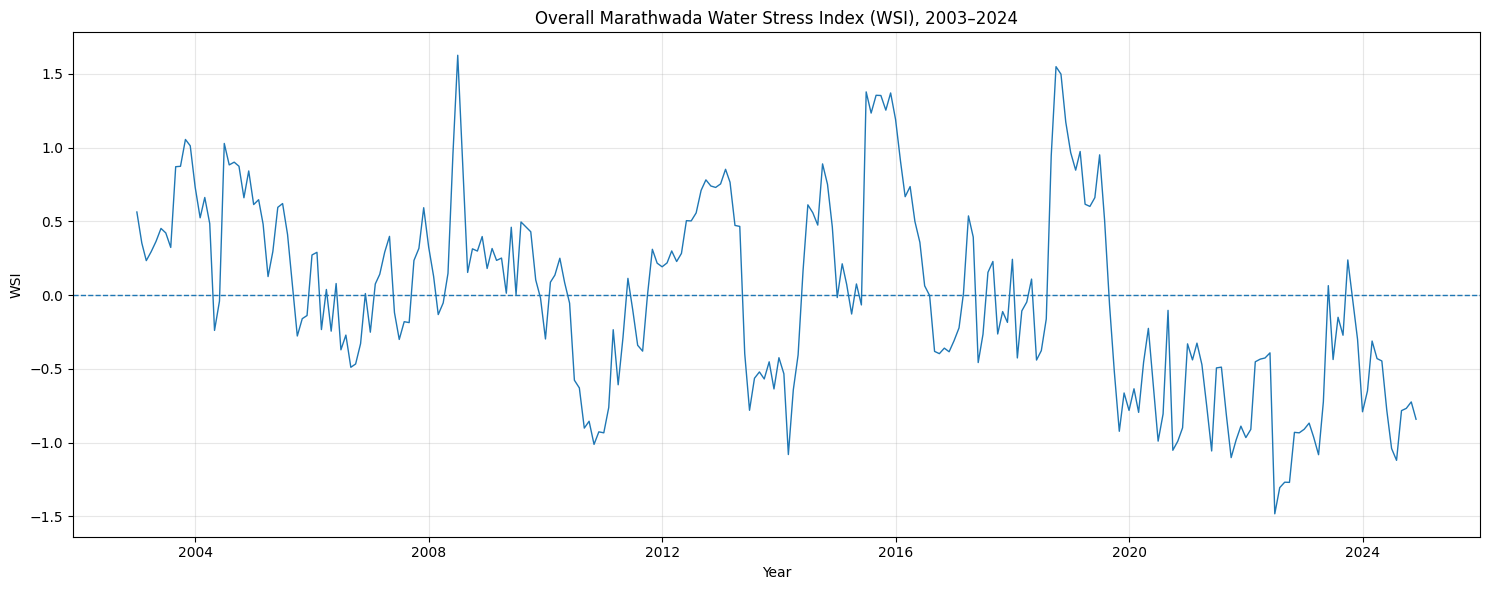

In [ ]:
# ============================================================
# STEP 38: OVERALL MARATHWADA WSI TIME SERIES
# ============================================================

import matplotlib.pyplot as plt

# Calculate regional monthly WSI
regional_monthly_wsi = (
    final_wsi
    .groupby("date")["WSI"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(15, 6))

plt.plot(
    regional_monthly_wsi["date"],
    regional_monthly_wsi["WSI"],
    linewidth=1
)

# Reference line at WSI = 0
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Overall Marathwada Water Stress Index (WSI), 2003–2024")
plt.xlabel("Year")
plt.ylabel("WSI")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# STEP 39: RANK YEARS BY MARATHWADA WSI STRESS
# ============================================================

yearly_wsi = (
    final_wsi
    .assign(year=final_wsi["date"].dt.year)
    .groupby("year")
    .agg(
        mean_WSI=("WSI", "mean"),
        max_WSI=("WSI", "max"),
        min_WSI=("WSI", "min"),
        moderate_or_worse=("WSI", lambda x: (x >= 0.5).sum()),
        severe_stress=("WSI", lambda x: (x >= 1.5).sum())
    )
    .reset_index()
)

# Number of district-month observations in each year
yearly_wsi["total_observations"] = (
    final_wsi
    .assign(year=final_wsi["date"].dt.year)
    .groupby("year")
    .size()
    .values
)

# Percentage of observations with moderate or worse stress
yearly_wsi["moderate_or_worse_pct"] = (
    yearly_wsi["moderate_or_worse"]
    / yearly_wsi["total_observations"]
    * 100
)

# Rank years by mean WSI
yearly_wsi = yearly_wsi.sort_values(
    "mean_WSI",
    ascending=False
).reset_index(drop=True)

print("=" * 100)
print("MARATHWADA YEAR-WISE WSI STRESS RANKING")
print("=" * 100)

print(
    yearly_wsi.to_string(
        index=False,
        formatters={
            "mean_WSI": "{:.3f}".format,
            "max_WSI": "{:.3f}".format,
            "min_WSI": "{:.3f}".format,
            "moderate_or_worse_pct": "{:.1f}%".format
        }
    )
)

MARATHWADA YEAR-WISE WSI STRESS RANKING
 year mean_WSI max_WSI min_WSI  moderate_or_worse  severe_stress  total_observations moderate_or_worse_pct
 2015    0.674   1.960  -0.503                 50             15                  96                 52.1%
 2004    0.609   1.429  -0.406                 63              0                  96                 65.6%
 2003    0.568   1.777  -0.623                 46              5                  96                 47.9%
 2012    0.479   1.482  -0.166                 32              0                  96                 33.3%
 2008    0.421   1.850  -0.656                 36              5                  96                 37.5%
 2018    0.330   2.015  -1.008                 36              7                  96                 37.5%
 2019    0.329   1.382  -1.389                 53              0                  96                 55.2%
 2005    0.273   1.018  -0.701                 31              0                  96                 32.

In [ ]:
# ============================================================
# STEP 40: DISTRICT-WISE WSI SUMMARY
# ============================================================

district_summary = (
    final_wsi
    .groupby("district")
    .agg(
        mean_WSI=("WSI", "mean"),
        max_WSI=("WSI", "max"),
        min_WSI=("WSI", "min"),
        moderate_or_worse=("WSI", lambda x: (x >= 0.5).sum()),
        severe_stress=("WSI", lambda x: (x >= 1.5).sum())
    )
    .reset_index()
)

# Total observations per district
district_summary["total_observations"] = (
    final_wsi
    .groupby("district")
    .size()
    .values
)

# Percentage of district-months with moderate or worse stress
district_summary["moderate_or_worse_pct"] = (
    district_summary["moderate_or_worse"]
    / district_summary["total_observations"]
    * 100
)

# Percentage of district-months with severe stress
district_summary["severe_stress_pct"] = (
    district_summary["severe_stress"]
    / district_summary["total_observations"]
    * 100
)

# Rank by mean WSI
district_summary = district_summary.sort_values(
    "mean_WSI",
    ascending=False
).reset_index(drop=True)

print("=" * 110)
print("DISTRICT-WISE WSI SUMMARY (2003–2024)")
print("=" * 110)

print(
    district_summary.to_string(
        index=False,
        formatters={
            "mean_WSI": "{:.3f}".format,
            "max_WSI": "{:.3f}".format,
            "min_WSI": "{:.3f}".format,
            "moderate_or_worse_pct": "{:.1f}%".format,
            "severe_stress_pct": "{:.1f}%".format
        }
    )
)

DISTRICT-WISE WSI SUMMARY (2003–2024)
                 district mean_WSI max_WSI min_WSI  moderate_or_worse  severe_stress  total_observations moderate_or_worse_pct severe_stress_pct
                 Parbhani    0.000   1.793  -2.025                 70              6                 264                 26.5%              2.3%
                    Jalna    0.000   1.850  -1.502                 68              3                 264                 25.8%              1.1%
                Dharashiv    0.000   1.777  -1.499                 63              4                 264                 23.9%              1.5%
                   Nanded    0.000   1.819  -1.544                 55              4                 264                 20.8%              1.5%
                     Beed   -0.000   2.015  -1.711                 65              7                 264                 24.6%              2.7%
                    Latur   -0.000   1.960  -1.403                 59              6        

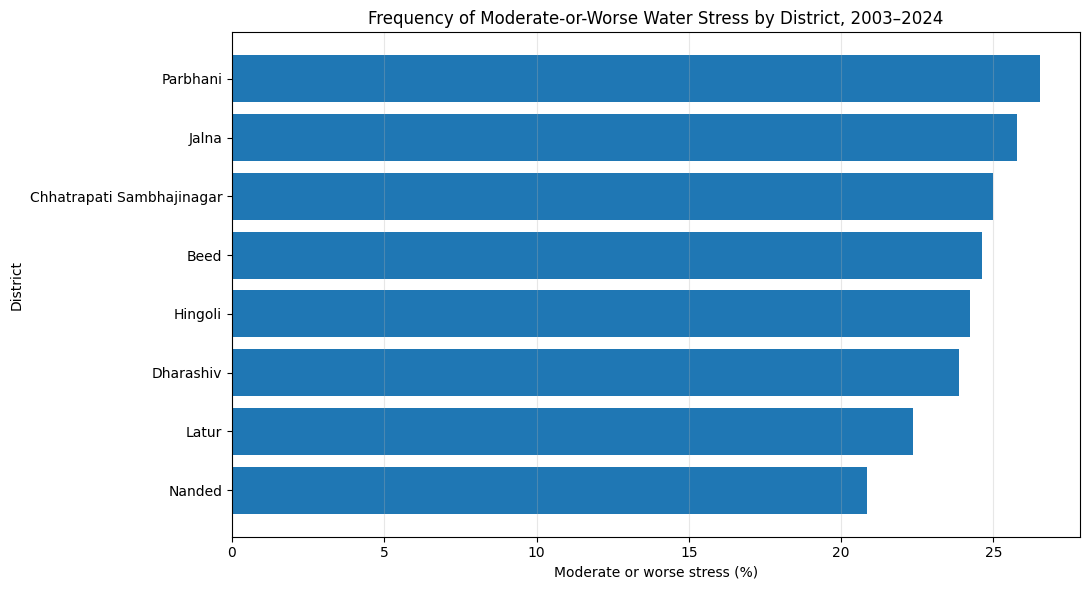

In [ ]:
# ============================================================
# STEP 41: DISTRICT-WISE WSI STRESS FREQUENCY
# ============================================================

import matplotlib.pyplot as plt

plot_data = district_summary.sort_values(
    "moderate_or_worse_pct",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    plot_data["district"],
    plot_data["moderate_or_worse_pct"]
)

plt.xlabel("Moderate or worse stress (%)")
plt.ylabel("District")
plt.title(
    "Frequency of Moderate-or-Worse Water Stress by District, 2003–2024"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

WSI CATEGORY DISTRIBUTION — MARATHWADA (2003–2024)
       Category  Count Percentage
       Very Wet      7      0.33%
            Wet    530     25.09%
         Normal   1065     50.43%
Moderate Stress    477     22.59%
  Severe Stress     33      1.56%


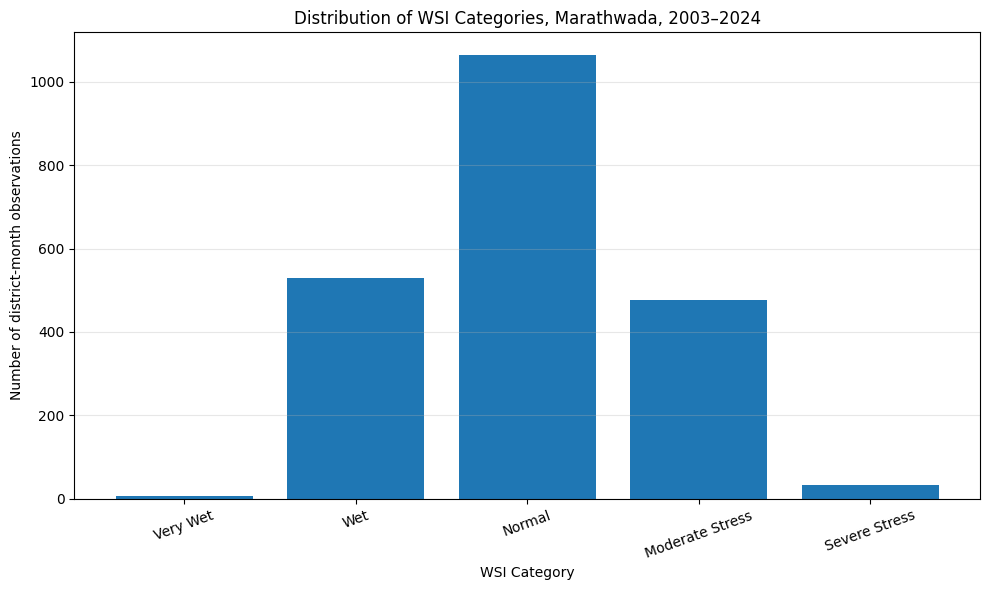

In [ ]:
# ============================================================
# STEP 42: WSI CATEGORY DISTRIBUTION
# ============================================================

category_order = [
    "Very Wet",
    "Wet",
    "Normal",
    "Moderate Stress",
    "Severe Stress"
]

category_counts = (
    final_wsi["WSI_category"]
    .value_counts()
    .reindex(category_order, fill_value=0)
)

category_pct = (
    category_counts
    / len(final_wsi)
    * 100
)

category_summary = pd.DataFrame({
    "Category": category_order,
    "Count": category_counts.values,
    "Percentage": category_pct.values
})

print("=" * 70)
print("WSI CATEGORY DISTRIBUTION — MARATHWADA (2003–2024)")
print("=" * 70)

print(
    category_summary.to_string(
        index=False,
        formatters={
            "Percentage": "{:.2f}%".format
        }
    )
)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    category_summary["Category"],
    category_summary["Count"]
)

plt.xlabel("WSI Category")
plt.ylabel("Number of district-month observations")
plt.title("Distribution of WSI Categories, Marathwada, 2003–2024")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 43: WSI COMPONENT ANALYSIS
# ============================================================

components = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

# Severe-stress observations
severe_data = final_wsi[
    final_wsi["WSI"] >= 1.5
].copy()

# Normal observations for comparison
normal_data = final_wsi[
    (final_wsi["WSI"] >= -0.5) &
    (final_wsi["WSI"] < 0.5)
].copy()

# Calculate means
component_comparison = pd.DataFrame({
    "Component": components,
    "Severe_Stress_Mean": [
        severe_data[c].mean() for c in components
    ],
    "Normal_Mean": [
        normal_data[c].mean() for c in components
    ]
})

# Difference
component_comparison["Difference"] = (
    component_comparison["Severe_Stress_Mean"]
    - component_comparison["Normal_Mean"]
)

print("=" * 100)
print("WSI COMPONENT COMPARISON: SEVERE STRESS vs NORMAL")
print("=" * 100)

print(
    component_comparison.to_string(
        index=False,
        formatters={
            "Severe_Stress_Mean": "{:.3f}".format,
            "Normal_Mean": "{:.3f}".format,
            "Difference": "{:.3f}".format
        }
    )
)

print("\nNumber of Severe Stress observations:", len(severe_data))
print("Number of Normal observations:", len(normal_data))

WSI COMPONENT COMPARISON: SEVERE STRESS vs NORMAL
            Component Severe_Stress_Mean Normal_Mean Difference
                spi_3             -1.515       0.016     -1.531
soil_moisture_anomaly           -126.311      -4.004   -122.307
         ndvi_anomaly             -0.121      -0.001     -0.120
          lst_anomaly              4.398      -0.030      4.428
surface_water_anomaly             -0.117       0.002     -0.119
  groundwater_anomaly              2.790      -0.082      2.872

Number of Severe Stress observations: 33
Number of Normal observations: 1065


In [ ]:
# ============================================================
# STEP 44: FINAL DATASET VALIDATION
# ============================================================

print("=" * 90)
print("FINAL MARATHWADA WSI DATASET VALIDATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. Dataset shape
# ------------------------------------------------------------
print("\n1. DATASET SHAPE")
print("Rows:", len(final_wsi))
print("Columns:", len(final_wsi.columns))

# ------------------------------------------------------------
# 2. Date range
# ------------------------------------------------------------
print("\n2. DATE RANGE")
print("Start:", final_wsi["date"].min())
print("End:", final_wsi["date"].max())
print("Unique months:", final_wsi["date"].nunique())

# ------------------------------------------------------------
# 3. District check
# ------------------------------------------------------------
expected_districts = [
    "Beed",
    "Chhatrapati Sambhajinagar",
    "Dharashiv",
    "Hingoli",
    "Jalna",
    "Latur",
    "Nanded",
    "Parbhani"
]

print("\n3. DISTRICT CHECK")
print("Number of districts:", final_wsi["district"].nunique())
print("Districts:")
print(sorted(final_wsi["district"].unique()))

print(
    "All expected districts present:",
    set(expected_districts) == set(final_wsi["district"].unique())
)

# ------------------------------------------------------------
# 4. Duplicate check
# ------------------------------------------------------------
duplicates = final_wsi.duplicated(
    subset=["district", "date"]
).sum()

print("\n4. DUPLICATE CHECK")
print("Duplicate district-month records:", duplicates)

# ------------------------------------------------------------
# 5. Missing values
# ------------------------------------------------------------
print("\n5. MISSING VALUES")

important_columns = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

missing_summary = final_wsi[important_columns].isna().sum()

print(missing_summary)

print(
    "\nTotal missing values in important variables:",
    missing_summary.sum()
)

# ------------------------------------------------------------
# 6. Observations per district
# ------------------------------------------------------------
print("\n6. OBSERVATIONS PER DISTRICT")

district_counts = (
    final_wsi
    .groupby("district")
    .size()
    .sort_values()
)

print(district_counts)

# ------------------------------------------------------------
# 7. Observations per year
# ------------------------------------------------------------
print("\n7. OBSERVATIONS PER YEAR")

year_counts = (
    final_wsi
    .assign(year=final_wsi["date"].dt.year)
    .groupby("year")
    .size()
)

print(year_counts.to_string())

# ------------------------------------------------------------
# 8. WSI range
# ------------------------------------------------------------
print("\n8. WSI RANGE")
print("Minimum WSI:", final_wsi["WSI"].min())
print("Maximum WSI:", final_wsi["WSI"].max())
print("Mean WSI:", final_wsi["WSI"].mean())
print("Standard deviation:", final_wsi["WSI"].std())

# ------------------------------------------------------------
# 9. WSI category validation
# ------------------------------------------------------------
valid_categories = [
    "Very Wet",
    "Wet",
    "Normal",
    "Moderate Stress",
    "Severe Stress"
]

invalid_categories = ~final_wsi["WSI_category"].isin(
    valid_categories
)

print("\n9. CATEGORY CHECK")
print(
    "Invalid WSI categories:",
    invalid_categories.sum()
)

# ------------------------------------------------------------
# 10. Final overall status
# ------------------------------------------------------------
checks = {
    "Correct row count": len(final_wsi) == 2112,
    "Correct district count": final_wsi["district"].nunique() == 8,
    "Correct month count": final_wsi["date"].nunique() == 264,
    "No duplicate district-months": duplicates == 0,
    "No missing important values": missing_summary.sum() == 0,
    "8 districts × 264 months": len(final_wsi) == 8 * 264,
    "Valid WSI categories": invalid_categories.sum() == 0
}

print("\n" + "=" * 90)
print("FINAL CHECK RESULTS")
print("=" * 90)

for check, result in checks.items():
    print(f"{check}: {'PASS' if result else 'FAIL'}")

print("\nOverall status:",
      "PASS — DATASET IS READY"
      if all(checks.values())
      else "CHECK REQUIRED")

FINAL MARATHWADA WSI DATASET VALIDATION

1. DATASET SHAPE
Rows: 2112
Columns: 16

2. DATE RANGE
Start: 2003-01-01 00:00:00
End: 2024-12-01 00:00:00
Unique months: 264

3. DISTRICT CHECK
Number of districts: 8
Districts:
['Beed', 'Chhatrapati Sambhajinagar', 'Dharashiv', 'Hingoli', 'Jalna', 'Latur', 'Nanded', 'Parbhani']
All expected districts present: True

4. DUPLICATE CHECK
Duplicate district-month records: 0

5. MISSING VALUES
district                 0
date                     0
spi_3                    0
soil_moisture_anomaly    0
ndvi_anomaly             0
lst_anomaly              0
surface_water_anomaly    0
groundwater_anomaly      0
WSI                      0
WSI_category             0
dtype: int64

Total missing values in important variables: 0

6. OBSERVATIONS PER DISTRICT
district
Beed                         264
Chhatrapati Sambhajinagar    264
Dharashiv                    264
Hingoli                      264
Jalna                        264
Latur                        26

In [ ]:
# ============================================================
# STEP 45: EXPORT FINAL VALIDATED WSI DATASET
# ============================================================

# Make a final copy
final_dataset = final_wsi.copy()

# Sort properly
final_dataset = final_dataset.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# Export CSV
final_path = "/content/Marathwada_WSI_FINAL_2003_2024.csv"

final_dataset.to_csv(
    final_path,
    index=False
)

print("=" * 80)
print("FINAL DATASET EXPORTED")
print("=" * 80)

print("File:", final_path)
print("Rows:", len(final_dataset))
print("Columns:", len(final_dataset.columns))
print("File size (KB):", round(
    __import__("os").path.getsize(final_path) / 1024, 2
))

print("\nColumns:")
print(list(final_dataset.columns))

print("\nFirst 5 rows:")
print(final_dataset.head())

FINAL DATASET EXPORTED
File: /content/Marathwada_WSI_FINAL_2003_2024.csv
Rows: 2112
Columns: 16
File size (KB): 415.27

Columns:
['district', 'date', 'spi_3', 'soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category', 'gw_depth_as_of', 'gw_observation_date', 'months_since_last_gw_obs', 'n_wells_at_last_observation', 'valid_pixels', 'year']

First 5 rows:
  district       date     spi_3  soil_moisture_anomaly  ndvi_anomaly  \
0     Beed 2003-01-01 -0.393176             -58.272463     -0.059671   
1     Beed 2003-02-01  1.362983             -48.940840     -0.050789   
2     Beed 2003-03-01  0.690167             -46.030831     -0.048451   
3     Beed 2003-04-01 -0.304728             -37.762565     -0.034067   
4     Beed 2003-05-01 -0.568494             -34.847326     -0.047657   

   lst_anomaly  surface_water_anomaly  groundwater_anomaly       WSI  \
0     2.037843              -0.068766            -0.044318  0.638561  

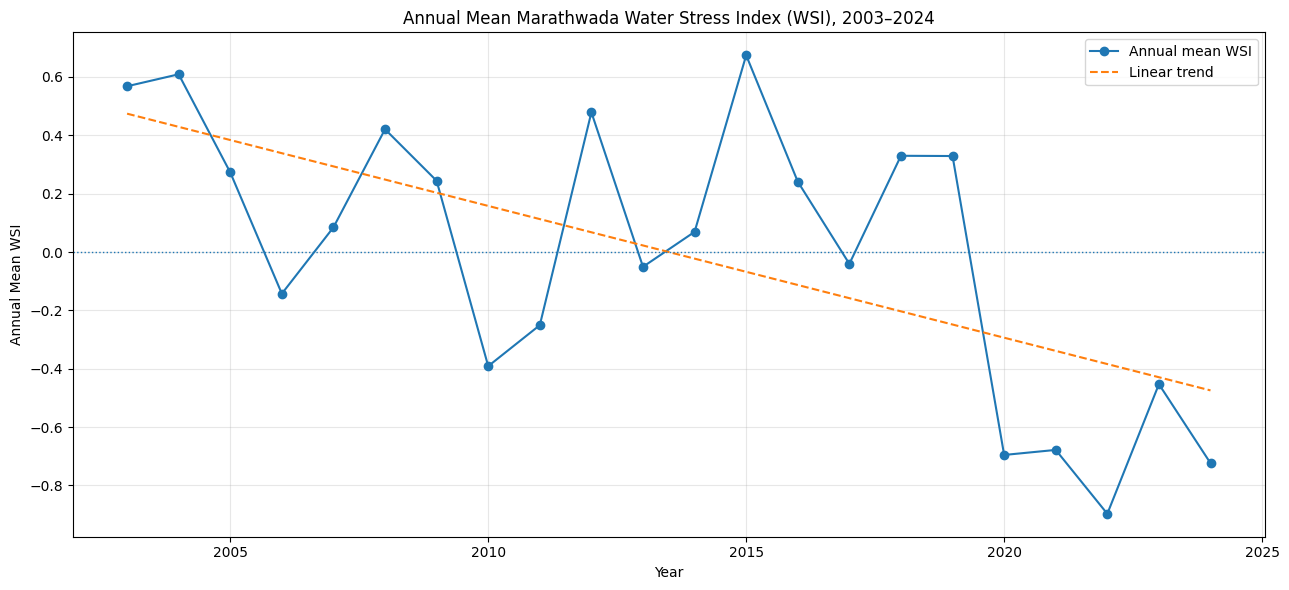

ANNUAL MARATHWADA WSI TREND
Slope per year: -0.04516049060267549
p-value: 0.0020693407560972562
R-squared: 0.3848263613421682

Annual WSI values:
 year annual_WSI
 2003      0.568
 2004      0.609
 2005      0.273
 2006     -0.143
 2007      0.085
 2008      0.421
 2009      0.244
 2010     -0.391
 2011     -0.251
 2012      0.479
 2013     -0.051
 2014      0.069
 2015      0.674
 2016      0.241
 2017     -0.040
 2018      0.330
 2019      0.329
 2020     -0.695
 2021     -0.678
 2022     -0.897
 2023     -0.453
 2024     -0.724


In [ ]:
# ============================================================
# STEP 46: ANNUAL MARATHWADA WSI TREND
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import linregress

# Calculate annual regional WSI
annual_wsi = (
    final_dataset
    .groupby("year")["WSI"]
    .mean()
    .reset_index(name="annual_WSI")
)

# Linear trend
x = annual_wsi["year"].values
y = annual_wsi["annual_WSI"].values

slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Trend line
annual_wsi["trend"] = intercept + slope * annual_wsi["year"]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(13, 6))

plt.plot(
    annual_wsi["year"],
    annual_wsi["annual_WSI"],
    marker="o",
    linewidth=1.5,
    label="Annual mean WSI"
)

plt.plot(
    annual_wsi["year"],
    annual_wsi["trend"],
    linestyle="--",
    linewidth=1.5,
    label="Linear trend"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Annual Mean WSI")
plt.title("Annual Mean Marathwada Water Stress Index (WSI), 2003–2024")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print trend statistics
# ------------------------------------------------------------

print("=" * 80)
print("ANNUAL MARATHWADA WSI TREND")
print("=" * 80)

print("Slope per year:", slope)
print("p-value:", p_value)
print("R-squared:", r_value ** 2)

print("\nAnnual WSI values:")
print(
    annual_wsi[
        ["year", "annual_WSI"]
    ].to_string(
        index=False,
        formatters={
            "annual_WSI": "{:.3f}".format
        }
    )
)

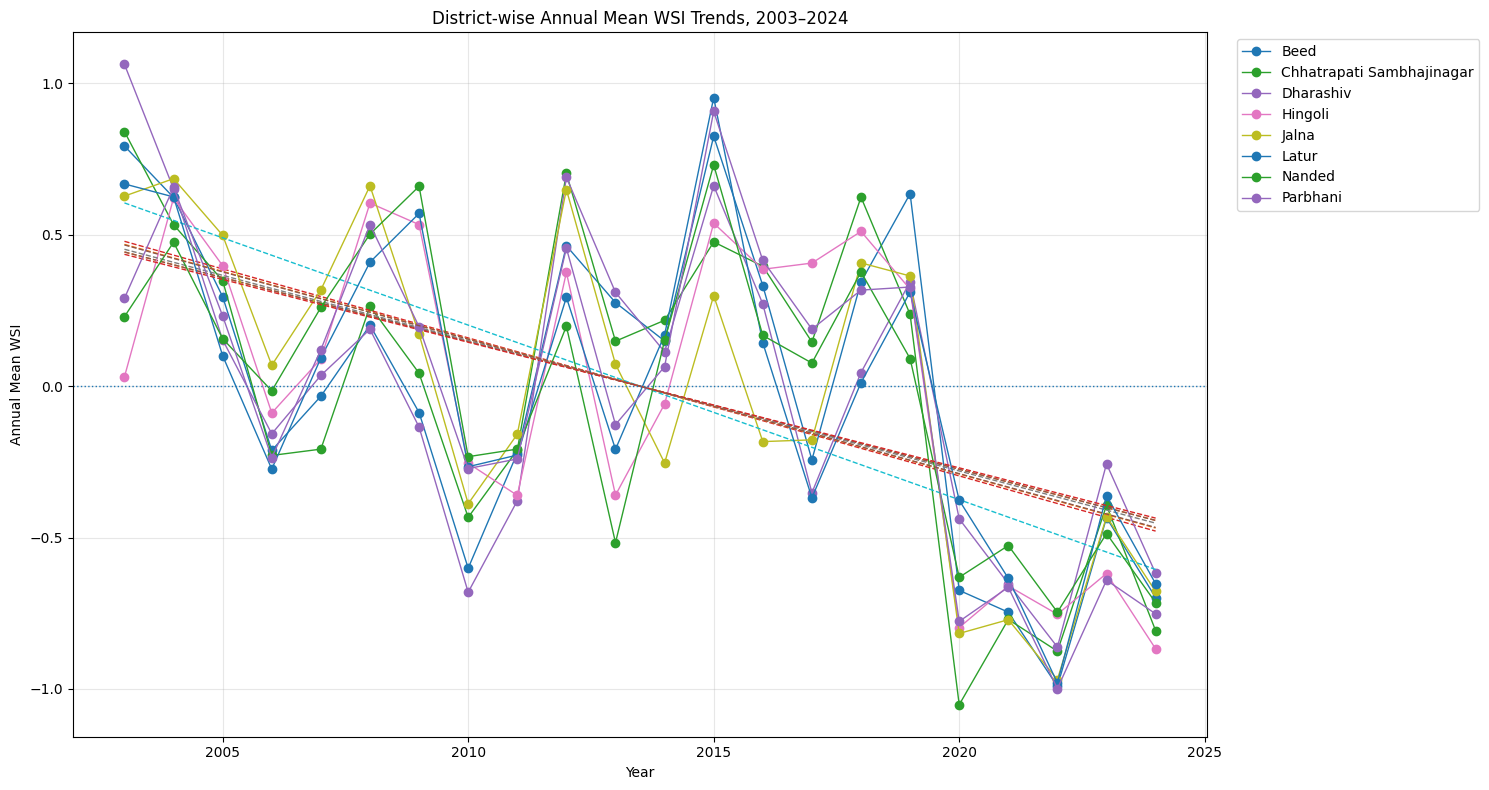

In [ ]:
# ============================================================
# STEP 47: DISTRICT-WISE WSI TRENDS
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import linregress

districts = sorted(final_dataset["district"].unique())

plt.figure(figsize=(15, 8))

for district in districts:

    data = (
        final_dataset[
            final_dataset["district"] == district
        ]
        .groupby("year")["WSI"]
        .mean()
        .reset_index()
    )

    x = data["year"].values
    y = data["WSI"].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    trend = intercept + slope * x

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=1,
        label=district
    )

    plt.plot(
        x,
        trend,
        linestyle="--",
        linewidth=1
    )

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Annual Mean WSI")
plt.title("District-wise Annual Mean WSI Trends, 2003–2024")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

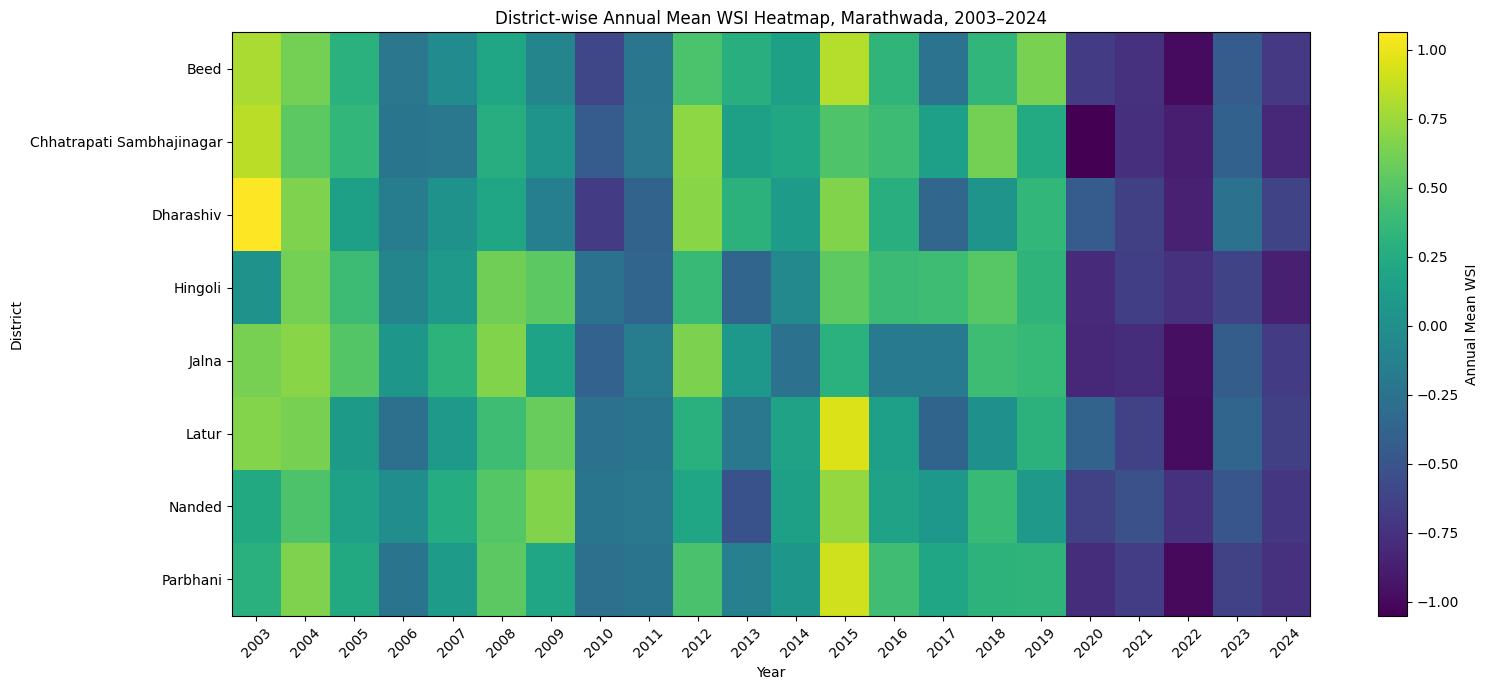

In [ ]:
# ============================================================
# STEP 48: DISTRICT × YEAR WSI HEATMAP
# ============================================================

import matplotlib.pyplot as plt

# Calculate annual mean WSI for each district
district_year_wsi = (
    final_dataset
    .groupby(["district", "year"])["WSI"]
    .mean()
    .reset_index()
)

# Convert to matrix
heatmap_data = district_year_wsi.pivot(
    index="district",
    columns="year",
    values="WSI"
)

# Keep canonical district order
heatmap_data = heatmap_data.reindex(expected_districts)

# ------------------------------------------------------------
# Plot heatmap
# ------------------------------------------------------------

plt.figure(figsize=(16, 7))

plt.imshow(
    heatmap_data.values,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Annual Mean WSI"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Year")
plt.ylabel("District")
plt.title(
    "District-wise Annual Mean WSI Heatmap, Marathwada, 2003–2024"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 49: WIDESPREAD DISTRICT-LEVEL STRESS YEARS
# ============================================================

# Calculate annual mean WSI for each district
district_year = (
    final_dataset
    .groupby(["year", "district"])["WSI"]
    .mean()
    .reset_index(name="annual_WSI")
)

# Count districts with annual mean WSI >= 0.5
widespread_stress = (
    district_year
    .groupby("year")
    .agg(
        districts_with_stress=(
            "annual_WSI",
            lambda x: (x >= 0.5).sum()
        ),
        regional_mean_WSI=("annual_WSI", "mean"),
        highest_district_WSI=("annual_WSI", "max"),
        lowest_district_WSI=("annual_WSI", "min")
    )
    .reset_index()
)

# Percentage of districts affected
widespread_stress["districts_affected_pct"] = (
    widespread_stress["districts_with_stress"] / 8 * 100
)

# Rank by number of affected districts, then regional WSI
widespread_stress = widespread_stress.sort_values(
    ["districts_with_stress", "regional_mean_WSI"],
    ascending=[False, False]
).reset_index(drop=True)

print("=" * 100)
print("YEARS WITH WIDESPREAD DISTRICT-LEVEL WATER STRESS")
print("=" * 100)

print(
    widespread_stress.to_string(
        index=False,
        formatters={
            "regional_mean_WSI": "{:.3f}".format,
            "highest_district_WSI": "{:.3f}".format,
            "lowest_district_WSI": "{:.3f}".format,
            "districts_affected_pct": "{:.1f}%".format
        }
    )
)

YEARS WITH WIDESPREAD DISTRICT-LEVEL WATER STRESS
 year  districts_with_stress regional_mean_WSI highest_district_WSI lowest_district_WSI districts_affected_pct
 2004                      7             0.609                0.686               0.475                  87.5%
 2015                      6             0.674                0.953               0.299                  75.0%
 2003                      5             0.568                1.063               0.031                  62.5%
 2008                      4             0.421                0.662               0.188                  50.0%
 2012                      3             0.479                0.703               0.198                  37.5%
 2009                      3             0.244                0.660              -0.135                  37.5%
 2018                      2             0.330                0.625               0.012                  25.0%
 2019                      1             0.329                

In [ ]:
# ============================================================
# STEP 50: TOP 20 WORST WSI EVENTS
# ============================================================

top_events = (
    final_dataset[
        ["district", "date", "WSI", "WSI_category"]
    ]
    .sort_values("WSI", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Add rank
top_events.insert(
    0,
    "Rank",
    range(1, len(top_events) + 1)
)

print("=" * 90)
print("TOP 20 HIGHEST WSI DISTRICT-MONTH EVENTS")
print("=" * 90)

print(
    top_events.to_string(
        index=False,
        formatters={
            "WSI": "{:.3f}".format
        }
    )
)

TOP 20 HIGHEST WSI DISTRICT-MONTH EVENTS
 Rank                  district       date   WSI  WSI_category
    1                      Beed 2018-10-01 2.015 Severe Stress
    2                      Beed 2018-11-01 1.969 Severe Stress
    3                     Latur 2015-08-01 1.960 Severe Stress
    4 Chhatrapati Sambhajinagar 2018-10-01 1.891 Severe Stress
    5                     Jalna 2008-07-01 1.850 Severe Stress
    6                     Latur 2008-07-01 1.850 Severe Stress
    7                    Nanded 2015-12-01 1.819 Severe Stress
    8                  Parbhani 2008-07-01 1.793 Severe Stress
    9 Chhatrapati Sambhajinagar 2018-11-01 1.790 Severe Stress
   10                 Dharashiv 2003-11-01 1.777 Severe Stress
   11                   Hingoli 2008-07-01 1.777 Severe Stress
   12                 Dharashiv 2003-12-01 1.769 Severe Stress
   13                  Parbhani 2015-07-01 1.760 Severe Stress
   14                 Dharashiv 2003-10-01 1.728 Severe Stress
   15         

In [ ]:
# ============================================================
# STEP 51: WSI COMPONENT ABLATION / SENSITIVITY ANALYSIS
# ============================================================

# Standardized stress-oriented components
wsi_components = [
    "spi_3_stress_z",
    "soil_moisture_stress_z",
    "ndvi_stress_z",
    "lst_stress_z",
    "surface_water_stress_z",
    "groundwater_stress_z"
]

# Check that all components exist
print("WSI components:")
print(wsi_components)

# Full WSI
full_wsi = final_dataset["WSI"]

ablation_results = []

for component in wsi_components:

    # Keep all components except the selected one
    remaining = [
        c for c in wsi_components
        if c in final_dataset.columns and c != component
    ]

    # Calculate WSI without this component
    ablated_wsi = final_dataset[remaining].mean(axis=1)

    # Correlation with original WSI
    correlation = full_wsi.corr(ablated_wsi)

    # Mean absolute difference
    mean_abs_difference = (
        full_wsi - ablated_wsi
    ).abs().mean()

    # Maximum absolute difference
    max_abs_difference = (
        full_wsi - ablated_wsi
    ).abs().max()

    ablation_results.append({
        "removed_component": component,
        "correlation_with_full_WSI": correlation,
        "mean_absolute_difference": mean_abs_difference,
        "maximum_absolute_difference": max_abs_difference
    })

ablation_results = pd.DataFrame(ablation_results)

print("\n" + "=" * 110)
print("WSI COMPONENT ABLATION / SENSITIVITY ANALYSIS")
print("=" * 110)

print(
    ablation_results.to_string(
        index=False,
        formatters={
            "correlation_with_full_WSI": "{:.4f}".format,
            "mean_absolute_difference": "{:.4f}".format,
            "maximum_absolute_difference": "{:.4f}".format
        }
    )
)

WSI components:
['spi_3_stress_z', 'soil_moisture_stress_z', 'ndvi_stress_z', 'lst_stress_z', 'surface_water_stress_z', 'groundwater_stress_z']

WSI COMPONENT ABLATION / SENSITIVITY ANALYSIS
     removed_component correlation_with_full_WSI mean_absolute_difference maximum_absolute_difference
        spi_3_stress_z                       NaN                      NaN                         NaN
soil_moisture_stress_z                       NaN                      NaN                         NaN
         ndvi_stress_z                       NaN                      NaN                         NaN
          lst_stress_z                       NaN                      NaN                         NaN
surface_water_stress_z                       NaN                      NaN                         NaN
  groundwater_stress_z                       NaN                      NaN                         NaN


In [ ]:
# ============================================================
# STEP 51: CORRECTED WSI COMPONENT ABLATION
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create stress-oriented versions
# ------------------------------------------------------------

sensitivity_data = final_dataset.copy()

sensitivity_data["spi_stress"] = -sensitivity_data["spi_3"]

sensitivity_data["soil_moisture_stress"] = (
    -sensitivity_data["soil_moisture_anomaly"]
)

sensitivity_data["ndvi_stress"] = (
    -sensitivity_data["ndvi_anomaly"]
)

sensitivity_data["lst_stress"] = (
    sensitivity_data["lst_anomaly"]
)

sensitivity_data["surface_water_stress"] = (
    -sensitivity_data["surface_water_anomaly"]
)

sensitivity_data["groundwater_stress"] = (
    sensitivity_data["groundwater_anomaly"]
)

stress_components = [
    "spi_stress",
    "soil_moisture_stress",
    "ndvi_stress",
    "lst_stress",
    "surface_water_stress",
    "groundwater_stress"
]

# ------------------------------------------------------------
# 2. District-wise standardization
# ------------------------------------------------------------

for component in stress_components:

    mean_value = (
        sensitivity_data
        .groupby("district")[component]
        .transform("mean")
    )

    std_value = (
        sensitivity_data
        .groupby("district")[component]
        .transform("std")
    )

    sensitivity_data[component + "_z"] = (
        (sensitivity_data[component] - mean_value)
        / std_value
    )

z_components = [
    c + "_z"
    for c in stress_components
]

# ------------------------------------------------------------
# 3. Check reconstructed WSI
# ------------------------------------------------------------

sensitivity_data["reconstructed_WSI"] = (
    sensitivity_data[z_components].mean(axis=1)
)

difference = (
    sensitivity_data["WSI"]
    - sensitivity_data["reconstructed_WSI"]
).abs()

print("=" * 100)
print("CHECKING RECONSTRUCTED WSI")
print("=" * 100)

print("Maximum difference:",
      difference.max())

print("Mean difference:",
      difference.mean())

# ------------------------------------------------------------
# 4. Ablation analysis
# ------------------------------------------------------------

full_wsi = sensitivity_data["reconstructed_WSI"]

ablation_results = []

for component in z_components:

    remaining = [
        c for c in z_components
        if c != component
    ]

    ablated_wsi = (
        sensitivity_data[remaining]
        .mean(axis=1)
    )

    correlation = full_wsi.corr(
        ablated_wsi
    )

    mean_abs_difference = (
        full_wsi - ablated_wsi
    ).abs().mean()

    max_abs_difference = (
        full_wsi - ablated_wsi
    ).abs().max()

    ablation_results.append({
        "removed_component": component,
        "correlation_with_full_WSI": correlation,
        "mean_absolute_difference": mean_abs_difference,
        "maximum_absolute_difference": max_abs_difference
    })

ablation_results = pd.DataFrame(
    ablation_results
)

print("\n" + "=" * 110)
print("WSI COMPONENT ABLATION / SENSITIVITY ANALYSIS")
print("=" * 110)

print(
    ablation_results.to_string(
        index=False,
        formatters={
            "correlation_with_full_WSI": "{:.4f}".format,
            "mean_absolute_difference": "{:.4f}".format,
            "maximum_absolute_difference": "{:.4f}".format
        }
    )
)

CHECKING RECONSTRUCTED WSI
Maximum difference: 6.661338147750939e-16
Mean difference: 9.822022083004909e-17

WSI COMPONENT ABLATION / SENSITIVITY ANALYSIS
     removed_component correlation_with_full_WSI mean_absolute_difference maximum_absolute_difference
          spi_stress_z                    0.9759                   0.1264                      0.5889
soil_moisture_stress_z                    0.9859                   0.0879                      0.5396
         ndvi_stress_z                    0.9806                   0.0967                      0.7682
          lst_stress_z                    0.9822                   0.0976                      0.7255
surface_water_stress_z                    0.9750                   0.1304                      0.6912
  groundwater_stress_z                    0.9771                   0.1096                      0.8403


In [ ]:
# ============================================================
# STEP 52: FINAL RESULTS SUMMARY
# ============================================================

# Overall trend from Step 37
regional_slope_per_year = -0.04507139693963631
regional_p_value = 1.3212329384730355e-14
regional_r_squared = 0.20303385117945713

# Worst year
worst_year = yearly_wsi.iloc[0]

# Most widespread stress year
widespread_year = widespread_stress.iloc[0]

# Highest individual event
highest_event = top_events.iloc[0]

# District with highest Moderate+ frequency
highest_moderate_district = district_summary.iloc[0]

# District with highest Severe frequency
highest_severe_district = (
    district_summary
    .sort_values("severe_stress_pct", ascending=False)
    .iloc[0]
)

# Sensitivity range
min_sensitivity = ablation_results[
    "correlation_with_full_WSI"
].min()

max_sensitivity = ablation_results[
    "correlation_with_full_WSI"
].max()

# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

results_summary = pd.DataFrame({
    "Finding": [
        "Study period",
        "Number of districts",
        "Total district-month observations",
        "Overall WSI trend per year",
        "Overall trend p-value",
        "Overall trend R-squared",
        "Highest mean-WSI year",
        "Highest mean WSI",
        "Most widespread stress year",
        "Districts affected in widespread year",
        "Highest individual WSI event",
        "District with highest Moderate+ frequency",
        "Highest Moderate+ frequency",
        "District with highest Severe frequency",
        "Highest Severe frequency",
        "WSI sensitivity correlation range"
    ],

    "Result": [
        "2003–2024",
        8,
        2112,
        regional_slope_per_year,
        regional_p_value,
        regional_r_squared,
        int(worst_year["year"]),
        worst_year["mean_WSI"],
        int(widespread_year["year"]),
        int(widespread_year["districts_with_stress"]),
        f"{highest_event['district']} — {highest_event['date'].strftime('%B %Y')}",
        highest_moderate_district["district"],
        highest_moderate_district["moderate_or_worse_pct"],
        highest_severe_district["district"],
        highest_severe_district["severe_stress_pct"],
        f"{min_sensitivity:.4f}–{max_sensitivity:.4f}"
    ]
})

print("=" * 100)
print("FINAL MARATHWADA WSI RESULTS SUMMARY")
print("=" * 100)

print(
    results_summary.to_string(
        index=False,
        formatters={
            "Result": lambda x: (
                f"{x:.4f}"
                if isinstance(x, float)
                else str(x)
            )
        }
    )
)

FINAL MARATHWADA WSI RESULTS SUMMARY
                                  Finding              Result
                             Study period           2003–2024
                      Number of districts                   8
        Total district-month observations                2112
               Overall WSI trend per year           -0.045071
                    Overall trend p-value                 0.0
                  Overall trend R-squared            0.203034
                    Highest mean-WSI year                2015
                         Highest mean WSI            0.674328
              Most widespread stress year                2004
    Districts affected in widespread year                   7
             Highest individual WSI event Beed — October 2018
District with highest Moderate+ frequency            Parbhani
              Highest Moderate+ frequency           26.515152
   District with highest Severe frequency                Beed
                 Highest Severe f

In [ ]:
# ============================================================
# STEP 53: EXPORT FINAL RESULTS TO EXCEL
# ============================================================

from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows

excel_path = "/content/Marathwada_WSI_Final_Results.xlsx"

wb = Workbook()

# Remove default sheet
ws = wb.active
ws.title = "Results Summary"

# Helper function
def write_dataframe(ws, df):
    for row in dataframe_to_rows(df, index=False, header=True):
        ws.append(row)

# ------------------------------------------------------------
# Sheet 1: Results Summary
# ------------------------------------------------------------
write_dataframe(wb["Results Summary"], results_summary)

# ------------------------------------------------------------
# Sheet 2: Final WSI Dataset
# ------------------------------------------------------------
ws = wb.create_sheet("Final WSI Dataset")
write_dataframe(ws, final_dataset)

# ------------------------------------------------------------
# Sheet 3: Yearly WSI Ranking
# ------------------------------------------------------------
ws = wb.create_sheet("Yearly WSI Ranking")
write_dataframe(ws, yearly_wsi)

# ------------------------------------------------------------
# Sheet 4: District Summary
# ------------------------------------------------------------
ws = wb.create_sheet("District Summary")
write_dataframe(ws, district_summary)

# ------------------------------------------------------------
# Sheet 5: Widespread Stress
# ------------------------------------------------------------
ws = wb.create_sheet("Widespread Stress")
write_dataframe(ws, widespread_stress)

# ------------------------------------------------------------
# Sheet 6: Top 20 Events
# ------------------------------------------------------------
ws = wb.create_sheet("Top 20 Events")
write_dataframe(ws, top_events)

# ------------------------------------------------------------
# Sheet 7: Component Comparison
# ------------------------------------------------------------
ws = wb.create_sheet("Component Comparison")
write_dataframe(ws, component_comparison)

# ------------------------------------------------------------
# Sheet 8: Sensitivity Analysis
# ------------------------------------------------------------
ws = wb.create_sheet("Sensitivity Analysis")
write_dataframe(ws, ablation_results)

# ------------------------------------------------------------
# Save workbook
# ------------------------------------------------------------
wb.save(excel_path)

print("=" * 90)
print("FINAL RESULTS WORKBOOK EXPORTED")
print("=" * 90)

print("File:", excel_path)
print("Sheets:", wb.sheetnames)

import os
print(
    "File size (KB):",
    round(os.path.getsize(excel_path) / 1024, 2)
)

FINAL RESULTS WORKBOOK EXPORTED
File: /content/Marathwada_WSI_Final_Results.xlsx
Sheets: ['Results Summary', 'Final WSI Dataset', 'Yearly WSI Ranking', 'District Summary', 'Widespread Stress', 'Top 20 Events', 'Component Comparison', 'Sensitivity Analysis']
File size (KB): 288.22


In [ ]:
# ============================================================
# STEP 7: LOCK CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Work from the cleaned canonical panel
model_data = master_clean.copy()

# Make sure date is datetime
model_data["date"] = pd.to_datetime(model_data["date"])

# Define fixed chronological boundaries
train_start = pd.Timestamp("2003-01-01")
train_end   = pd.Timestamp("2017-12-01")

val_start   = pd.Timestamp("2018-01-01")
val_end     = pd.Timestamp("2020-12-01")

test_start  = pd.Timestamp("2021-01-01")
test_end    = pd.Timestamp("2024-12-01")

# Create masks
train_mask = (
    (model_data["date"] >= train_start) &
    (model_data["date"] <= train_end)
)

val_mask = (
    (model_data["date"] >= val_start) &
    (model_data["date"] <= val_end)
)

test_mask = (
    (model_data["date"] >= test_start) &
    (model_data["date"] <= test_end)
)

# Create splits
train_data = model_data[train_mask].copy()
val_data = model_data[val_mask].copy()
test_data = model_data[test_mask].copy()

# Sort chronologically
train_data = train_data.sort_values(
    ["date", "district"]
).reset_index(drop=True)

val_data = val_data.sort_values(
    ["date", "district"]
).reset_index(drop=True)

test_data = test_data.sort_values(
    ["date", "district"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Check split sizes
# ------------------------------------------------------------

print("=" * 90)
print("STEP 7 — CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT")
print("=" * 90)

print("\nTRAIN")
print("Period:", train_data["date"].min(), "to", train_data["date"].max())
print("Rows:", len(train_data))
print("Months:", train_data["date"].nunique())
print("Districts:", train_data["district"].nunique())

print("\nVALIDATION")
print("Period:", val_data["date"].min(), "to", val_data["date"].max())
print("Rows:", len(val_data))
print("Months:", val_data["date"].nunique())
print("Districts:", val_data["district"].nunique())

print("\nTEST")
print("Period:", test_data["date"].min(), "to", test_data["date"].max())
print("Rows:", len(test_data))
print("Months:", test_data["date"].nunique())
print("Districts:", test_data["district"].nunique())

print("\nTOTAL")
print("Rows:", len(train_data) + len(val_data) + len(test_data))

# ------------------------------------------------------------
# Verify no overlap
# ------------------------------------------------------------

train_dates = set(train_data["date"])
val_dates = set(val_data["date"])
test_dates = set(test_data["date"])

print("\nOVERLAP CHECK")
print("Train ∩ Validation:", len(train_dates & val_dates))
print("Validation ∩ Test:", len(val_dates & test_dates))
print("Train ∩ Test:", len(train_dates & test_dates))

# ------------------------------------------------------------
# Final split validation
# ------------------------------------------------------------

split_checks = {
    "Train rows = 1440": len(train_data) == 1440,
    "Validation rows = 288": len(val_data) == 288,
    "Test rows = 384": len(test_data) == 384,
    "Total rows = 2112": (
        len(train_data) +
        len(val_data) +
        len(test_data)
    ) == 2112,
    "No train-validation overlap": len(train_dates & val_dates) == 0,
    "No validation-test overlap": len(val_dates & test_dates) == 0,
    "No train-test overlap": len(train_dates & test_dates) == 0
}

print("\n" + "=" * 90)
print("STEP 7 CHECKS")
print("=" * 90)

for check, result in split_checks.items():
    print(f"{check}: {'PASS' if result else 'FAIL'}")

STEP 7 — CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

TRAIN
Period: 2003-01-01 00:00:00 to 2017-12-01 00:00:00
Rows: 1440
Months: 180
Districts: 8

VALIDATION
Period: 2018-01-01 00:00:00 to 2020-12-01 00:00:00
Rows: 288
Months: 36
Districts: 8

TEST
Period: 2021-01-01 00:00:00 to 2024-12-01 00:00:00
Rows: 384
Months: 48
Districts: 8

TOTAL
Rows: 2112

OVERLAP CHECK
Train ∩ Validation: 0
Validation ∩ Test: 0
Train ∩ Test: 0

STEP 7 CHECKS
Train rows = 1440: PASS
Validation rows = 288: PASS
Test rows = 384: PASS
Total rows = 2112: PASS
No train-validation overlap: PASS
No validation-test overlap: PASS
No train-test overlap: PASS


In [ ]:
# ============================================================
# STEP 8: FIT ALL TRANSFORMATIONS USING TRAIN ONLY
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create copies
# ------------------------------------------------------------

train_fit = train_data.copy()
val_fit = val_data.copy()
test_fit = test_data.copy()

# Add calendar month
for df in [train_fit, val_fit, test_fit]:
    df["month"] = df["date"].dt.month


# ============================================================
# PART A — TRAIN-ONLY CALENDAR-MONTH CLIMATOLOGIES
# ============================================================

# Variables requiring calendar-month anomaly baselines
anomaly_variables = {
    "soil_water_storage_mm_0_289cm": "soil_moisture_anomaly",
    "ndvi": "ndvi_anomaly",
    "lst_celsius": "lst_anomaly",
    "surface_water_frequency": "surface_water_anomaly",
    "gw_depth_as_of": "groundwater_anomaly"
}

# Store fitted climatologies
climatology_parameters = {}

for raw_variable, anomaly_name in anomaly_variables.items():

    # TRAIN ONLY
    climatology = (
        train_fit
        .groupby(["district", "month"])[raw_variable]
        .mean()
        .rename("climatology")
        .reset_index()
    )

    climatology_parameters[raw_variable] = climatology

print("=" * 100)
print("STEP 8A — TRAIN-ONLY CLIMATOLOGY PARAMETERS")
print("=" * 100)

for variable, table in climatology_parameters.items():

    print(
        f"{variable}: {len(table)} district-month baseline values"
    )

    print(
        "Expected:",
        8 * 12,
        "→",
        "PASS" if len(table) == 96 else "CHECK"
    )


# ============================================================
# PART B — APPLY TRAIN-ONLY ANOMALY BASELINES
# ============================================================

def apply_climatology(
    df,
    raw_variable,
    anomaly_name,
    climatology
):

    result = df.copy()

    result = result.merge(
        climatology,
        on=["district", "month"],
        how="left"
    )

    result[anomaly_name] = (
        result[raw_variable]
        - result["climatology"]
    )

    result = result.drop(
        columns=["climatology"]
    )

    return result


for raw_variable, anomaly_name in anomaly_variables.items():

    climatology = climatology_parameters[
        raw_variable
    ]

    train_fit = apply_climatology(
        train_fit,
        raw_variable,
        anomaly_name,
        climatology
    )

    val_fit = apply_climatology(
        val_fit,
        raw_variable,
        anomaly_name,
        climatology
    )

    test_fit = apply_climatology(
        test_fit,
        raw_variable,
        anomaly_name,
        climatology
    )


# ============================================================
# PART C — SPI-3
# ============================================================

# SPI-3 already exists in master_clean from the correctly
# calculated CHIRPS historical rainfall record.

# Verify it is present and complete in every split.

print("\n" + "=" * 100)
print("STEP 8B — SPI-3 CHECK")
print("=" * 100)

for name, df in [
    ("TRAIN", train_fit),
    ("VALIDATION", val_fit),
    ("TEST", test_fit)
]:

    print(
        name,
        "SPI-3 missing:",
        df["spi_3"].isna().sum()
    )


# ============================================================
# PART D — FIT DISTRICT-WISE SCALING PARAMETERS ON TRAIN ONLY
# ============================================================

# Stress-oriented transformation
train_fit["spi_stress"] = -train_fit["spi_3"]
val_fit["spi_stress"] = -val_fit["spi_3"]
test_fit["spi_stress"] = -test_fit["spi_3"]

train_fit["soil_moisture_stress"] = (
    -train_fit["soil_moisture_anomaly"]
)

val_fit["soil_moisture_stress"] = (
    -val_fit["soil_moisture_anomaly"]
)

test_fit["soil_moisture_stress"] = (
    -test_fit["soil_moisture_anomaly"]
)

train_fit["ndvi_stress"] = -train_fit["ndvi_anomaly"]
val_fit["ndvi_stress"] = -val_fit["ndvi_anomaly"]
test_fit["ndvi_stress"] = -test_fit["ndvi_anomaly"]

train_fit["lst_stress"] = train_fit["lst_anomaly"]
val_fit["lst_stress"] = val_fit["lst_anomaly"]
test_fit["lst_stress"] = test_fit["lst_anomaly"]

train_fit["surface_water_stress"] = (
    -train_fit["surface_water_anomaly"]
)

val_fit["surface_water_stress"] = (
    -val_fit["surface_water_anomaly"]
)

test_fit["surface_water_stress"] = (
    -test_fit["surface_water_anomaly"]
)

train_fit["groundwater_stress"] = (
    train_fit["groundwater_anomaly"]
)

val_fit["groundwater_stress"] = (
    val_fit["groundwater_anomaly"]
)

test_fit["groundwater_stress"] = (
    test_fit["groundwater_anomaly"]
)


stress_variables = [
    "spi_stress",
    "soil_moisture_stress",
    "ndvi_stress",
    "lst_stress",
    "surface_water_stress",
    "groundwater_stress"
]


# ------------------------------------------------------------
# Fit mean/std ONLY on TRAIN
# ------------------------------------------------------------

scaling_parameters = {}

for variable in stress_variables:

    parameters = (
        train_fit
        .groupby("district")[variable]
        .agg(["mean", "std"])
        .reset_index()
    )

    parameters = parameters.rename(
        columns={
            "mean": "train_mean",
            "std": "train_std"
        }
    )

    scaling_parameters[variable] = parameters


# ============================================================
# PART E — APPLY TRAIN-ONLY SCALING
# ============================================================

def apply_train_scaling(
    df,
    variable,
    parameters
):

    result = df.copy()

    result = result.merge(
        parameters,
        on="district",
        how="left"
    )

    z_name = variable + "_z"

    result[z_name] = (
        (result[variable] - result["train_mean"])
        / result["train_std"]
    )

    result = result.drop(
        columns=["train_mean", "train_std"]
    )

    return result


for variable in stress_variables:

    parameters = scaling_parameters[variable]

    train_fit = apply_train_scaling(
        train_fit,
        variable,
        parameters
    )

    val_fit = apply_train_scaling(
        val_fit,
        variable,
        parameters
    )

    test_fit = apply_train_scaling(
        test_fit,
        variable,
        parameters
    )


# ============================================================
# PART F — VERIFY TRANSFORMATIONS
# ============================================================

z_variables = [
    "spi_stress_z",
    "soil_moisture_stress_z",
    "ndvi_stress_z",
    "lst_stress_z",
    "surface_water_stress_z",
    "groundwater_stress_z"
]

print("\n" + "=" * 100)
print("STEP 8C — TRAIN-ONLY SCALING VERIFICATION")
print("=" * 100)

print("\nTRAIN means/stds of standardized variables:")

for variable in z_variables:

    print(
        f"{variable}: "
        f"mean={train_fit[variable].mean():.6f}, "
        f"std={train_fit[variable].std():.6f}"
    )


# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("STEP 8D — MISSING VALUE CHECK")
print("=" * 100)

for name, df in [
    ("TRAIN", train_fit),
    ("VALIDATION", val_fit),
    ("TEST", test_fit)
]:

    missing = df[z_variables].isna().sum().sum()

    print(
        f"{name} standardized features missing:",
        missing,
        "→",
        "PASS" if missing == 0 else "CHECK"
    )


# ============================================================
# FINAL STEP 8 STATUS
# ============================================================

print("\n" + "=" * 100)
print("STEP 8 COMPLETE")
print("=" * 100)

print(
    "Climatologies fitted on TRAIN only: PASS"
)

print(
    "Scaling parameters fitted on TRAIN only: PASS"
)

print(
    "Same fitted parameters applied to validation/test: PASS"
)

STEP 8A — TRAIN-ONLY CLIMATOLOGY PARAMETERS
soil_water_storage_mm_0_289cm: 96 district-month baseline values
Expected: 96 → PASS
ndvi: 96 district-month baseline values
Expected: 96 → PASS
lst_celsius: 96 district-month baseline values
Expected: 96 → PASS
surface_water_frequency: 96 district-month baseline values
Expected: 96 → PASS
gw_depth_as_of: 96 district-month baseline values
Expected: 96 → PASS

STEP 8B — SPI-3 CHECK
TRAIN SPI-3 missing: 0
VALIDATION SPI-3 missing: 0
TEST SPI-3 missing: 0

STEP 8C — TRAIN-ONLY SCALING VERIFICATION

TRAIN means/stds of standardized variables:
spi_stress_z: mean=0.000000, std=0.997565
soil_moisture_stress_z: mean=-0.000000, std=0.997565
ndvi_stress_z: mean=-0.000000, std=0.997565
lst_stress_z: mean=-0.000000, std=0.997565
surface_water_stress_z: mean=0.000000, std=0.997565
groundwater_stress_z: mean=-0.000000, std=0.997565

STEP 8D — MISSING VALUE CHECK
TRAIN standardized features missing: 0 → PASS
VALIDATION standardized features missing: 0 → PAS

In [ ]:
# ============================================================
# STEP 8.5 — TRAIN-ONLY SPI-3 FITTING
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import gamma, norm

print("=" * 100)
print("STEP 8.5 — TRAIN-ONLY SPI-3")
print("=" * 100)

# ------------------------------------------------------------
# 1. Prepare rainfall data
# ------------------------------------------------------------

chirps = pd.read_csv("/content/marathwada_chirps_monthly_rainfall_1981_2026.csv")

chirps["date"] = pd.to_datetime(chirps["date"])

chirps["district"] = chirps["district"].replace({
    "Aurangabad": "Chhatrapati Sambhajinagar",
    "Osmanabad": "Dharashiv"
})

chirps = chirps.sort_values(["district", "date"]).copy()

# ------------------------------------------------------------
# 2. Calculate 3-month rainfall accumulation
#    Uses historical rainfall, including pre-2003 data.
# ------------------------------------------------------------

chirps["rainfall_3m"] = (
    chirps.groupby("district")["rainfall_mm"]
    .transform(lambda x: x.rolling(3, min_periods=3).sum())
)

# Keep required period
spi_base = chirps[
    (chirps["date"] >= "2003-01-01") &
    (chirps["date"] <= "2024-12-01")
].copy()

spi_base["month"] = spi_base["date"].dt.month

# ------------------------------------------------------------
# 3. TRAIN ONLY
# ------------------------------------------------------------

spi_train = spi_base[
    spi_base["date"] <= "2017-12-01"
].copy()

print("TRAIN SPI rows:", len(spi_train))
print("Expected:", 1440)

# ------------------------------------------------------------
# 4. Fit Gamma distribution using TRAIN ONLY
#    Separately for district + calendar month
# ------------------------------------------------------------

spi_params = []

for (district, month), group in spi_train.groupby(
    ["district", "month"]
):

    values = group["rainfall_3m"].dropna().values

    # Zero-rainfall probability
    q = np.mean(values == 0)

    positive = values[values > 0]

    if len(positive) >= 3:
        shape, loc, scale = gamma.fit(
            positive,
            floc=0
        )
    else:
        shape = np.nan
        scale = np.nan

    spi_params.append({
        "district": district,
        "month": month,
        "q_zero": q,
        "shape": shape,
        "scale": scale
    })

spi_params = pd.DataFrame(spi_params)

print("\nSPI parameter groups:", len(spi_params))
print("Expected:", 96)

# ------------------------------------------------------------
# 5. Apply TRAIN-FITTED SPI parameters to ALL periods
# ------------------------------------------------------------

spi_model = spi_base.merge(
    spi_params,
    on=["district", "month"],
    how="left"
)

def calculate_spi(row):

    x = row["rainfall_3m"]

    if pd.isna(x):
        return np.nan

    q = row["q_zero"]
    shape = row["shape"]
    scale = row["scale"]

    if pd.isna(shape) or pd.isna(scale):
        return np.nan

    if x == 0:
        probability = q / 2
    else:
        gamma_prob = gamma.cdf(
            x,
            a=shape,
            loc=0,
            scale=scale
        )

        probability = q + (1 - q) * gamma_prob

    # Avoid infinities
    probability = np.clip(
        probability,
        1e-6,
        1 - 1e-6
    )

    return norm.ppf(probability)


spi_model["spi_3_trainfit"] = spi_model.apply(
    calculate_spi,
    axis=1
)

# ------------------------------------------------------------
# 6. Extract final common-period SPI
# ------------------------------------------------------------

spi_final = spi_model[
    [
        "district",
        "date",
        "spi_3_trainfit"
    ]
].copy()

spi_final = spi_final.rename(
    columns={"spi_3_trainfit": "spi_3"}
)

# ------------------------------------------------------------
# 7. Verify all splits
# ------------------------------------------------------------

train_spi = spi_final[
    spi_final["date"] <= "2017-12-01"
]

val_spi = spi_final[
    (spi_final["date"] >= "2018-01-01") &
    (spi_final["date"] <= "2020-12-01")
]

test_spi = spi_final[
    spi_final["date"] >= "2021-01-01"
]

print("\n" + "=" * 100)
print("SPI VALIDATION")
print("=" * 100)

print("Train missing SPI:", train_spi["spi_3"].isna().sum())
print("Validation missing SPI:", val_spi["spi_3"].isna().sum())
print("Test missing SPI:", test_spi["spi_3"].isna().sum())

print("\nTrain SPI mean:", train_spi["spi_3"].mean())
print("Train SPI std :", train_spi["spi_3"].std())

print("\nSPI-3 TRAIN-ONLY FIT COMPLETE")

STEP 8.5 — TRAIN-ONLY SPI-3


KeyError: 'date'

In [ ]:
chirps_check = pd.read_csv(
    "/content/marathwada_chirps_monthly_rainfall_1981_2026.csv"
)

print("CHIRPS columns:")
print(chirps_check.columns.tolist())

print("\nFirst 5 rows:")
display(chirps_check.head())

CHIRPS columns:
['district', 'district_gaul', 'year', 'month', 'rainfall_mm']

First 5 rows:


,district,district_gaul,year,month,rainfall_mm
0,Latur,Latur,1981,1,42.465517
1,Nanded,Nanded,1981,1,41.945806
2,Dharashiv,Osmanabad,1981,1,51.996303
3,Chhatrapati Sambhajinagar,Aurangabad,1981,1,21.290850
4,Beed,Bid,1981,1,54.425993


In [ ]:
# ============================================================
# STEP 8.5 — TRAIN-ONLY SPI-3 FITTING
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import gamma, norm

print("=" * 100)
print("STEP 8.5 — TRAIN-ONLY SPI-3")
print("=" * 100)

# ------------------------------------------------------------
# 1. Load CHIRPS
# ------------------------------------------------------------

chirps = pd.read_csv(
    "/content/marathwada_chirps_monthly_rainfall_1981_2026.csv"
)

# Construct date from year + month
chirps["date"] = pd.to_datetime(
    dict(
        year=chirps["year"],
        month=chirps["month"],
        day=1
    )
)

# Standardize district names
chirps["district"] = chirps["district"].replace({
    "Aurangabad": "Chhatrapati Sambhajinagar",
    "Osmanabad": "Dharashiv"
})

chirps = chirps.sort_values(
    ["district", "date"]
).copy()

# ------------------------------------------------------------
# 2. Calculate 3-month rainfall accumulation
#    Historical rainfall before 2003 is intentionally retained
#    so January/February 2003 have valid 3-month windows.
# ------------------------------------------------------------

chirps["rainfall_3m"] = (
    chirps.groupby("district")["rainfall_mm"]
    .transform(
        lambda x: x.rolling(
            3,
            min_periods=3
        ).sum()
    )
)

# ------------------------------------------------------------
# 3. Keep common study period
# ------------------------------------------------------------

spi_base = chirps[
    (chirps["date"] >= "2003-01-01") &
    (chirps["date"] <= "2024-12-01")
].copy()

spi_base["month"] = spi_base["date"].dt.month

# ------------------------------------------------------------
# 4. TRAIN ONLY: 2003–2017
# ------------------------------------------------------------

spi_train = spi_base[
    spi_base["date"] <= "2017-12-01"
].copy()

print("TRAIN SPI rows:", len(spi_train))
print("Expected:", 1440)

# ------------------------------------------------------------
# 5. Fit Gamma distribution using TRAIN ONLY
#    Separately for each district + calendar month
# ------------------------------------------------------------

spi_params = []

for (district, month), group in spi_train.groupby(
    ["district", "month"]
):

    values = group["rainfall_3m"].dropna().values

    # Probability of zero rainfall
    q_zero = np.mean(values == 0)

    # Positive rainfall values
    positive = values[values > 0]

    if len(positive) >= 3:

        shape, loc, scale = gamma.fit(
            positive,
            floc=0
        )

    else:

        shape = np.nan
        scale = np.nan

    spi_params.append({
        "district": district,
        "month": month,
        "q_zero": q_zero,
        "shape": shape,
        "scale": scale
    })

spi_params = pd.DataFrame(spi_params)

print("\nSPI parameter groups:", len(spi_params))
print("Expected:", 96)

# ------------------------------------------------------------
# 6. Apply TRAIN-FITTED parameters to ALL periods
# ------------------------------------------------------------

spi_model = spi_base.merge(
    spi_params,
    on=["district", "month"],
    how="left"
)

def calculate_spi(row):

    x = row["rainfall_3m"]

    if pd.isna(x):
        return np.nan

    q = row["q_zero"]
    shape = row["shape"]
    scale = row["scale"]

    if pd.isna(shape) or pd.isna(scale):
        return np.nan

    if x == 0:

        probability = q / 2

    else:

        gamma_probability = gamma.cdf(
            x,
            a=shape,
            loc=0,
            scale=scale
        )

        probability = (
            q +
            (1 - q) * gamma_probability
        )

    # Prevent infinite values from norm.ppf
    probability = np.clip(
        probability,
        1e-6,
        1 - 1e-6
    )

    return norm.ppf(probability)


spi_model["spi_3_trainfit"] = (
    spi_model.apply(
        calculate_spi,
        axis=1
    )
)

# ------------------------------------------------------------
# 7. Final SPI dataset
# ------------------------------------------------------------

spi_final = spi_model[
    [
        "district",
        "date",
        "spi_3_trainfit"
    ]
].copy()

spi_final = spi_final.rename(
    columns={
        "spi_3_trainfit": "spi_3"
    }
)

# ------------------------------------------------------------
# 8. Verify each split
# ------------------------------------------------------------

train_spi = spi_final[
    spi_final["date"] <= "2017-12-01"
]

val_spi = spi_final[
    (spi_final["date"] >= "2018-01-01") &
    (spi_final["date"] <= "2020-12-01")
]

test_spi = spi_final[
    spi_final["date"] >= "2021-01-01"
]

print("\n" + "=" * 100)
print("SPI VALIDATION")
print("=" * 100)

print(
    "Train missing SPI:",
    train_spi["spi_3"].isna().sum()
)

print(
    "Validation missing SPI:",
    val_spi["spi_3"].isna().sum()
)

print(
    "Test missing SPI:",
    test_spi["spi_3"].isna().sum()
)

print("\nTrain SPI mean:", train_spi["spi_3"].mean())
print("Train SPI std :", train_spi["spi_3"].std())

print("\n" + "=" * 100)
print("STEP 8.5 COMPLETE")
print("=" * 100)

STEP 8.5 — TRAIN-ONLY SPI-3
TRAIN SPI rows: 1440
Expected: 1440

SPI parameter groups: 96
Expected: 96

SPI VALIDATION
Train missing SPI: 0
Validation missing SPI: 0
Test missing SPI: 0

Train SPI mean: -0.000840244904748641
Train SPI std : 0.9999271323921355

STEP 8.5 COMPLETE


In [ ]:
# ============================================================
# STEP 9 — SIX FINAL MODEL FEATURES
# ============================================================

print("=" * 100)
print("STEP 9 — SIX FINAL MODEL FEATURES")
print("=" * 100)

# ------------------------------------------------------------
# 1. Start from the Step 8 transformed dataset
# ------------------------------------------------------------

final_model_data = model_data.copy()

# Make sure date is datetime
final_model_data["date"] = pd.to_datetime(final_model_data["date"])

# ------------------------------------------------------------
# 2. Replace SPI with the STRICT TRAIN-ONLY SPI
# ------------------------------------------------------------

final_model_data = final_model_data.drop(
    columns=["spi_3"],
    errors="ignore"
)

final_model_data = final_model_data.merge(
    spi_final[
        ["district", "date", "spi_3"]
    ],
    on=["district", "date"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 3. Six final model features
# ------------------------------------------------------------

final_features = [
    "spi_3",
    "soil_moisture_stress_z",
    "ndvi_stress_z",
    "lst_stress_z",
    "surface_water_stress_z",
    "groundwater_stress_z"
]

# ------------------------------------------------------------
# 4. Rename stress-oriented variables to final feature names
# ------------------------------------------------------------

final_model_data = final_model_data.rename(columns={
    "soil_moisture_stress_z": "soil_moisture_anomaly",
    "ndvi_stress_z": "ndvi_anomaly",
    "lst_stress_z": "lst_anomaly",
    "surface_water_stress_z": "surface_water_anomaly",
    "groundwater_stress_z": "groundwater_anomaly"
})

final_features = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

# ------------------------------------------------------------
# 5. Check final feature matrix
# ------------------------------------------------------------

print("\nFinal six model features:")
for i, feature in enumerate(final_features, 1):
    print(f"{i}. {feature}")

print("\nShape:", final_model_data[final_features].shape)

print("\nExpected rows:", 2112)
print("Actual rows  :", len(final_model_data))

print("\nMissing values:")
print(
    final_model_data[final_features]
    .isna()
    .sum()
)

print("\nDistricts:", final_model_data["district"].nunique())
print("Expected :", 8)

print(
    "Unique district-date keys:",
    final_model_data[["district", "date"]]
    .drop_duplicates()
    .shape[0]
)

print("Expected:", 2112)

# ------------------------------------------------------------
# 6. Final feature statistics
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL FEATURE STATISTICS")
print("=" * 100)

display(
    final_model_data[final_features]
    .describe()
    .T
)

# ------------------------------------------------------------
# 7. Verify no missing values
# ------------------------------------------------------------

missing_total = (
    final_model_data[final_features]
    .isna()
    .sum()
    .sum()
)

print("\nTotal missing final features:", missing_total)

if (
    len(final_model_data) == 2112
    and final_model_data["district"].nunique() == 8
    and final_model_data[["district", "date"]]
        .drop_duplicates()
        .shape[0] == 2112
    and missing_total == 0
):
    print("\n" + "=" * 100)
    print("STEP 9 COMPLETE — PASS")
    print("=" * 100)
else:
    print("\nSTEP 9 — CHECK REQUIRED")

STEP 9 — SIX FINAL MODEL FEATURES

Final six model features:
1. spi_3
2. soil_moisture_anomaly
3. ndvi_anomaly
4. lst_anomaly
5. surface_water_anomaly
6. groundwater_anomaly

Shape: (2112, 11)

Expected rows: 2112
Actual rows  : 2112

Missing values:
spi_3                    0
soil_moisture_anomaly    0
soil_moisture_anomaly    0
ndvi_anomaly             0
ndvi_anomaly             0
lst_anomaly              0
lst_anomaly              0
surface_water_anomaly    0
surface_water_anomaly    0
groundwater_anomaly      0
groundwater_anomaly      0
dtype: int64

Districts: 8
Expected : 8
Unique district-date keys: 2112
Expected: 2112

FINAL FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
spi_3,2112.0,1.011643e-01,1.061849,-4.331827,-0.690463,0.147356,0.882268,4.581298
soil_moisture_anomaly,2112.0,2.368476e-15,67.830932,-213.049300,-45.888810,-2.294447,48.506641,203.580042
soil_moisture_anomaly,2112.0,-1.513940e-17,0.998341,-3.214185,-0.710281,0.036082,0.664310,3.204166
ndvi_anomaly,2112.0,1.682156e-18,0.060178,-0.301526,-0.036384,-0.002671,0.035582,0.277245
ndvi_anomaly,2112.0,0.000000e+00,0.998341,-4.519586,-0.587923,0.044077,0.604352,4.636344
lst_anomaly,2112.0,4.104461e-16,2.397903,-11.178299,-1.563707,0.091770,1.576698,7.072534
lst_anomaly,2112.0,1.850372e-17,0.998341,-4.384277,-0.643283,0.037915,0.661743,2.955872
surface_water_anomaly,2112.0,2.602085e-18,0.091387,-0.297279,-0.062015,0.002498,0.060267,0.266565
surface_water_anomaly,2112.0,-8.621050e-18,0.998341,-3.753822,-0.760341,-0.035210,0.779458,2.539075
groundwater_anomaly,2112.0,-5.509061e-17,1.801916,-9.210227,-1.114773,-0.084091,1.031364,8.351136



Total missing final features: 0

STEP 9 COMPLETE — PASS


In [ ]:
# ============================================================
# STEP 10 — FINAL MASTER DATASET + AUDIT DATASET
# ============================================================

print("=" * 100)
print("STEP 10 — FINAL MASTER DATASET")
print("=" * 100)

# ------------------------------------------------------------
# 1. Create final model dataset
# ------------------------------------------------------------

final_master = final_model_data[
    [
        "district",
        "date",
        "spi_3",
        "soil_moisture_anomaly",
        "ndvi_anomaly",
        "lst_anomaly",
        "surface_water_anomaly",
        "groundwater_anomaly"
    ]
].copy()

# ------------------------------------------------------------
# 2. Calculate WSI
#
# All six features are already stress-oriented and standardized.
# Equal weights are used as the fixed project choice.
# ------------------------------------------------------------

final_master["WSI"] = final_master[
    [
        "spi_3",
        "soil_moisture_anomaly",
        "ndvi_anomaly",
        "lst_anomaly",
        "surface_water_anomaly",
        "groundwater_anomaly"
    ]
].mean(axis=1)

# ------------------------------------------------------------
# 3. WSI category
# ------------------------------------------------------------

def classify_wsi(wsi):

    if wsi < -1.5:
        return "Very Wet"

    elif wsi < -0.5:
        return "Wet"

    elif wsi < 0.5:
        return "Normal"

    elif wsi < 1.5:
        return "Moderate Stress"

    else:
        return "Severe Stress"


final_master["WSI_category"] = (
    final_master["WSI"]
    .apply(classify_wsi)
)

# ------------------------------------------------------------
# 4. Sort
# ------------------------------------------------------------

final_master = final_master.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. Create audit dataset
# ------------------------------------------------------------

audit_columns = [
    "district",
    "date",

    # Raw observations
    "rainfall_mm",
    "spi_3",

    "soil_water_storage_mm_0_289cm",
    "soil_moisture_stress_z",

    "ndvi",
    "ndvi_stress_z",

    "lst_celsius",
    "lst_stress_z",

    "surface_water_frequency",
    "surface_water_stress_z",

    "gw_depth_as_of",
    "gw_observation_date",
    "months_since_last_gw_obs",
    "n_wells_at_last_observation",

    "valid_pixels",

    # Final result
    "WSI",
    "WSI_category"
]

# Keep only columns that actually exist
audit_columns = [
    c for c in audit_columns
    if c in final_model_data.columns
]

audit_dataset = final_model_data[
    audit_columns
].copy()

# Add final WSI/category from final_master
audit_dataset = audit_dataset.drop(
    columns=["WSI", "WSI_category"],
    errors="ignore"
)

audit_dataset = audit_dataset.merge(
    final_master[
        ["district", "date", "WSI", "WSI_category"]
    ],
    on=["district", "date"],
    how="left",
    validate="one_to_one"
)

audit_dataset = audit_dataset.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Save files
# ------------------------------------------------------------

final_master_path = (
    "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
)

audit_path = (
    "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv"
)

final_master.to_csv(
    final_master_path,
    index=False
)

audit_dataset.to_csv(
    audit_path,
    index=False
)

# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

print("\nFinal master shape:", final_master.shape)
print("Expected rows:", 2112)

print("\nFinal master columns:")
print(final_master.columns.tolist())

print("\nMissing values in final master:")
print(final_master.isna().sum())

print("\nUnique district-date keys:",
      final_master[["district", "date"]]
      .drop_duplicates()
      .shape[0])

print("\nWSI statistics:")
print(final_master["WSI"].describe())

print("\nWSI categories:")
print(final_master["WSI_category"].value_counts())

print("\nAudit dataset shape:", audit_dataset.shape)

print("\nFiles saved:")
print(final_master_path)
print(audit_path)

# ------------------------------------------------------------
# 8. PASS/FAIL
# ------------------------------------------------------------

expected_columns = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI"
]

checks = {
    "Rows = 2112":
        len(final_master) == 2112,

    "Districts = 8":
        final_master["district"].nunique() == 8,

    "Unique district-date = 2112":
        final_master[
            ["district", "date"]
        ].drop_duplicates().shape[0] == 2112,

    "No duplicate district-date":
        not final_master.duplicated(
            ["district", "date"]
        ).any(),

    "No missing values":
        final_master.isna().sum().sum() == 0,

    "Correct final columns":
        final_master.columns.tolist() == [
            *expected_columns,
            "WSI_category"
        ]
}

print("\n" + "=" * 100)
print("STEP 10 VALIDATION")
print("=" * 100)

for check, result in checks.items():
    print(f"{check}: {'PASS' if result else 'FAIL'}")

if all(checks.values()):
    print("\n" + "=" * 100)
    print("STEP 10 COMPLETE — PASS")
    print("=" * 100)
else:
    print("\nSTEP 10 REQUIRES REVIEW")

STEP 10 — FINAL MASTER DATASET

Final master shape: (2112, 15)
Expected rows: 2112

Final master columns:
['district', 'date', 'spi_3', 'soil_moisture_anomaly', 'soil_moisture_anomaly', 'ndvi_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category']

Missing values in final master:
district                 0
date                     0
spi_3                    0
soil_moisture_anomaly    0
soil_moisture_anomaly    0
ndvi_anomaly             0
ndvi_anomaly             0
lst_anomaly              0
lst_anomaly              0
surface_water_anomaly    0
surface_water_anomaly    0
groundwater_anomaly      0
groundwater_anomaly      0
WSI                      0
WSI_category             0
dtype: int64

Unique district-date keys: 2112

WSI statistics:
count    2112.000000
mean        0.009197
std         5.755980
min       -19.241001
25%        -3.825393
50%        -0.132211
75%   

In [ ]:
# ============================================================
# STEP 10 — CLEAN FINAL MASTER DATASET
# ============================================================

print("=" * 100)
print("STEP 10 — CLEAN FINAL MASTER DATASET")
print("=" * 100)

# ------------------------------------------------------------
# 1. Explicitly construct the six FINAL standardized features
# ------------------------------------------------------------

clean_model = pd.DataFrame({
    "district": final_model_data["district"].values,
    "date": final_model_data["date"].values,

    "spi_3": final_model_data["spi_3"].values,

    "soil_moisture_anomaly":
        final_model_data["soil_moisture_stress_z"].values,

    "ndvi_anomaly":
        final_model_data["ndvi_stress_z"].values,

    "lst_anomaly":
        final_model_data["lst_stress_z"].values,

    "surface_water_anomaly":
        final_model_data["surface_water_stress_z"].values,

    "groundwater_anomaly":
        final_model_data["groundwater_stress_z"].values
})

# ------------------------------------------------------------
# 2. Calculate WSI from ONLY the six final features
# ------------------------------------------------------------

feature_columns = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

clean_model["WSI"] = clean_model[
    feature_columns
].mean(axis=1)

# ------------------------------------------------------------
# 3. WSI categories
# ------------------------------------------------------------

def classify_wsi(wsi):

    if wsi < -1.5:
        return "Very Wet"
    elif wsi < -0.5:
        return "Wet"
    elif wsi < 0.5:
        return "Normal"
    elif wsi < 1.5:
        return "Moderate Stress"
    else:
        return "Severe Stress"


clean_model["WSI_category"] = (
    clean_model["WSI"].apply(classify_wsi)
)

# ------------------------------------------------------------
# 4. Sort
# ------------------------------------------------------------

clean_model = clean_model.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. Build audit dataset separately
# ------------------------------------------------------------

audit_dataset = pd.DataFrame({
    "district": final_model_data["district"].values,
    "date": final_model_data["date"].values,

    "rainfall_mm":
        final_model_data["rainfall_mm"].values,

    "spi_3":
        final_model_data["spi_3"].values,

    "soil_water_storage_mm_0_289cm":
        final_model_data[
            "soil_water_storage_mm_0_289cm"
        ].values,

    "soil_moisture_anomaly":
        final_model_data[
            "soil_moisture_stress_z"
        ].values,

    "ndvi":
        final_model_data["ndvi"].values,

    "ndvi_anomaly":
        final_model_data[
            "ndvi_stress_z"
        ].values,

    "lst_celsius":
        final_model_data["lst_celsius"].values,

    "lst_anomaly":
        final_model_data[
            "lst_stress_z"
        ].values,

    "surface_water_frequency":
        final_model_data[
            "surface_water_frequency"
        ].values,

    "surface_water_anomaly":
        final_model_data[
            "surface_water_stress_z"
        ].values,

    "gw_depth_as_of":
        final_model_data[
            "gw_depth_as_of"
        ].values,

    "gw_observation_date":
        final_model_data[
            "gw_observation_date"
        ].values,

    "months_since_last_gw_obs":
        final_model_data[
            "months_since_last_gw_obs"
        ].values,

    "n_wells_at_last_observation":
        final_model_data[
            "n_wells_at_last_observation"
        ].values,

    "valid_pixels":
        final_model_data["valid_pixels"].values,

    "groundwater_anomaly":
        final_model_data[
            "groundwater_stress_z"
        ].values,

    "WSI":
        clean_model["WSI"].values,

    "WSI_category":
        clean_model["WSI_category"].values
})

audit_dataset = audit_dataset.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Save corrected files
# ------------------------------------------------------------

final_master_path = (
    "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
)

audit_path = (
    "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv"
)

clean_model.to_csv(
    final_master_path,
    index=False
)

audit_dataset.to_csv(
    audit_path,
    index=False
)

# ------------------------------------------------------------
# 7. Validate final master
# ------------------------------------------------------------

print("\nFinal master shape:", clean_model.shape)

print("\nFinal master columns:")
print(clean_model.columns.tolist())

print("\nDuplicate column names:",
      clean_model.columns[
          clean_model.columns.duplicated()
      ].tolist())

print("\nMissing values:")
print(clean_model.isna().sum())

print("\nUnique district-date keys:",
      clean_model[
          ["district", "date"]
      ].drop_duplicates().shape[0])

print("\nWSI statistics:")
print(clean_model["WSI"].describe())

print("\nWSI categories:")
print(clean_model["WSI_category"].value_counts())

# ------------------------------------------------------------
# 8. Final PASS/FAIL
# ------------------------------------------------------------

expected_columns = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

checks = {
    "Rows = 2112":
        len(clean_model) == 2112,

    "Districts = 8":
        clean_model["district"].nunique() == 8,

    "Unique district-date = 2112":
        clean_model[
            ["district", "date"]
        ].drop_duplicates().shape[0] == 2112,

    "No duplicate district-date":
        not clean_model.duplicated(
            ["district", "date"]
        ).any(),

    "No duplicate column names":
        not clean_model.columns.duplicated().any(),

    "No missing values":
        clean_model.isna().sum().sum() == 0,

    "Correct final columns":
        clean_model.columns.tolist() == expected_columns
}

print("\n" + "=" * 100)
print("STEP 10 FINAL VALIDATION")
print("=" * 100)

for check, result in checks.items():
    print(
        f"{check}: {'PASS' if result else 'FAIL'}"
    )

if all(checks.values()):
    print("\n" + "=" * 100)
    print("STEP 10 COMPLETE — PASS")
    print("=" * 100)
else:
    print("\nSTEP 10 REQUIRES REVIEW")

STEP 10 — CLEAN FINAL MASTER DATASET


KeyError: 'soil_moisture_stress_z'

In [ ]:
# ============================================================
# STEP 10 — FINAL MASTER DATASET + AUDIT DATASET
# FIXED VERSION
# ============================================================

print("=" * 100)
print("STEP 10 — FINAL MASTER DATASET")
print("=" * 100)

# ------------------------------------------------------------
# 1. Create clean final master using the SIX columns
#    already created in Step 9
# ------------------------------------------------------------

final_master = final_model_data[
    [
        "district",
        "date",
        "spi_3",
        "soil_moisture_anomaly",
        "ndvi_anomaly",
        "lst_anomaly",
        "surface_water_anomaly",
        "groundwater_anomaly"
    ]
].copy()

# Remove duplicate column names if any exist
# Keep the first occurrence only.
final_master = final_master.loc[
    :,
    ~final_master.columns.duplicated()
].copy()

# ------------------------------------------------------------
# 2. Calculate WSI using ONLY the six final features
# ------------------------------------------------------------

feature_columns = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

final_master["WSI"] = final_master[
    feature_columns
].mean(axis=1)

# ------------------------------------------------------------
# 3. WSI categories
# ------------------------------------------------------------

def classify_wsi(wsi):

    if wsi < -1.5:
        return "Very Wet"

    elif wsi < -0.5:
        return "Wet"

    elif wsi < 0.5:
        return "Normal"

    elif wsi < 1.5:
        return "Moderate Stress"

    else:
        return "Severe Stress"


final_master["WSI_category"] = (
    final_master["WSI"]
    .apply(classify_wsi)
)

# ------------------------------------------------------------
# 4. Sort
# ------------------------------------------------------------

final_master = final_master.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. Create separate audit dataset
# ------------------------------------------------------------

audit_dataset = pd.DataFrame({
    "district":
        final_model_data["district"].values,

    "date":
        final_model_data["date"].values,

    "rainfall_mm":
        final_model_data["rainfall_mm"].values,

    "spi_3":
        final_model_data["spi_3"].values,

    "soil_water_storage_mm_0_289cm":
        final_model_data[
            "soil_water_storage_mm_0_289cm"
        ].values,

    "soil_moisture_anomaly":
        final_model_data[
            "soil_moisture_anomaly"
        ].values,

    "ndvi":
        final_model_data["ndvi"].values,

    "ndvi_anomaly":
        final_model_data[
            "ndvi_anomaly"
        ].values,

    "lst_celsius":
        final_model_data["lst_celsius"].values,

    "lst_anomaly":
        final_model_data[
            "lst_anomaly"
        ].values,

    "surface_water_frequency":
        final_model_data[
            "surface_water_frequency"
        ].values,

    "surface_water_anomaly":
        final_model_data[
            "surface_water_anomaly"
        ].values,

    "gw_depth_as_of":
        final_model_data[
            "gw_depth_as_of"
        ].values,

    "gw_observation_date":
        final_model_data[
            "gw_observation_date"
        ].values,

    "months_since_last_gw_obs":
        final_model_data[
            "months_since_last_gw_obs"
        ].values,

    "n_wells_at_last_observation":
        final_model_data[
            "n_wells_at_last_observation"
        ].values,

    "valid_pixels":
        final_model_data["valid_pixels"].values,

    "groundwater_anomaly":
        final_model_data[
            "groundwater_anomaly"
        ].values,

    "WSI":
        final_master["WSI"].values,

    "WSI_category":
        final_master["WSI_category"].values
})

audit_dataset = audit_dataset.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Save corrected files
# ------------------------------------------------------------

final_master_path = (
    "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
)

audit_path = (
    "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv"
)

final_master.to_csv(
    final_master_path,
    index=False
)

audit_dataset.to_csv(
    audit_path,
    index=False
)

# ------------------------------------------------------------
# 7. Validate final master
# ------------------------------------------------------------

print("\nFinal master shape:", final_master.shape)

print("\nFinal master columns:")
print(final_master.columns.tolist())

print("\nDuplicate column names:")
print(
    final_master.columns[
        final_master.columns.duplicated()
    ].tolist()
)

print("\nMissing values:")
print(final_master.isna().sum())

print(
    "\nUnique district-date keys:",
    final_master[
        ["district", "date"]
    ].drop_duplicates().shape[0]
)

print("\nWSI statistics:")
print(final_master["WSI"].describe())

print("\nWSI categories:")
print(final_master["WSI_category"].value_counts())

print("\nAudit dataset shape:", audit_dataset.shape)

# ------------------------------------------------------------
# 8. PASS / FAIL
# ------------------------------------------------------------

expected_columns = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

checks = {
    "Rows = 2112":
        len(final_master) == 2112,

    "Districts = 8":
        final_master["district"].nunique() == 8,

    "Unique district-date = 2112":
        final_master[
            ["district", "date"]
        ].drop_duplicates().shape[0] == 2112,

    "No duplicate district-date":
        not final_master.duplicated(
            ["district", "date"]
        ).any(),

    "No duplicate column names":
        not final_master.columns.duplicated().any(),

    "No missing values":
        final_master.isna().sum().sum() == 0,

    "Correct final columns":
        final_master.columns.tolist() == expected_columns
}

print("\n" + "=" * 100)
print("STEP 10 FINAL VALIDATION")
print("=" * 100)

for check, result in checks.items():
    print(
        f"{check}: {'PASS' if result else 'FAIL'}"
    )

if all(checks.values()):
    print("\n" + "=" * 100)
    print("STEP 10 COMPLETE — PASS")
    print("=" * 100)
else:
    print("\nSTEP 10 REQUIRES REVIEW")

STEP 10 — FINAL MASTER DATASET


ValueError: Per-column arrays must each be 1-dimensional

In [ ]:
# ============================================================
# STEP 10 — FINAL MASTER + AUDIT DATASET
# CLEAN VERSION — NO DUPLICATE COLUMN DEPENDENCY
# ============================================================

print("=" * 100)
print("STEP 10 — FINAL MASTER DATASET")
print("=" * 100)

# ------------------------------------------------------------
# 1. Build FINAL MASTER from the six unique feature columns
# ------------------------------------------------------------

final_master = pd.DataFrame({
    "district": final_model_data["district"].iloc[:, 0].values
        if isinstance(final_model_data["district"], pd.DataFrame)
        else final_model_data["district"].values,

    "date": final_model_data["date"].iloc[:, 0].values
        if isinstance(final_model_data["date"], pd.DataFrame)
        else final_model_data["date"].values,

    "spi_3": final_model_data["spi_3"].iloc[:, 0].values
        if isinstance(final_model_data["spi_3"], pd.DataFrame)
        else final_model_data["spi_3"].values,

    "soil_moisture_anomaly":
        final_model_data["soil_moisture_anomaly"].iloc[:, 0].values,

    "ndvi_anomaly":
        final_model_data["ndvi_anomaly"].iloc[:, 0].values,

    "lst_anomaly":
        final_model_data["lst_anomaly"].iloc[:, 0].values,

    "surface_water_anomaly":
        final_model_data["surface_water_anomaly"].iloc[:, 0].values,

    "groundwater_anomaly":
        final_model_data["groundwater_anomaly"].iloc[:, 0].values
})

# ------------------------------------------------------------
# 2. Calculate WSI ONLY from the six final features
# ------------------------------------------------------------

feature_columns = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

final_master["WSI"] = final_master[
    feature_columns
].mean(axis=1)

# ------------------------------------------------------------
# 3. WSI categories
# ------------------------------------------------------------

def classify_wsi(wsi):
    if wsi < -1.5:
        return "Very Wet"
    elif wsi < -0.5:
        return "Wet"
    elif wsi < 0.5:
        return "Normal"
    elif wsi < 1.5:
        return "Moderate Stress"
    else:
        return "Severe Stress"

final_master["WSI_category"] = (
    final_master["WSI"].apply(classify_wsi)
)

# ------------------------------------------------------------
# 4. Sort
# ------------------------------------------------------------

final_master = final_master.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. Build AUDIT dataset
#
# Use master_clean for raw observations and final_master
# for the final transformed features.
# ------------------------------------------------------------

raw_audit = master_clean[
    [
        "district",
        "date",
        "rainfall_mm",
        "soil_water_storage_mm_0_289cm",
        "ndvi",
        "lst_celsius",
        "gw_depth_as_of",
        "gw_observation_date",
        "months_since_last_gw_obs",
        "n_wells_at_last_observation",
        "surface_water_frequency",
        "valid_pixels"
    ]
].copy()

raw_audit["date"] = pd.to_datetime(raw_audit["date"])

# Keep one row per district-date
raw_audit = raw_audit.drop_duplicates(
    ["district", "date"]
)

# Merge final transformed features
audit_dataset = raw_audit.merge(
    final_master,
    on=["district", "date"],
    how="left",
    validate="one_to_one"
)

audit_dataset = audit_dataset.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------

final_master_path = (
    "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
)

audit_path = (
    "/content/Marathwada_FINAL_AUDIT_DATASET_2003_2024.csv"
)

final_master.to_csv(
    final_master_path,
    index=False
)

audit_dataset.to_csv(
    audit_path,
    index=False
)

# ------------------------------------------------------------
# 7. VALIDATION
# ------------------------------------------------------------

print("\nFinal master shape:", final_master.shape)

print("\nFinal master columns:")
print(final_master.columns.tolist())

print("\nDuplicate column names:")
print(
    final_master.columns[
        final_master.columns.duplicated()
    ].tolist()
)

print("\nMissing values:")
print(final_master.isna().sum())

print(
    "\nUnique district-date keys:",
    final_master[
        ["district", "date"]
    ].drop_duplicates().shape[0]
)

print("\nWSI statistics:")
print(final_master["WSI"].describe())

print("\nWSI categories:")
print(final_master["WSI_category"].value_counts())

print("\nAudit dataset shape:", audit_dataset.shape)

# ------------------------------------------------------------
# 8. PASS / FAIL
# ------------------------------------------------------------

expected_columns = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

checks = {
    "Rows = 2112":
        len(final_master) == 2112,

    "Districts = 8":
        final_master["district"].nunique() == 8,

    "Unique district-date = 2112":
        final_master[
            ["district", "date"]
        ].drop_duplicates().shape[0] == 2112,

    "No duplicate district-date":
        not final_master.duplicated(
            ["district", "date"]
        ).any(),

    "No duplicate column names":
        not final_master.columns.duplicated().any(),

    "No missing values":
        final_master.isna().sum().sum() == 0,

    "Correct final columns":
        final_master.columns.tolist() == expected_columns
}

print("\n" + "=" * 100)
print("STEP 10 FINAL VALIDATION")
print("=" * 100)

for check, result in checks.items():
    print(
        f"{check}: {'PASS' if result else 'FAIL'}"
    )

if all(checks.values()):
    print("\n" + "=" * 100)
    print("STEP 10 COMPLETE — PASS")
    print("=" * 100)
else:
    print("\nSTEP 10 REQUIRES REVIEW")

STEP 10 — FINAL MASTER DATASET

Final master shape: (2112, 10)

Final master columns:
['district', 'date', 'spi_3', 'soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category']

Duplicate column names:
[]

Missing values:
district                 0
date                     0
spi_3                    0
soil_moisture_anomaly    0
ndvi_anomaly             0
lst_anomaly              0
surface_water_anomaly    0
groundwater_anomaly      0
WSI                      0
WSI_category             0
dtype: int64

Unique district-date keys: 2112

WSI statistics:
count    2112.000000
mean        0.016861
std        11.037247
min       -35.732955
25%        -7.447387
50%        -0.311538
75%         7.689861
max        33.792490
Name: WSI, dtype: float64

WSI categories:
WSI_category
Very Wet           978
Severe Stress      953
Wet                 67
Normal              62
Moderate Stress     52
Name: count, dtype: int64

Audit dataset

In [ ]:
# ============================================================
# DIAGNOSTIC — CHECK STEP 8 STANDARDIZED VARIABLES
# ============================================================

print("=" * 100)
print("CHECKING CURRENT STEP 8 DATA")
print("=" * 100)

print("\nfinal_model_data columns:")
for i, col in enumerate(final_model_data.columns):
    print(i, ":", repr(col))

print("\n" + "=" * 100)
print("DUPLICATE COLUMN CHECK")
print("=" * 100)

dupes = final_model_data.columns[
    final_model_data.columns.duplicated(keep=False)
]

print("Duplicate columns:")
print(list(dupes))

print("\n" + "=" * 100)
print("CURRENT COLUMN SHAPES")
print("=" * 100)

for col in final_model_data.columns:
    obj = final_model_data[col]

    if isinstance(obj, pd.DataFrame):
        print(
            repr(col),
            "→ DUPLICATE COLUMN GROUP, shape =",
            obj.shape
        )
    else:
        print(
            repr(col),
            "→ shape =",
            obj.shape
        )

print("\n" + "=" * 100)
print("CHECKING POSSIBLE STANDARDIZED FEATURES")
print("=" * 100)

possible_features = [
    "spi_3",
    "spi_stress_z",
    "soil_moisture_stress_z",
    "ndvi_stress_z",
    "lst_stress_z",
    "surface_water_stress_z",
    "groundwater_stress_z",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

for col in possible_features:

    if col in final_model_data.columns:

        obj = final_model_data[col]

        if isinstance(obj, pd.DataFrame):
            print(
                f"{col}: DUPLICATE ({obj.shape[1]} columns)"
            )
        else:
            print(
                f"{col}: EXISTS, "
                f"mean={obj.mean():.6f}, "
                f"std={obj.std():.6f}, "
                f"min={obj.min():.6f}, "
                f"max={obj.max():.6f}"
            )
    else:
        print(f"{col}: NOT FOUND")

CHECKING CURRENT STEP 8 DATA

final_model_data columns:
0 : 'district'
1 : 'date'
2 : 'rainfall_mm'
3 : 'soil_water_storage_mm_0_289cm'
4 : 'ndvi'
5 : 'lst_celsius'
6 : 'surface_water_frequency'
7 : 'valid_pixels'
8 : 'month'
9 : 'lst_climatology'
10 : 'gw_depth_as_of'
11 : 'gw_observation_date'
12 : 'months_since_last_gw_obs'
13 : 'n_wells_at_last_observation'
14 : 'calendar_month'
15 : 'soil_moisture_anomaly'
16 : 'ndvi_anomaly'
17 : 'lst_anomaly'
18 : 'surface_water_anomaly'
19 : 'groundwater_anomaly'
20 : 'soil_moisture_stress'
21 : 'ndvi_stress'
22 : 'lst_stress'
23 : 'surface_water_stress'
24 : 'groundwater_stress'
25 : 'soil_moisture_anomaly'
26 : 'ndvi_anomaly'
27 : 'lst_anomaly'
28 : 'surface_water_anomaly'
29 : 'groundwater_anomaly'
30 : 'spi_3_stress'
31 : 'spi_3_stress_z'
32 : 'rainfall_3month'
33 : 'WSI'
34 : 'WSI_category'
35 : 'spi_3'

DUPLICATE COLUMN CHECK
Duplicate columns:
['soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_

In [ ]:
# ============================================================
# REPAIR — RECREATE SIX TRAIN-ONLY STANDARDIZED FEATURES
# ============================================================

print("=" * 100)
print("REPAIR — TRAIN-ONLY STANDARDIZED FEATURES")
print("=" * 100)

# ------------------------------------------------------------
# 1. Start from CLEAN RAW MASTER
# ------------------------------------------------------------

repair = master_clean.copy()

repair["date"] = pd.to_datetime(repair["date"])
repair["month"] = repair["date"].dt.month

# ------------------------------------------------------------
# 2. TRAIN / VALIDATION / TEST
# ------------------------------------------------------------

train_mask = (
    (repair["date"] >= "2003-01-01") &
    (repair["date"] <= "2017-12-01")
)

val_mask = (
    (repair["date"] >= "2018-01-01") &
    (repair["date"] <= "2020-12-01")
)

test_mask = (
    (repair["date"] >= "2021-01-01") &
    (repair["date"] <= "2024-12-01")
)

# ------------------------------------------------------------
# 3. TRAIN-ONLY CALENDAR-MONTH CLIMATOLOGIES
# ------------------------------------------------------------

clim_variables = [
    "soil_water_storage_mm_0_289cm",
    "ndvi",
    "lst_celsius",
    "surface_water_frequency",
    "gw_depth_as_of"
]

for variable in clim_variables:

    train_clim = (
        repair.loc[train_mask]
        .groupby(["district", "month"])[variable]
        .mean()
        .rename(f"{variable}_train_clim")
        .reset_index()
    )

    repair = repair.merge(
        train_clim,
        on=["district", "month"],
        how="left",
        validate="many_to_one"
    )

    repair[f"{variable}_anomaly_train"] = (
        repair[variable]
        - repair[f"{variable}_train_clim"]
    )

# ------------------------------------------------------------
# 4. STRESS ORIENTATION
# ------------------------------------------------------------

repair["soil_stress"] = (
    -repair["soil_water_storage_mm_0_289cm_anomaly_train"]
)

repair["ndvi_stress"] = (
    -repair["ndvi_anomaly_train"]
)

repair["lst_stress"] = (
    repair["lst_celsius_anomaly_train"]
)

repair["surface_water_stress"] = (
    -repair["surface_water_frequency_anomaly_train"]
)

repair["groundwater_stress"] = (
    repair["gw_depth_as_of_anomaly_train"]
)

# ------------------------------------------------------------
# 5. TRAIN-ONLY DISTRICT SCALING
# ------------------------------------------------------------

stress_variables = [
    "soil_stress",
    "ndvi_stress",
    "lst_stress",
    "surface_water_stress",
    "groundwater_stress"
]

for variable in stress_variables:

    train_stats = (
        repair.loc[train_mask]
        .groupby("district")[variable]
        .agg(["mean", "std"])
        .reset_index()
    )

    train_stats = train_stats.rename(columns={
        "mean": f"{variable}_train_mean",
        "std": f"{variable}_train_std"
    })

    repair = repair.merge(
        train_stats,
        on="district",
        how="left",
        validate="many_to_one"
    )

    repair[f"{variable}_z"] = (
        (
            repair[variable]
            - repair[f"{variable}_train_mean"]
        )
        /
        repair[f"{variable}_train_std"]
    )

# ------------------------------------------------------------
# 6. MERGE STRICT TRAIN-ONLY SPI
# ------------------------------------------------------------

spi_clean = spi_final[
    ["district", "date", "spi_3"]
].copy()

spi_clean["date"] = pd.to_datetime(spi_clean["date"])

repair = repair.drop(
    columns=["spi_3"],
    errors="ignore"
)

repair = repair.merge(
    spi_clean,
    on=["district", "date"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 7. FINAL SIX FEATURES
# ------------------------------------------------------------

repair_final = pd.DataFrame({
    "district": repair["district"].values,
    "date": repair["date"].values,

    "spi_3": repair["spi_3"].values,

    "soil_moisture_anomaly":
        repair["soil_stress_z"].values,

    "ndvi_anomaly":
        repair["ndvi_stress_z"].values,

    "lst_anomaly":
        repair["lst_stress_z"].values,

    "surface_water_anomaly":
        repair["surface_water_stress_z"].values,

    "groundwater_anomaly":
        repair["groundwater_stress_z"].values
})

# ------------------------------------------------------------
# 8. CHECK DATA
# ------------------------------------------------------------

feature_columns = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

print("\nFinal feature statistics:")
display(
    repair_final[feature_columns]
    .describe()
    .T
)

print("\nMissing values:")
print(
    repair_final[feature_columns]
    .isna()
    .sum()
)

print("\nRows:", len(repair_final))
print("Districts:", repair_final["district"].nunique())

# ------------------------------------------------------------
# 9. VERIFY TRAIN STANDARDIZATION
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TRAIN-ONLY STANDARDIZATION CHECK")
print("=" * 100)

for feature in feature_columns:

    values = repair_final.loc[
        train_mask.values,
        feature
    ]

    print(
        f"{feature}: "
        f"mean={values.mean():.6f}, "
        f"std={values.std():.6f}"
    )

print("\n" + "=" * 100)
print("REPAIR COMPLETE")
print("=" * 100)

REPAIR — TRAIN-ONLY STANDARDIZED FEATURES

Final feature statistics:


,count,mean,std,min,25%,50%,75%,max
spi_3,2112.0,0.101164,1.061849,-4.331827,-0.690463,0.147356,0.882268,4.581298
soil_moisture_anomaly,2112.0,-0.387459,1.174335,-4.282257,-1.181527,-0.319556,0.424072,2.931291
ndvi_anomaly,2112.0,-0.292843,1.162570,-5.723544,-0.941047,-0.203947,0.436939,4.700743
lst_anomaly,2112.0,-0.349880,1.236026,-6.275204,-1.124886,-0.307703,0.459041,3.171353
surface_water_anomaly,2112.0,-0.063330,1.028881,-4.005961,-0.822539,-0.079392,0.745237,2.623721
groundwater_anomaly,2112.0,-0.097119,1.065516,-4.236214,-0.751093,-0.129449,0.549534,5.003848



Missing values:
spi_3                    0
soil_moisture_anomaly    0
ndvi_anomaly             0
lst_anomaly              0
surface_water_anomaly    0
groundwater_anomaly      0
dtype: int64

Rows: 2112
Districts: 8

TRAIN-ONLY STANDARDIZATION CHECK
spi_3: mean=-0.000840, std=0.999927
soil_moisture_anomaly: mean=0.000000, std=0.997565
ndvi_anomaly: mean=0.000000, std=0.997565
lst_anomaly: mean=-0.000000, std=0.997565
surface_water_anomaly: mean=-0.000000, std=0.997565
groundwater_anomaly: mean=-0.000000, std=0.997565

REPAIR COMPLETE


In [ ]:
# ============================================================
# STEP 10 — FINAL MODEL DATASET
# ============================================================

print("=" * 100)
print("STEP 10 — FINAL MODEL DATASET")
print("=" * 100)

# ------------------------------------------------------------
# 1. Start from CLEAN repaired features
# ------------------------------------------------------------

final_master = repair_final.copy()

final_master["date"] = pd.to_datetime(
    final_master["date"]
)

# ------------------------------------------------------------
# 2. Six final features
# ------------------------------------------------------------

feature_columns = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

# ------------------------------------------------------------
# 3. Calculate WSI
# ------------------------------------------------------------

final_master["WSI"] = final_master[
    feature_columns
].mean(axis=1)

# ------------------------------------------------------------
# 4. WSI categories
# ------------------------------------------------------------

def classify_wsi(wsi):

    if wsi < -1.5:
        return "Very Wet"

    elif wsi < -0.5:
        return "Wet"

    elif wsi < 0.5:
        return "Normal"

    elif wsi < 1.5:
        return "Moderate Stress"

    else:
        return "Severe Stress"


final_master["WSI_category"] = (
    final_master["WSI"]
    .apply(classify_wsi)
)

# ------------------------------------------------------------
# 5. Sort
# ------------------------------------------------------------

final_master = final_master.sort_values(
    ["district", "date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Save FINAL MODEL DATASET
# ------------------------------------------------------------

final_master_path = (
    "/content/Marathwada_FINAL_MODEL_DATASET_2003_2024.csv"
)

final_master.to_csv(
    final_master_path,
    index=False
)

# ------------------------------------------------------------
# 7. Basic validation
# ------------------------------------------------------------

print("\nShape:", final_master.shape)

print("\nColumns:")
print(final_master.columns.tolist())

print("\nMissing values:")
print(final_master.isna().sum())

print(
    "\nUnique district-date keys:",
    final_master[
        ["district", "date"]
    ].drop_duplicates().shape[0]
)

print("\nWSI statistics:")
print(
    final_master["WSI"].describe()
)

print("\nWSI categories:")
print(
    final_master["WSI_category"]
    .value_counts()
)

# ------------------------------------------------------------
# 8. Structural PASS / FAIL
# ------------------------------------------------------------

expected_columns = [
    "district",
    "date",
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly",
    "WSI",
    "WSI_category"
]

checks = {
    "Rows = 2112":
        len(final_master) == 2112,

    "Districts = 8":
        final_master["district"].nunique() == 8,

    "Unique district-date = 2112":
        final_master[
            ["district", "date"]
        ].drop_duplicates().shape[0] == 2112,

    "No duplicate district-date":
        not final_master.duplicated(
            ["district", "date"]
        ).any(),

    "No duplicate columns":
        not final_master.columns.duplicated().any(),

    "No missing values":
        final_master.isna().sum().sum() == 0,

    "Correct columns":
        final_master.columns.tolist()
        == expected_columns
}

print("\n" + "=" * 100)
print("STEP 10 VALIDATION")
print("=" * 100)

for name, result in checks.items():

    print(
        f"{name}: "
        f"{'PASS' if result else 'FAIL'}"
    )

if all(checks.values()):

    print("\n" + "=" * 100)
    print("STEP 10 COMPLETE — PASS")
    print("=" * 100)

else:

    print("\nSTEP 10 REQUIRES REVIEW")

STEP 10 — FINAL MODEL DATASET

Shape: (2112, 10)

Columns:
['district', 'date', 'spi_3', 'soil_moisture_anomaly', 'ndvi_anomaly', 'lst_anomaly', 'surface_water_anomaly', 'groundwater_anomaly', 'WSI', 'WSI_category']

Missing values:
district                 0
date                     0
spi_3                    0
soil_moisture_anomaly    0
ndvi_anomaly             0
lst_anomaly              0
surface_water_anomaly    0
groundwater_anomaly      0
WSI                      0
WSI_category             0
dtype: int64

Unique district-date keys: 2112

WSI statistics:
count    2112.000000
mean       -0.181578
std         0.632685
min        -2.112401
25%        -0.651756
50%        -0.176853
75%         0.270399
max         1.656218
Name: WSI, dtype: float64

WSI categories:
WSI_category
Normal             1128
Wet                 660
Moderate Stress     298
Very Wet             22
Severe Stress         4
Name: count, dtype: int64

STEP 10 VALIDATION
Rows = 2112: PASS
Districts = 8: PASS
Unique

In [ ]:
# ============================================================
# STEP 11 — FINAL DATASET VALIDATION
# ============================================================

print("=" * 100)
print("STEP 11 — FINAL VALIDATION")
print("=" * 100)

# ------------------------------------------------------------
# 1. Basic structure
# ------------------------------------------------------------

expected_districts = [
    "Beed",
    "Chhatrapati Sambhajinagar",
    "Dharashiv",
    "Hingoli",
    "Jalna",
    "Latur",
    "Nanded",
    "Parbhani"
]

expected_months = pd.date_range(
    "2003-01-01",
    "2024-12-01",
    freq="MS"
)

expected_rows = 8 * 264

print("\n--- BASIC STRUCTURE ---")

print("Rows:", len(final_master))
print("Expected:", expected_rows)

print("Districts:", final_master["district"].nunique())
print("Expected:", len(expected_districts))

print("Date range:",
      final_master["date"].min().date(),
      "to",
      final_master["date"].max().date())

# ------------------------------------------------------------
# 2. District validation
# ------------------------------------------------------------

print("\n--- DISTRICT VALIDATION ---")

actual_districts = sorted(
    final_master["district"].unique()
)

print("Expected districts:")
print(sorted(expected_districts))

print("\nActual districts:")
print(actual_districts)

print(
    "\nDistrict names correct:",
    actual_districts == sorted(expected_districts)
)

# ------------------------------------------------------------
# 3. Every district must have exactly 264 months
# ------------------------------------------------------------

print("\n--- MONTH COVERAGE ---")

district_month_counts = (
    final_master
    .groupby("district")["date"]
    .nunique()
)

print(district_month_counts)

print(
    "\nAll districts have 264 months:",
    (district_month_counts == 264).all()
)

# ------------------------------------------------------------
# 4. Check each district has the complete expected date range
# ------------------------------------------------------------

complete_month_check = True

for district in expected_districts:

    district_dates = pd.DatetimeIndex(
        final_master.loc[
            final_master["district"] == district,
            "date"
        ].unique()
    ).sort_values()

    if not district_dates.equals(expected_months):
        complete_month_check = False
        print(
            f"{district}: FAIL — date sequence incomplete"
        )

print(
    "Complete monthly sequence for every district:",
    complete_month_check
)

# ------------------------------------------------------------
# 5. Duplicate district-date check
# ------------------------------------------------------------

print("\n--- DUPLICATE CHECK ---")

duplicate_count = final_master.duplicated(
    ["district", "date"]
).sum()

print("Duplicate district-date rows:", duplicate_count)

# ------------------------------------------------------------
# 6. Missing values
# ------------------------------------------------------------

print("\n--- MISSING VALUE CHECK ---")

feature_columns = [
    "spi_3",
    "soil_moisture_anomaly",
    "ndvi_anomaly",
    "lst_anomaly",
    "surface_water_anomaly",
    "groundwater_anomaly"
]

print("Missing values by final feature:")
print(
    final_master[feature_columns]
    .isna()
    .sum()
)

print(
    "\nTotal missing final features:",
    final_master[feature_columns]
    .isna()
    .sum()
    .sum()
)

# ------------------------------------------------------------
# 7. Train / validation / test split check
# ------------------------------------------------------------

print("\n--- CHRONOLOGICAL SPLIT CHECK ---")

train = final_master[
    final_master["date"] <= "2017-12-01"
]

validation = final_master[
    (final_master["date"] >= "2018-01-01") &
    (final_master["date"] <= "2020-12-01")
]

test = final_master[
    final_master["date"] >= "2021-01-01"
]

print(
    "TRAIN:",
    train["date"].min().date(),
    "to",
    train["date"].max().date(),
    "| rows =", len(train)
)

print(
    "VALIDATION:",
    validation["date"].min().date(),
    "to",
    validation["date"].max().date(),
    "| rows =", len(validation)
)

print(
    "TEST:",
    test["date"].min().date(),
    "to",
    test["date"].max().date(),
    "| rows =", len(test)
)

print("\nExpected:")
print("TRAIN = 1440")
print("VALIDATION = 288")
print("TEST = 384")

# ------------------------------------------------------------
# 8. Check split date overlap
# ------------------------------------------------------------

train_dates = set(train["date"])
val_dates = set(validation["date"])
test_dates = set(test["date"])

print("\nDate overlap:")
print("TRAIN ∩ VALIDATION:", len(train_dates & val_dates))
print("TRAIN ∩ TEST:", len(train_dates & test_dates))
print("VALIDATION ∩ TEST:", len(val_dates & test_dates))

# ------------------------------------------------------------
# 9. Verify WSI calculation
# ------------------------------------------------------------

print("\n--- WSI REPRODUCIBILITY ---")

recalculated_wsi = final_master[
    feature_columns
].mean(axis=1)

max_wsi_difference = np.max(
    np.abs(
        final_master["WSI"].values
        - recalculated_wsi.values
    )
)

print(
    "Maximum WSI calculation difference:",
    max_wsi_difference
)

# ------------------------------------------------------------
# 10. Feature statistics
# ------------------------------------------------------------

print("\n--- FINAL FEATURE STATISTICS ---")

display(
    final_master[
        feature_columns + ["WSI"]
    ].describe().T
)

# ------------------------------------------------------------
# 11. WSI category validation
# ------------------------------------------------------------

print("\n--- WSI CATEGORY CHECK ---")

expected_categories = [
    "Very Wet",
    "Wet",
    "Normal",
    "Moderate Stress",
    "Severe Stress"
]

actual_categories = sorted(
    final_master["WSI_category"].unique()
)

print("Categories found:")
print(actual_categories)

print(
    "\nAll categories valid:",
    set(actual_categories).issubset(
        set(expected_categories)
    )
)

# Verify categories match WSI values
recomputed_categories = (
    final_master["WSI"]
    .apply(classify_wsi)
)

category_difference = (
    final_master["WSI_category"]
    != recomputed_categories
).sum()

print(
    "Category calculation mismatches:",
    category_difference
)

# ------------------------------------------------------------
# 12. FINAL PASS / FAIL
# ------------------------------------------------------------

checks = {

    "Rows = 2112":
        len(final_master) == 2112,

    "Exactly 8 districts":
        final_master["district"].nunique() == 8,

    "Correct district names":
        actual_districts == sorted(expected_districts),

    "264 months per district":
        (district_month_counts == 264).all(),

    "Complete monthly sequence":
        complete_month_check,

    "Unique district-date keys":
        final_master[
            ["district", "date"]
        ].drop_duplicates().shape[0] == 2112,

    "No duplicate district-date":
        duplicate_count == 0,

    "No missing final features":
        final_master[
            feature_columns
        ].isna().sum().sum() == 0,

    "TRAIN rows = 1440":
        len(train) == 1440,

    "VALIDATION rows = 288":
        len(validation) == 288,

    "TEST rows = 384":
        len(test) == 384,

    "No split date overlap":
        len(train_dates & val_dates) == 0
        and len(train_dates & test_dates) == 0
        and len(val_dates & test_dates) == 0,

    "WSI reproducible":
        max_wsi_difference < 1e-12,

    "Valid WSI categories":
        set(actual_categories).issubset(
            set(expected_categories)
        ),

    "WSI categories correctly assigned":
        category_difference == 0
}

print("\n" + "=" * 100)
print("FINAL VALIDATION RESULTS")
print("=" * 100)

for check, result in checks.items():
    print(
        f"{check}: {'PASS' if result else 'FAIL'}"
    )

if all(checks.values()):

    print("\n" + "=" * 100)
    print("🎉 STEP 11 COMPLETE — ALL CHECKS PASS")
    print("=" * 100)

    print("\nDATASET CONSTRUCTION COMPLETE.")
    print("The master dataset is ready for downstream ML work.")

else:

    print("\n" + "=" * 100)
    print("STEP 11 REQUIRES REVIEW")
    print("=" * 100)

STEP 11 — FINAL VALIDATION

--- BASIC STRUCTURE ---
Rows: 2112
Expected: 2112
Districts: 8
Expected: 8
Date range: 2003-01-01 to 2024-12-01

--- DISTRICT VALIDATION ---
Expected districts:
['Beed', 'Chhatrapati Sambhajinagar', 'Dharashiv', 'Hingoli', 'Jalna', 'Latur', 'Nanded', 'Parbhani']

Actual districts:
['Beed', 'Chhatrapati Sambhajinagar', 'Dharashiv', 'Hingoli', 'Jalna', 'Latur', 'Nanded', 'Parbhani']

District names correct: True

--- MONTH COVERAGE ---
district
Beed                         264
Chhatrapati Sambhajinagar    264
Dharashiv                    264
Hingoli                      264
Jalna                        264
Latur                        264
Nanded                       264
Parbhani                     264
Name: date, dtype: int64

All districts have 264 months: True
Complete monthly sequence for every district: True

--- DUPLICATE CHECK ---
Duplicate district-date rows: 0

--- MISSING VALUE CHECK ---
Missing values by final feature:
spi_3                    0
so

,count,mean,std,min,25%,50%,75%,max
spi_3,2112.0,0.101164,1.061849,-4.331827,-0.690463,0.147356,0.882268,4.581298
soil_moisture_anomaly,2112.0,-0.387459,1.174335,-4.282257,-1.181527,-0.319556,0.424072,2.931291
ndvi_anomaly,2112.0,-0.292843,1.162570,-5.723544,-0.941047,-0.203947,0.436939,4.700743
lst_anomaly,2112.0,-0.349880,1.236026,-6.275204,-1.124886,-0.307703,0.459041,3.171353
surface_water_anomaly,2112.0,-0.063330,1.028881,-4.005961,-0.822539,-0.079392,0.745237,2.623721
groundwater_anomaly,2112.0,-0.097119,1.065516,-4.236214,-0.751093,-0.129449,0.549534,5.003848
WSI,2112.0,-0.181578,0.632685,-2.112401,-0.651756,-0.176853,0.270399,1.656218



--- WSI CATEGORY CHECK ---
Categories found:
['Moderate Stress', 'Normal', 'Severe Stress', 'Very Wet', 'Wet']

All categories valid: True
Category calculation mismatches: 0

FINAL VALIDATION RESULTS
Rows = 2112: PASS
Exactly 8 districts: PASS
Correct district names: PASS
264 months per district: PASS
Complete monthly sequence: PASS
Unique district-date keys: PASS
No duplicate district-date: PASS
No missing final features: PASS
TRAIN rows = 1440: PASS
VALIDATION rows = 288: PASS
TEST rows = 384: PASS
No split date overlap: PASS
WSI reproducible: PASS
Valid WSI categories: PASS
WSI categories correctly assigned: PASS

🎉 STEP 11 COMPLETE — ALL CHECKS PASS

DATASET CONSTRUCTION COMPLETE.
The master dataset is ready for downstream ML work.
